# Handwritten Letter Classification with CNNs

**Name**: Agne Rudhresh

---

## 0. Notebook Setup

This section prepares the notebook environment, imports the required libraries, sets basic reproducibility controls, and defines reusable helper functions.

The helper functions are limited to repeated tasks used throughout Part A: image plotting, learning curve plotting, classification evaluation, confusion matrices, misclassification analysis, top confusion-pair analysis, and experiment tracking.

### 0.1 Imports and Environment Setup

TensorFlow/Keras is used as the main deep learning framework for this notebook.

The imports are grouped by purpose:
- data handling
- visualisation
- dataset splitting
- model evaluation
- TensorFlow/Keras modelling
- training callbacks

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    RandomRotation,
    RandomTranslation,
    RandomZoom,
    Activation
)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau


# Tensorflow GPU settings
gpus = tf.config.experimental.list_physical_devices('GPU')

for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
tf.get_logger().setLevel("ERROR")

### 0.2 Reproducibility Controls

To keep my experiments more consistent, fixed random seeds are used for NumPy and TensorFlow.

Although `SEED = 88` is used to make the experiments more reproducible, neural network training may still vary slightly across runs because TensorFlow/Keras operations, GPU execution, and backend-level optimisation are not always perfectly deterministic. Therefore, very small metric differences should not be over-interpreted. Model decisions are based on validation trends, relative performance, learning curves, and error patterns rather than treating tiny decimal differences as absolute proof.

In [4]:
SEED = 88

np.random.seed(SEED)
tf.random.set_seed(SEED)

### 0.3 Helper Functions

The helper functions below are used to keep the notebook evaluation workflow consistent.

They support:
- image visualisation
- learning curve plotting
- model prediction handling
- classification evaluation
- confusion matrix visualisation
- misclassified example analysis
- top confusion-pair analysis
- experiment result tracking

In [5]:
# Helper functions

# Convert labels into a 1D integer array
def labels_to_1d(y):
    y = np.asarray(y)

    if y.ndim > 1:
        return np.argmax(y, axis=1)

    return y.astype(int)

# Convert a numeric label into a readable class label
def format_label(label, class_names=None):
    label = int(label)

    if class_names is None:
        return str(label)

    if isinstance(class_names, dict):
        return str(class_names.get(label, label))

    return str(label)

# Convert image data into a 2D image for plotting
def prepare_image_for_plot(image):
    image = np.asarray(image)

    if image.ndim == 1:
        return image.reshape(28, 28)

    if image.ndim == 3 and image.shape[-1] == 1:
        return image.squeeze(axis=-1)

    return image

# Plot a grid of images with optional true and predicted labels.
def plot_image_grid(images, labels=None, predictions=None, class_names=None, n=25, title=None):
    n = min(n, len(images))
    grid_size = int(np.ceil(np.sqrt(n)))

    plt.figure(figsize=(grid_size * 2, grid_size * 2))

    for i in range(n):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(prepare_image_for_plot(images[i]), cmap="gray")
        plt.axis("off")

        label_text = ""

        if labels is not None:
            true_label = format_label(labels_to_1d(labels)[i], class_names)
            label_text += f"True: {true_label}"

        if predictions is not None:
            pred_label = format_label(labels_to_1d(predictions)[i], class_names)
            label_text += f"\nPred: {pred_label}"

        if label_text:
            plt.title(label_text, fontsize=9)

    if title:
        plt.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Plot training/validation accuracy and loss curves from a Keras History object.
def plot_learning_curves(history, title="Training and Validation Learning Curves"):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history_df["accuracy"], label="Training Accuracy")

    if "val_accuracy" in history_df.columns:
        axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")

    axes[0].set_title("Accuracy Over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history_df["loss"], label="Training Loss")

    if "val_loss" in history_df.columns:
        axes[1].plot(history_df["val_loss"], label="Validation Loss")

    axes[1].set_title("Loss Over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Generate predicted class labels and class probabilities for multi-class classification.
def get_predictions(model, X):
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return y_pred, y_proba

# Evaluate classification model using accuracy, macro F1, weighted F1 & classification report
def evaluate_classification_model(model, X, y_true, class_names=None, dataset_name="Validation"):
    y_true_1d = labels_to_1d(y_true)
    y_pred, y_proba = get_predictions(model, X)

    accuracy = accuracy_score(y_true_1d, y_pred)
    macro_f1 = f1_score(y_true_1d, y_pred, average="macro")
    weighted_f1 = f1_score(y_true_1d, y_pred, average="weighted")

    print(f"{dataset_name} Accuracy: {accuracy:.4f}")
    print(f"{dataset_name} Macro F1: {macro_f1:.4f}")
    print(f"{dataset_name} Weighted F1: {weighted_f1:.4f}")
    print("\nClassification Report:")

    labels = sorted(np.unique(y_true_1d))

    if class_names is not None:
        target_names = [format_label(label, class_names) for label in labels]
        print(classification_report(y_true_1d, y_pred, labels=labels, target_names=target_names))
    else:
        print(classification_report(y_true_1d, y_pred, labels=labels))

    return {
        "dataset": dataset_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true_1d,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

# Plot confusion matrix with normalisation options: None (raw counts), true (by true class), pred (by predicted class), all (over all samples)
def plot_confusion_matrix(y_true, y_pred, class_names=None, title="Confusion Matrix", normalize=None):
    y_true_1d = labels_to_1d(y_true)
    y_pred_1d = labels_to_1d(y_pred)

    labels = sorted(np.unique(np.concatenate([y_true_1d, y_pred_1d])))

    if class_names is not None:
        display_labels = [format_label(label, class_names) for label in labels]
    else:
        display_labels = labels

    cm = confusion_matrix(
        y_true_1d,
        y_pred_1d,
        labels=labels,
        normalize=normalize
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        xticklabels=display_labels,
        yticklabels=display_labels
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# Display misclassified examples with true label, predicted label, and confidence.
def show_misclassified_examples(model, X, y_true, class_names=None, n=16, title="Misclassified Examples"):
    y_true_1d = labels_to_1d(y_true)
    y_pred, y_proba = get_predictions(model, X)

    misclassified_idx = np.where(y_true_1d != y_pred)[0]

    if len(misclassified_idx) == 0:
        print("No misclassified examples found.")
        return

    selected_idx = misclassified_idx[:n]
    n = len(selected_idx)
    grid_size = int(np.ceil(np.sqrt(n)))

    plt.figure(figsize=(grid_size * 2.5, grid_size * 2.5))

    for i, idx in enumerate(selected_idx):
        confidence = np.max(y_proba[idx])

        true_label = format_label(y_true_1d[idx], class_names)
        pred_label = format_label(y_pred[idx], class_names)

        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(prepare_image_for_plot(X[idx]), cmap="gray")
        plt.axis("off")
        plt.title(
            f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}",
            fontsize=9
        )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Return the most common misclassification pairs. e.g. 'True label A predicted as label B'
def get_top_confusion_pairs(y_true, y_pred, class_names=None, top_n=10):
    y_true_1d = labels_to_1d(y_true)
    y_pred_1d = labels_to_1d(y_pred)

    errors = pd.DataFrame({
        "true_label": y_true_1d,
        "predicted_label": y_pred_1d
    })

    errors = errors[errors["true_label"] != errors["predicted_label"]]

    if errors.empty:
        return pd.DataFrame(columns=["true_label", "predicted_label", "count"])

    confusion_pairs = (
        errors
        .groupby(["true_label", "predicted_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(top_n)
    )

    if class_names is not None:
        confusion_pairs["true_label"] = confusion_pairs["true_label"].apply(
            lambda x: format_label(x, class_names)
        )
        confusion_pairs["predicted_label"] = confusion_pairs["predicted_label"].apply(
            lambda x: format_label(x, class_names)
        )

    return confusion_pairs

---


## 1. Problem Framing
This section defines the Part A task, the prediction problem, the criteria for judging model quality, and the main modelling risks that need to be controlled throughout the workflow.

### 1.1 Part A Task Overview

This project builds an image classifier for handwritten character images, a Convolutional Neural Network (CNN) is the main model type used in this notebook.

The deep learning workflow:

- understand the dataset
- check data quality
- prepare the image data correctly
- build a simple baseline
- build and evaluate a CNN
- improve the model systematically
- analyse the final model’s strengths and weaknesses

### 1.2 Prediction Problem

This is a supervised multi-class image classification problem.

Each sample represents a handwritten character image. The image is stored as 784 pixel values, corresponding to a 28×28 grayscale image.

**Input:** 28×28 grayscale handwritten character image  
**Output:** predicted character class  
**Task type:** supervised multi-class classification  
**Main model type:** Convolutional Neural Network (CNN)

The target variable is the character label. The model learns to map pixel patterns in each image to the correct character class.

### 1.3 What “Good Performance” Means

A good model is not judged by training accuracy alone. A neural network can achieve high training accuracy while still performing poorly on unseen data if it overfits.

In this notebook, model quality will be judged using:

- validation and test accuracy
- validation and test loss
- generalisation gap between training and validation performance
- macro F1-score and weighted F1-score
- class-level precision and recall
- confusion matrix patterns
- misclassified image examples
- confidence behaviour on correct and incorrect predictions
- whether model improvements are supported by evidence

The validation set will be used for model selection and improvement. The test set will only be used at the end for final evaluation.

### 1.4 Key Modelling Risks

Several risks need to be controlled in this project.

**Overfitting**  
CNNs can memorise training images if the model is too complex or trained for too long. This will be monitored using training and validation learning curves.

**Data leakage**  
Validation and test data must not influence training decisions unfairly. Data splitting must happen before augmentation, and augmentation must only be applied to the training set.

**Invalid or unexpected labels**  
Unexpected labels must be investigated before modelling. Training on invalid labels would reduce model reliability and weaken the analysis.

**Incorrect image preprocessing**  
The image data must be reshaped correctly into 28×28×1 format and normalised before CNN training. Incorrect reshaping or orientation would make the model learn from distorted inputs.

**Misleading accuracy**  
Accuracy alone may hide weak class-level performance. This is especially important if certain classes are harder to recognise or visually similar.

**Invalid augmentation**  
Some image transformations may change the meaning of handwritten characters. For example, horizontal or vertical flips may create unrealistic or incorrect letters. Any augmentation used must preserve the original character identity.

These risks guide the notebook workflow: data checks first, preprocessing before modelling, baselines before CNNs, validation-based improvement, and final error analysis.

---

## 2. Background Research: CNNs for EMNIST Character Recognition

This section provides the background rationale for using Convolutional Neural Networks (CNNs) for handwritten character classification.

### 2.1 Dataset Context: Handwritten Character Recognition

The provided dataset is an EMNIST-style handwritten character dataset, where each sample is represented as a small grayscale image. Each image contains pixel-level information that forms the shape of a handwritten character.

This task is related to handwritten character recognition, a common image classification problem where the model learns to classify characters based on visual patterns such as strokes, curves, intersections, and spacing.

The EMNIST dataset extends the classic MNIST-style handwritten image classification task beyond digits to include handwritten letters. Cohen et al. (2017) introduced EMNIST as an extension of MNIST using handwritten character data derived from NIST Special Database 19.

In this notebook, the dataset is treated as a supervised image classification problem because each image has a corresponding character label.

### 2.2 Why CNNs Are Appropriate for This Dataset

CNNs are appropriate for this dataset because handwritten characters have spatial structure. A letter is not just a collection of independent pixels; its identity depends on how local strokes, edges, curves, and gaps are arranged across the image.

A dense neural network flattens the 28×28 image into a 784-value vector. This can still learn patterns, but it does not explicitly preserve the two-dimensional structure of the image.

CNNs are better suited because:

- convolutional filters can learn local features such as strokes, edges, and curves
- local receptive fields focus on nearby pixels, which is useful for recognising character parts
- pooling layers provide some tolerance to small shifts in handwriting position
- parameter sharing reduces the number of learnable weights compared to fully connected image models
- fewer unnecessary parameters can reduce overfitting risk

This makes CNNs a suitable main architecture for classifying handwritten character images.

### 2.3 Expected Classification Challenges

Handwritten character recognition can be difficult because different people write the same character in different ways. Some samples may have unclear strokes, unusual shapes, or ambiguous handwriting.

Several types of errors are expected:

- visually similar letters may be confused with each other
- poorly written characters may be hard to classify confidently
- some classes may have greater handwriting variation than others
- if the dataset contains noisy or invalid labels, model performance may be affected

Expected confusion pairs may include:

- I / L
- O / Q
- C / G
- U / V
- M / N

These are initial hypotheses only. They will be checked later using the confusion matrix, top confusion-pair analysis, and misclassified image examples.

### 2.4 Modelling Implications

The background research affects the modelling workflow in several ways.

First, a dense neural network will be trained as a baseline. This gives a fair comparison point and helps show whether preserving image structure with a CNN provides an actual improvement.

Second, CNNs will be used as the main model architecture because the task depends on local spatial patterns in character images.

Third, any data augmentation must be conservative. Small shifts, rotations, or zooms may reflect realistic handwriting variation, but aggressive transformations can change the perceived identity of a letter.

Fourth, model evaluation must go beyond overall accuracy. Since similar-looking characters may be confused, the final model will also be evaluated using class-level metrics, confusion matrices, top confusion pairs, and misclassified image examples.

Finally, feature map visualisation will be used later to inspect whether the CNN appears to respond to meaningful image regions such as strokes, edges, and curves. This will support the final interpretation of the model’s behaviour without overclaiming explainability.

### 2.5 Prior Work and Benchmark Context

CNNs have been applied to EMNIST-style character recognition since the dataset's introduction. Cohen et al. (2017) reported a baseline CNN accuracy of approximately 85.4% on the EMNIST Letters balanced split. Subsequent implementations using deeper CNN architectures with batch normalisation and dropout have reported accuracies in the 90–94% range on the same task (Baldominos et al., 2019).

This provides a concrete target range: a well-implemented CNN should approach or exceed 90% on the letters dataset, while a simple dense baseline would be expected to fall meaningfully below this.

The relative difficulty of letter classification compared to digit classification (MNIST) is also well-documented. With 26 classes instead of 10, and with visually ambiguous letter pairs such as I/L, O/Q, and U/V, the letters task presents greater inter-class confusion than digit recognition (Cohen et al., 2017).

### 2.6 Foundational CNN Architecture for Handwritten Recognition

The LeNet architecture (LeCun et al., 1998) established the foundational pattern for CNN-based character recognition: alternating convolutional and pooling layers followed by fully connected layers. While LeNet was designed for 32×32 inputs, its core design pattern — learning local features hierarchically through stacked convolutions — remains directly relevant to the 28×28 EMNIST task used in this notebook.

Modern adaptations for small-image classification typically extend this pattern with batch normalisation, dropout regularisation, and deeper convolutional stacks (Baldominos et al., 2019). These improvements inform the CNN architecture choices in Sections 8 and 9.

---

## 3. Data Loading and Data Integrity Checks

This section loads the provided character image dataset and performs initial integrity checks before any preprocessing or modelling.

The goal is to verify that the dataset structure is valid before using it for CNN training.

### 3.1 Load the Dataset

The provided EMNIST-style character dataset is loaded from the CSV file.

Since the dataset is stored as raw numeric rows, it is loaded without assuming a header row. The first column is expected to contain the class label, while the remaining columns are expected to contain pixel values.

In [6]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == \"notebooks\" else Path.cwd()\nDATA_PATH = PROJECT_ROOT / \"datasets/emnist-letters.csv\"\ndf = pd.read_csv(DATA_PATH, header=None)

The dataset loaded without errors, confirming the CSV path and format are valid. The raw structure will be inspected in the following steps before any cleaning is applied.

### 3.2 Separate Labels and Pixel Features

The dataset is expected to contain one label column followed by pixel-value columns.

The first column is separated as the target variable `y_raw`, while the remaining columns are separated as the feature matrix `X_raw`. At this stage, no cleaning or preprocessing is applied. The goal is only to confirm the dataset structure before further checks.

In [7]:
y_raw = df[0]
X_raw = df.drop(columns=[0])

print(f"y_raw shape: {y_raw.shape}")
print(f"X_raw shape: {X_raw.shape}")

print("\nFirst 10 labels:")
print(y_raw.head(10).to_list())

print("\nFirst 5 rows of pixel features:")
display(X_raw.head())

y_raw shape: (99040,)
X_raw shape: (99040, 784)

First 10 labels:
[24, -2, 15, 14, -2, -1, 1, -2, 10, -1]

First 5 rows of pixel features:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,27,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,90,186,76,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,127,221,248,125,4,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,131,242,254,249,125,4,0,0,0,32,111,77,8,0,0,0,0,0,0,0,0,0,0,0,0,0,10,123,232,253,250,218,77,2,0,0,3,99,234,218,95,22,1,0,0,0,0,0,0,0,0,0,0,9,91,221,253,234,144,77,8,0,0,0,0,34,177,251,232,159,52,32,8,0,0,0,0,0,0,0,20,95,219,252,234,154,24,2,0,0,0,0,0,4,110,229,251,247,222,203,127,46,9,4,0,0,0,12,123,231,252,242,131,23,1,0,0,0,0,0,0,0,20,83,175,244,253,254,246,208,140,113,33,7,46,128,222,253,232,131,32,0,

The feature matrix has 784 columns (= 28 × 28), confirming the expected image format. The first few labels include values of `-1` and `-2`, which are outside the expected 1–26 range for a 26-class letter task. These will be formally investigated in Section 3.5 before any cleaning is applied.

### 3.3 Confirm Expected Shape

Each image is expected to contain 784 pixel values, corresponding to a 28×28 grayscale image. This check confirms that the feature matrix has the correct number of pixel columns before reshaping is done later.

In [8]:
print(f"Dataset shape: {df.shape}")
print(f"Assumed label column: column 0")
print(f"Pixel columns after removing column 0: {X_raw.shape[1]}")
print(f"Expected pixel columns for 28x28 image: {28 * 28}")
print(f"Shape is valid for 28x28 images: {X_raw.shape[1] == 28 * 28}")

Dataset shape: (99040, 785)
Assumed label column: column 0
Pixel columns after removing column 0: 784
Expected pixel columns for 28x28 image: 784
Shape is valid for 28x28 images: True


The 784-column count confirms the assumed dataset structure: column 0 contains labels and columns 1–784 contain flattened 28×28 pixel values. This structural assumption is satisfied. Label validity is checked separately in Section 3.5.

### 3.4 Missing Values and Duplicate Rows

Before modelling, the dataset is checked for missing values and duplicate rows.

Missing values would indicate incomplete labels or pixel data, while duplicate rows may affect model evaluation if identical samples appear across training, validation, and test splits. This check is done before splitting the dataset so that any data quality issue can be handled consistently.

In [9]:
missing_values_total = df.isnull().sum().sum()
missing_rows = df.isnull().any(axis=1).sum()

duplicate_rows = df.duplicated().sum()

print(f"Total missing values: {missing_values_total}")
print(f"Rows with at least one missing value: {missing_rows}")
print(f"Duplicate rows: {duplicate_rows}")

# Preview duplicate rows if any exist
if duplicate_rows > 0:
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No duplicate rows to preview.")

Total missing values: 0
Rows with at least one missing value: 0
Duplicate rows: 9465


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784
1,-2,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,142,

In [10]:
# Check which labels appear most often among duplicate rows
duplicate_mask = df.duplicated(keep=False)
duplicate_df = df[duplicate_mask]

print(f"Rows involved in duplicate groups: {duplicate_df.shape[0]}")

print("\nDuplicate rows by label:")
display(duplicate_df[0].value_counts().sort_index())

Rows involved in duplicate groups: 10224

Duplicate rows by label:


,count
0,
-2,4856
-1,5364
6,2
26,2


The dataset contains no missing values, so there are no incomplete labels or pixel entries.

There are 9,465 exact duplicate rows, with 10,224 rows involved in duplicate groups. Further inspection shows that almost all duplicate-group rows belong to the unexpected labels `-1` and `-2`, while only a very small number belong to valid-looking labels such as `6` and `26`.

This suggests that the duplicate issue is likely connected to the unexpected label values rather than ordinary repeated handwritten character samples. Therefore, duplicate rows will not be removed independently at this stage. Instead, they will be handled after the label integrity check, where `-1` and `-2` will be investigated before deciding the final cleaning rule.

### 3.5 Label Integrity Check

The label column is checked before modelling to confirm whether the target values match the expected classes for handwritten letter classification.

For an EMNIST-style letters dataset, the expected valid labels are usually `1` to `26`, representing the 26 alphabet classes. Any labels outside this range must be investigated before preprocessing or model training.

In [11]:
label_counts = y_raw.value_counts().sort_index()
unique_labels = sorted(y_raw.unique())

print(f"Number of unique labels: {len(unique_labels)}")
print(f"Unique labels: {unique_labels}")

print("\nLabel counts:")
display(label_counts.to_frame(name="count"))

expected_labels = set(range(1, 27))
actual_labels = set(unique_labels)

unexpected_labels = sorted(actual_labels - expected_labels)
missing_expected_labels = sorted(expected_labels - actual_labels)

print(f"\nExpected labels: 1 to 26")
print(f"Unexpected labels: {unexpected_labels}")
print(f"Missing expected labels: {missing_expected_labels}")

valid_label_mask = y_raw.isin(expected_labels)
unexpected_label_mask = ~valid_label_mask

print(f"\nRows with expected labels: {valid_label_mask.sum()}")
print(f"Rows with unexpected labels: {unexpected_label_mask.sum()}")
print(f"Percentage of rows with unexpected labels: {unexpected_label_mask.mean() * 100:.2f}%")

Number of unique labels: 28
Unique labels: [np.int64(-2), np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]

Label counts:


,count
0,
-2,4856
-1,5384
1,3396
2,3396
3,3419
4,3398
5,3437
6,3394
7,3385



Expected labels: 1 to 26
Unexpected labels: [np.int64(-2), np.int64(-1)]
Missing expected labels: []

Rows with expected labels: 88800
Rows with unexpected labels: 10240
Percentage of rows with unexpected labels: 10.34%


The label check confirms that all expected letter labels from `1` to `26` are present, so the valid character classes are complete.

However, the dataset also contains two unexpected labels: `-1` and `-2`. These labels account for 10,240 rows, or 10.34% of the dataset. Since `-1` and `-2` are outside the expected 1–26 label range for EMNIST-style letter classification, they should not be treated as normal character classes.

This also explains the duplicate-row issue found earlier, because most duplicate rows were associated with `-1` and `-2`. These unexpected labels will be treated as invalid/special rows and removed before modelling, but the final cleaning action will be applied later after completing the remaining integrity checks.

To understand whether the unexpected labels represent valid character classes or invalid/special rows, sample images from labels `-1` and `-2` are visualised.

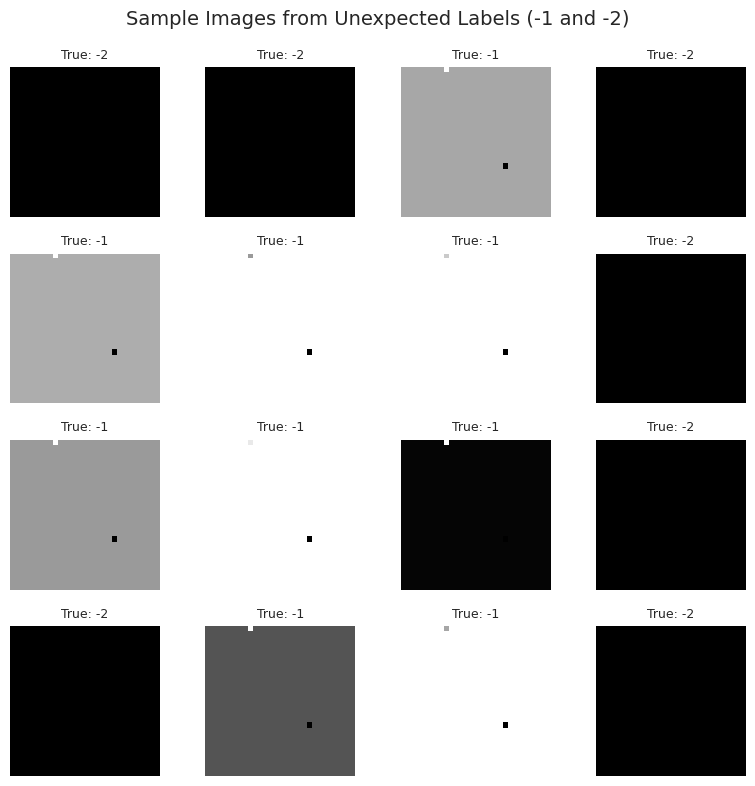

In [12]:
# Visualise samples from unexpected labels (-1 and -2)
unexpected_samples = df[df[0].isin([-1, -2])]

X_unexpected = unexpected_samples.drop(columns=[0]).values
y_unexpected = unexpected_samples[0].values

plot_image_grid(
    X_unexpected,
    labels=y_unexpected,
    n=16,
    title="Sample Images from Unexpected Labels (-1 and -2)"
)

The visual inspection of samples labelled `-1` and `-2` shows that these rows do not resemble valid handwritten characters. Most samples appear blank, nearly uniform, or corrupted, with only small isolated marks.

This supports the decision to treat `-1` and `-2` as invalid/special rows rather than valid character classes. These rows will be removed before modelling so that the final classifier focuses on the expected 26 letter classes.

### 3.6 Pixel Value Integrity Check

The pixel columns are checked to confirm that they contain valid grayscale image values.

For 28×28 grayscale images, pixel values are expected to fall between `0` and `255`. Values outside this range would indicate invalid image data and would need to be handled before preprocessing.

In [13]:
print(f"Minimum pixel value: {X_raw.min().min()}")
print(f"Maximum pixel value: {X_raw.max().max()}")

outside_range_mask = (X_raw < 0) | (X_raw > 255)
outside_range_count = outside_range_mask.sum().sum()

print(f"Pixel values outside 0–255 range: {outside_range_count}")

Minimum pixel value: 0
Maximum pixel value: 345
Pixel values outside 0–255 range: 1


In [14]:
# Check for blank or near-blank images

row_pixel_sums = X_raw.sum(axis=1)

print(f"Minimum row pixel sum: {row_pixel_sums.min()}")
print(f"Maximum row pixel sum: {row_pixel_sums.max()}")
print(f"Rows with pixel sum = 0: {(row_pixel_sums == 0).sum()}")

display(row_pixel_sums.describe().to_frame(name="pixel_sum"))

Minimum row pixel sum: 0
Maximum row pixel sum: 199920
Rows with pixel sum = 0: 17


,pixel_sum
count,99040.000000
mean,41203.097365
std,29008.351185
min,0.000000
25%,27349.000000
50%,34898.000000
75%,43578.250000
max,199920.000000


In [15]:
# Locate rows and columns with pixel values outside 0–255

invalid_pixel_positions = np.where((X_raw < 0) | (X_raw > 255))

invalid_pixel_rows = invalid_pixel_positions[0]
invalid_pixel_cols = invalid_pixel_positions[1]

print(f"Number of invalid pixel positions: {len(invalid_pixel_rows)}")

for row_idx, col_idx in zip(invalid_pixel_rows, invalid_pixel_cols):
    print(
        f"Row index: {row_idx}, "
        f"Pixel column in X_raw: {col_idx}, "
        f"Original df column: {X_raw.columns[col_idx]}, "
        f"Value: {X_raw.iloc[row_idx, col_idx]}, "
        f"Label: {y_raw.iloc[row_idx]}"
    )

Number of invalid pixel positions: 1
Row index: 48583, Pixel column in X_raw: 16, Original df column: 17, Value: 345, Label: -1


In [16]:
# Inspect rows with pixel sum = 0

blank_image_mask = row_pixel_sums == 0
blank_image_rows = df[blank_image_mask]

print(f"Number of blank images: {blank_image_rows.shape[0]}")

print("\nBlank image labels:")
display(blank_image_rows[0].value_counts().sort_index())

display(blank_image_rows.head())

Number of blank images: 17

Blank image labels:


,count
0,
-2,17


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784
4307,-2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

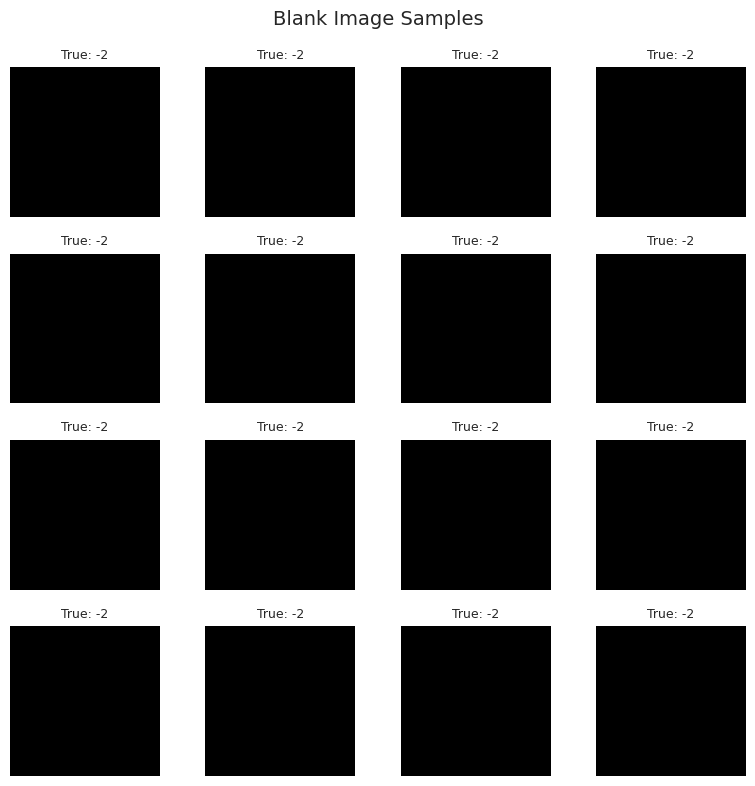

In [17]:
# Visualise blank images

X_blank = blank_image_rows.drop(columns=[0]).values
y_blank = blank_image_rows[0].values

plot_image_grid(
    X_blank,
    labels=y_blank,
    n=min(16, len(X_blank)),
    title="Blank Image Samples"
)

The pixel-value check shows that the dataset is mostly valid as grayscale image data. The minimum pixel value is `0`, and only one pixel value falls outside the expected `0–255` range.

Further inspection shows that the invalid pixel value belongs to a row labelled `-1`, which has already been identified as an invalid/special label. The 17 blank images all belong to label `-2`, which was also identified as invalid.

Therefore, the pixel integrity issues are not spread across the valid 1–26 letter classes. They are linked to the invalid labels `-1` and `-2`. Removing these invalid-label rows before modelling should also remove the out-of-range pixel value and blank-image issues.

### 3.7 Data Cleaning Decision Log

The data integrity checks identified two invalid/special labels: `-1` and `-2`.

These rows are removed before modelling because:
- they are outside the expected `1–26` letter-label range
- visual inspection shows they do not resemble valid handwritten characters
- most duplicate rows are linked to these labels
- the out-of-range pixel value and blank images are also linked to these labels

No valid letter classes are removed at this stage. The cleaned dataset should contain only labels `1` to `26`.

In [ ]:
# Keep only expected EMNIST letter labels: 1 to 26
expected_labels = range(1, 27)

df_clean = df[df[0].isin(expected_labels)].copy()

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"Percentage removed: {(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100:.2f}%")

Original dataset shape: (99040, 785)
Cleaned dataset shape: (88800, 785)
Rows removed: 10240
Percentage removed: 10.34%


In [19]:
# Validate cleaned dataset

y_clean_raw = df_clean[0]
X_clean_raw = df_clean.drop(columns=[0])

print(f"Cleaned labels shape: {y_clean_raw.shape}")
print(f"Cleaned pixel features shape: {X_clean_raw.shape}")

print("\nUnique labels after cleaning:")
print(sorted(y_clean_raw.unique()))

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

print("\nPixel range after cleaning:")
print(f"Minimum pixel value: {X_clean_raw.min().min()}")
print(f"Maximum pixel value: {X_clean_raw.max().max()}")

print("\nOut-of-range pixel values after cleaning:")
print(((X_clean_raw < 0) | (X_clean_raw > 255)).sum().sum())

print("\nBlank images after cleaning:")
print((X_clean_raw.sum(axis=1) == 0).sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Cleaned labels shape: (88800,)
Cleaned pixel features shape: (88800, 784)

Unique labels after cleaning:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]

Missing values after cleaning:
0

Pixel range after cleaning:
Minimum pixel value: 0
Maximum pixel value: 255

Out-of-range pixel values after cleaning:
0

Blank images after cleaning:
0

Duplicate rows after cleaning:
2


Rows labelled `-1` and `-2` were removed from the dataset. This removed 10,240 rows, or 10.34% of the original dataset.

After cleaning, the dataset contains 88,800 rows and 785 columns. The labels now range cleanly from `1` to `26`, with no missing expected classes. The pixel features still contain 784 columns, matching the expected 28×28 image format.

The cleaned dataset has no missing values, no out-of-range pixel values, and no blank images. The pixel range is now valid at `0–255`. Only 2 duplicate rows remain after cleaning, which is negligible compared with the dataset size and no longer appears to be a major data quality issue.

Therefore, `df_clean`, `X_clean_raw`, and `y_clean_raw` will be used for the remaining EDA, preprocessing, and modelling steps.

**Current status:**
- Original rows: 99,040
- Removed invalid/special rows: 10,240
- Cleaned rows: 88,800
- Final classes: 26
- Pixel columns: 784
- Pixel range: 0–255
- Blank images: 0
- Out-of-range pixels: 0
- Remaining duplicates: 2

---

## 4. Exploratory Data Analysis

This section analyses the cleaned dataset to understand class distribution, image structure, pixel properties, and spatial patterns. Each finding informs a later preprocessing or modelling decision.

### 4.1 Class Distribution

Before modelling, the cleaned labels are checked for class balance, because strong class imbalance can make accuracy misleading and may require stratified splitting or stronger class-level evaluation. At this stage, only the cleaned dataset is inspected; no model performance or validation/test information is used.

,label,letter,count,percentage
0,1,A,3396,3.82
1,2,B,3396,3.82
2,3,C,3419,3.85
3,4,D,3398,3.83
4,5,E,3437,3.87
5,6,F,3394,3.82
6,7,G,3385,3.81
7,8,H,3424,3.86
8,9,I,3428,3.86
9,10,J,3402,3.83


Number of classes: 26
Total cleaned samples: 88800
Smallest class count: 3365
Largest class count: 3453
Largest-to-smallest class ratio: 1.026


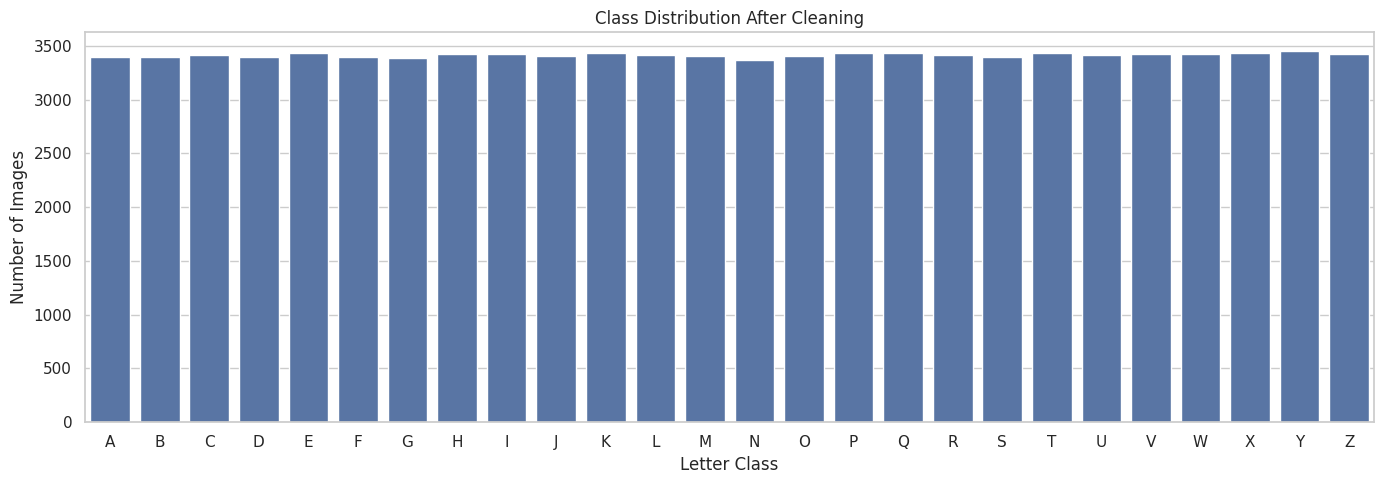

In [20]:
label_counts = pd.Series(y_clean_raw, name="label").value_counts().sort_index()

class_distribution = pd.DataFrame({
    "label": label_counts.index,
    "letter": [chr(label + 64) for label in label_counts.index],
    "count": label_counts.values
})

class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
).round(2)

display(class_distribution)

print("Number of classes:", class_distribution["label"].nunique())
print("Total cleaned samples:", class_distribution["count"].sum())
print("Smallest class count:", class_distribution["count"].min())
print("Largest class count:", class_distribution["count"].max())
print(
    "Largest-to-smallest class ratio:",
    round(class_distribution["count"].max() / class_distribution["count"].min(), 3)
)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=class_distribution,
    x="letter",
    y="count"
)
plt.title("Class Distribution After Cleaning")
plt.xlabel("Letter Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

The cleaned dataset is very balanced across the 26 letter classes. Each class contains around 3,365 to 3,453 images, giving a largest-to-smallest class ratio of only 1.026. This means there is no meaningful class imbalance after cleaning, so accuracy will be a reasonable headline metric. However, class-level precision, recall, F1-score, and confusion-matrix analysis are still needed later because some letters may be harder to distinguish visually even when class counts are balanced. Stratified splitting will be used to preserve this balanced distribution across the training, validation, and test sets.

### 4.2 Random Image Samples

Random cleaned images are displayed to check whether the data looks like meaningful handwritten letters after removing the invalid `-1` and `-2` labels. This also helps confirm whether the current 28×28 reshaping gives a sensible visual orientation before any preprocessing or modelling.

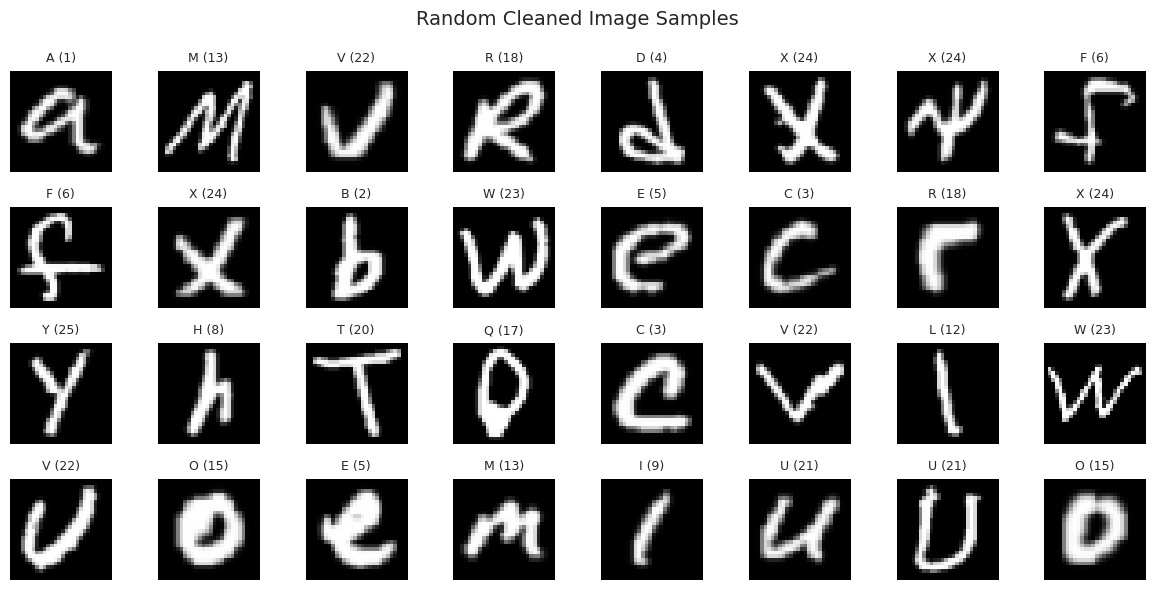

In [21]:
rng = np.random.default_rng(SEED)
sample_positions = rng.choice(len(X_clean_raw), size=32, replace=False)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.ravel()

for ax, pos in zip(axes, sample_positions):
    image = X_clean_raw.iloc[pos].to_numpy().reshape(28, 28).T
    label = int(y_clean_raw.iloc[pos])
    letter = chr(label + 64)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"{letter} ({label})", fontsize=9)
    ax.axis("off")

plt.suptitle("Random Cleaned Image Samples", fontsize=14)
plt.tight_layout()
plt.show()

The random samples show that the cleaned dataset contains meaningful handwritten letter images after removing the invalid `-1` and `-2` labels. The images show natural variation in handwriting style and stroke thickness which supports the need for a model that can learn spatial stroke patterns rather than relying only on flattened pixel values. Some letters are also visually ambiguous, so later evaluation should include confusion-matrix and misclassified-image analysis instead of relying only on overall accuracy.

### 4.3 Per-Class Image Samples

Examples from each letter class are displayed to inspect handwriting variation within the same label. This helps identify whether the classification problem is visually straightforward or whether some classes contain large differences in style, slant, thickness, and shape.

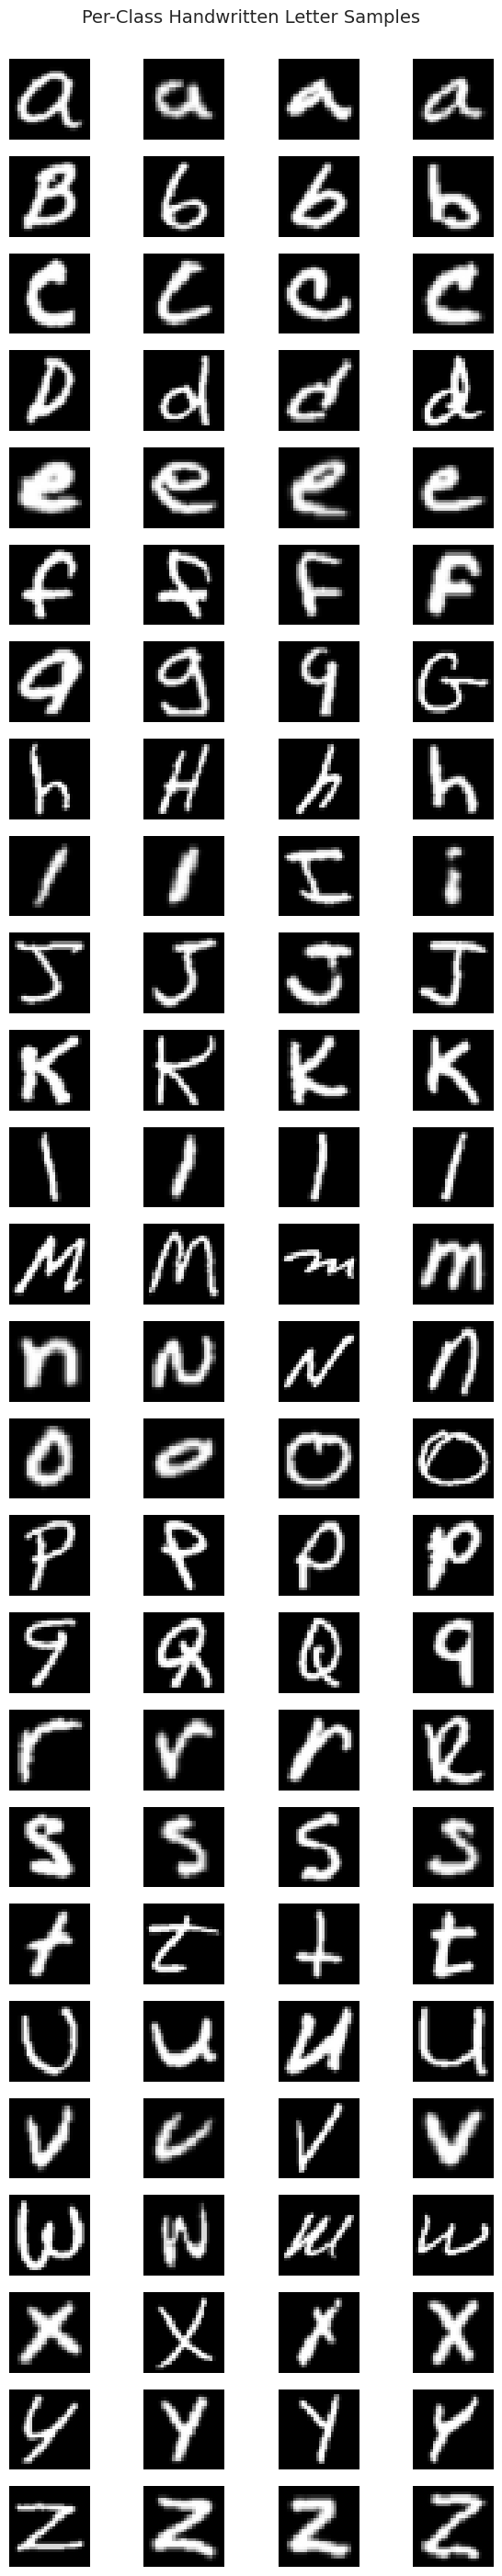

In [22]:
samples_per_class = 4
labels = np.sort(pd.Series(y_clean_raw).unique())

X_clean_np = X_clean_raw.to_numpy()
y_clean_np = y_clean_raw.to_numpy()

rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(
    len(labels),
    samples_per_class,
    figsize=(samples_per_class * 1.6, len(labels) * 1.1)
)

for row, label in enumerate(labels):
    class_positions = np.where(y_clean_np == label)[0]
    selected_positions = rng.choice(class_positions, size=samples_per_class, replace=False)
    letter = chr(int(label) + 64)

    for col, pos in enumerate(selected_positions):
        image = X_clean_np[pos].reshape(28, 28).T

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(f"{letter} ({label})", rotation=0, labelpad=25, fontsize=9)

plt.suptitle("Per-Class Handwritten Letter Samples", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

The per-class samples show clear handwriting variation within almost every letter class. Differences appear in stroke thickness, slant, curvature, spacing, and writing style, especially for letters such as `D`, `G`, `Q`, `R`, and `W`. Some classes are visually close to other letters or symbols, such as `I`/`L`, `O`/`Q`, `U`/`V`, and `M`/`N`, which may become common confusion pairs later. This supports using CNNs because the model needs to learn local stroke and shape patterns, not just overall pixel brightness.

### 4.4 Pixel Intensity Distribution

The pixel intensity distribution is inspected to understand the raw input scale before modelling. Since neural networks are sensitive to input scale, this step checks whether the images should be normalised before being passed into dense or CNN models.

Pixel intensity summary after cleaning:
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 43.92
Median pixel value: 0.0
Standard deviation: 84.4

Pixel sparsity:
Zero-valued pixels (%): 67.04
Non-zero pixels (%): 32.96


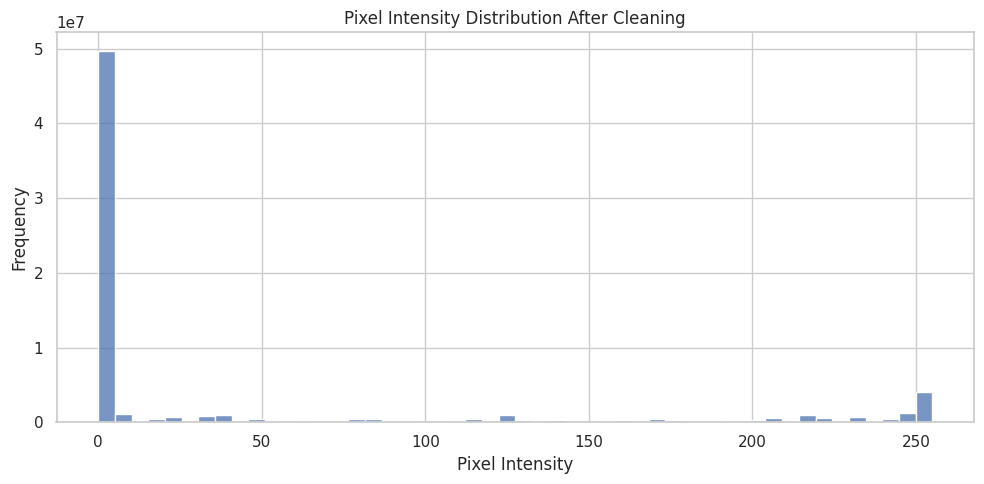

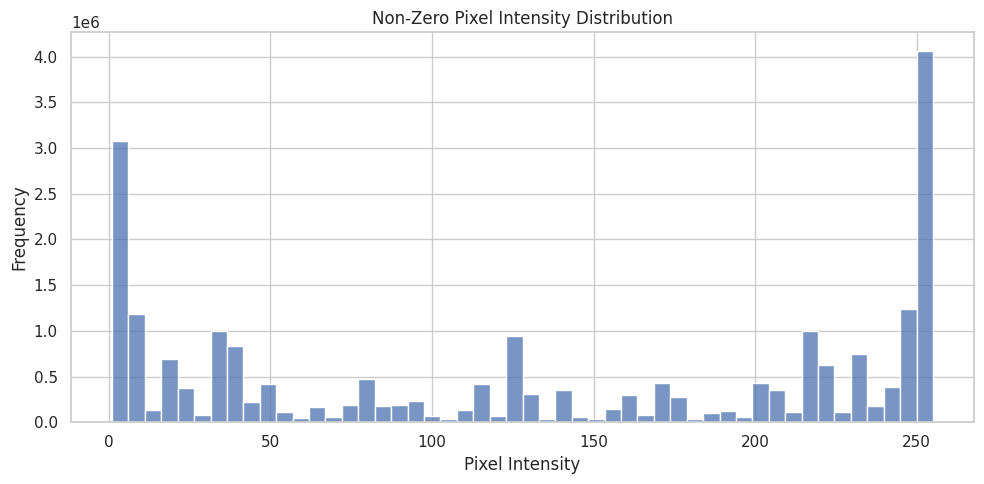

In [23]:
pixel_values = X_clean_raw.to_numpy().ravel()

print("Pixel intensity summary after cleaning:")
print("Minimum pixel value:", pixel_values.min())
print("Maximum pixel value:", pixel_values.max())
print("Mean pixel value:", round(pixel_values.mean(), 2))
print("Median pixel value:", round(np.median(pixel_values), 2))
print("Standard deviation:", round(pixel_values.std(), 2))

zero_percentage = (pixel_values == 0).mean() * 100
non_zero_percentage = (pixel_values > 0).mean() * 100

print("\nPixel sparsity:")
print("Zero-valued pixels (%):", round(zero_percentage, 2))
print("Non-zero pixels (%):", round(non_zero_percentage, 2))

plt.figure(figsize=(10, 5))
sns.histplot(pixel_values, bins=50)
plt.title("Pixel Intensity Distribution After Cleaning")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(pixel_values[pixel_values > 0], bins=50)
plt.title("Non-Zero Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The cleaned images use the expected grayscale pixel range of 0 to 255. The distribution is highly sparse: 67.04% of pixels are zero, meaning most of each 28×28 image is black background while the non-zero pixels represent the handwritten strokes. The median pixel value is 0, while the mean is 43.92, confirming that background pixels dominate the raw input. Since neural networks train more reliably when inputs are on a smaller and consistent scale, the pixel values should be normalised from `0–255` to `0–1` during preprocessing.

The pixel intensity distribution confirms that the images are sparse grayscale images with a mostly black background and brighter stroke pixels. This supports simple fixed-range normalisation by dividing pixel values by 255.

The large proportion of zero-valued pixels is also relevant for augmentation later. If spatial augmentation creates new border/background pixels, using a black fill value of `0.0` after normalisation is consistent with the original image background. However, this only informs how augmentation should be configured; it does not prove that augmentation will improve the model. That will be tested later using validation results.

### 4.5 Average Image Per Class

Average images are visualised for each class to identify common stroke patterns across many handwriting samples. This helps show whether each class has a recognisable central shape and highlights possible overlaps between visually similar letters.

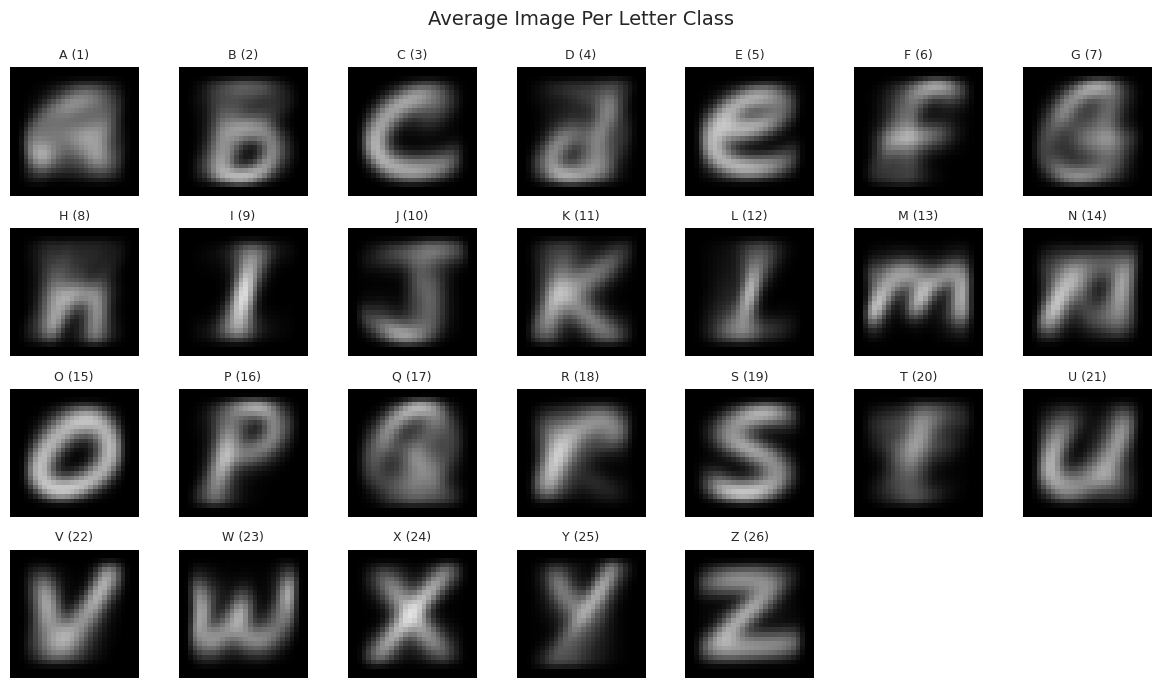

In [24]:
X_clean_np = X_clean_raw.to_numpy()
y_clean_np = y_clean_raw.to_numpy()

labels = np.sort(np.unique(y_clean_np))

fig, axes = plt.subplots(4, 7, figsize=(12, 7))
axes = axes.ravel()

for i, label in enumerate(labels):
    class_images = X_clean_np[y_clean_np == label]
    average_image = class_images.mean(axis=0).reshape(28, 28).T
    letter = chr(int(label) + 64)

    axes[i].imshow(average_image, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(f"{letter} ({label})", fontsize=9)
    axes[i].axis("off")

for j in range(len(labels), len(axes)):
    axes[j].axis("off")

plt.suptitle("Average Image Per Letter Class", fontsize=14)
plt.tight_layout()
plt.show()

The average images show that most classes have a recognisable central letter shape, which suggests that the dataset contains consistent class-level stroke patterns despite individual handwriting variation. However, the averages are blurred because samples differ in slant, thickness, curvature, and exact position. Some classes also have visibly similar average structures, such as `O`/`Q`, `I`/`L`, `U`/`V`, and `M`/`N`, which supports the earlier expectation that visually similar letters may become common confusion pairs. This reinforces the need for CNN-based modelling and later class-level error analysis.

#### 4.5.1 Overall Average Pixel Heatmap

An overall average pixel heatmap is plotted across all cleaned images to show where handwritten strokes tend to occur on the 28×28 grid. Unlike the class-specific average images above, this visual summarises the common spatial concentration of foreground pixels across the entire dataset. This helps assess whether the letters are generally centred and whether most useful signal lies in a compact region of the image.

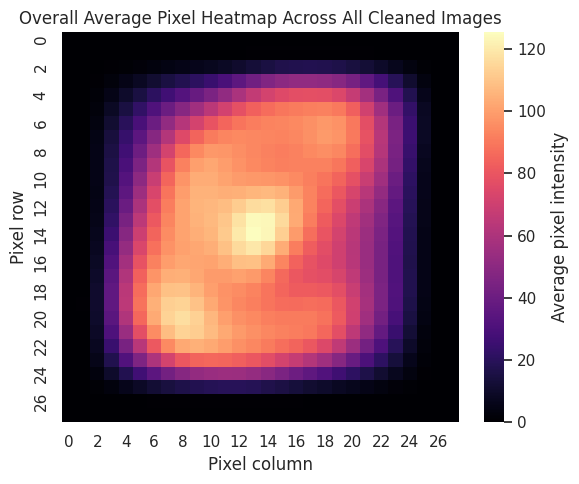

In [25]:
overall_average_image = X_clean_raw.to_numpy().mean(axis=0).reshape(28, 28).T

plt.figure(figsize=(6, 5))
sns.heatmap(
    overall_average_image,
    cmap="magma",
    cbar_kws={"label": "Average pixel intensity"}
)
plt.title("Overall Average Pixel Heatmap Across All Cleaned Images")
plt.xlabel("Pixel column")
plt.ylabel("Pixel row")
plt.tight_layout()
plt.show()

The overall heatmap shows that the strongest average stroke signal is concentrated near the centre of the image, while the borders remain mostly dark. This suggests that the cleaned letters are generally centred and that small spatial transformations may be realistic because there is some border space around the strokes.

However, the heatmap also shows why augmentation must be controlled. Small translations or zooms may improve robustness to handwriting position and scale, but stronger transformations may crop or distort important strokes. Therefore, augmentation should not be selected only by intuition; Section 6 defines candidate augmentation policies and Section 9 evaluates which policy improves validation performance.

### 4.6 Early Hypotheses from EDA

The EDA suggests three structural hypotheses that guide the modelling approach.

First, a CNN should outperform a dense neural network because the images contain local stroke patterns, curves, and edges arranged spatially across the 28×28 grid. Flattening the image into a 784-value vector removes this structure, while convolutional layers can learn local visual features while preserving spatial relationships.

Second, overall accuracy is necessary but not sufficient as an evaluation metric. Even with balanced classes, visually similar letters may be systematically confused. Later evaluation must therefore include a confusion matrix, top confusion pairs, and misclassified image examples to identify class-level weaknesses.

Third, conservative augmentation may improve generalisation because handwriting varies naturally in position, angle, and size. However, stronger augmentation may hurt performance if it distorts letter identity or crops important strokes. This will be tested through candidate augmentation policies rather than assumed.

Based on the visual EDA, the model is expected to struggle most with visually similar letter pairs such as `I/L`, `G/Q`, `O/Q`, `U/V`, `M/N`, `D/O`, and `E/C`. These pairs have similar stroke shapes or differ by small local details, so later evaluation will explicitly check whether these expected confusions appear in the validation and test results.

### 4.7 EDA Summary → Preprocessing and Modelling Plan

The EDA findings directly determine the preprocessing pipeline and modelling decisions that follow.

**Class balance (Section 4.1):** The cleaned dataset is highly balanced across all 26 classes, with a largest-to-smallest ratio of only **1.026**. Accuracy is therefore a valid headline metric. Stratified splitting will be used in Section 5 to preserve this balance across training, validation, and test sets.

**Pixel scale (Section 4.4):** Raw pixel values span 0–255 with a mean of **43.92** and **67.04%** zero-valued pixels. Neural networks train more reliably on small, consistent input scales, so pixel values will be normalised from 0–255 to 0–1 in Section 5.5. No per-channel statistics are needed because the images are single-channel grayscale with a fixed value range.

**Image structure (Sections 4.3, 4.5):** Per-class samples and average images confirm that letter identity depends on how local strokes, curves, and intersections are arranged spatially across the 28×28 grid, not on global pixel brightness alone. This motivates using CNNs rather than dense networks: convolutional filters preserve and learn from this spatial structure, while flattening the image first discards it.

**Centred strokes with empty borders (Section 4.5.1):** The overall average heatmap shows that handwritten strokes concentrate in the central region, leaving mostly dark outer borders. This supports conservative augmentation in Section 6: small shifts and zooms are reasonable because empty border space exists, but aggressive transformations risk pushing strokes to the edges and cropping important letter features.

**Visually similar classes (Sections 4.3, 4.5):** Average images and per-class samples suggest likely confusion between I/L, O/Q, G/Q, U/V, and M/N. These pairs will be tracked explicitly in the confusion matrix, top confusion-pair analysis, and misclassified image review during model evaluation.

**Summary of preprocessing decisions flowing from EDA:**

| Decision | Reason from EDA |
|---|---|
| Normalise pixels to 0–1 | Raw 0–255 scale; mean 43.92, heavily zero-inflated |
| Reshape to (28, 28, 1) | CNN input requires 2D spatial structure preserved |
| Stratified train/val/test split | Balanced classes; preserve distribution across splits |
| Conservative augmentation only | Centred strokes with border space; identity-sensitive letters |
| Class-level evaluation metrics | Visually similar pairs expected to dominate errors |

---

## 5. Preprocessing Pipeline

This section applies the preprocessing decisions informed by EDA: splitting the data, reshaping images, normalising pixels, and encoding labels for CNN training.

### 5.1 Confirm Modelling Dataset

The cleaned dataset from Section 3 is now treated as the modelling dataset. This step does not introduce a new cleaning rule; it confirms that only valid labels `1` to `26` remain, the feature matrix still contains 784 pixel columns, and all pixel values are within the valid grayscale range of `0` to `255`. From this point onward, `X_part_a_raw` and `y_part_a_raw` are used as the official inputs for preprocessing, splitting, and modelling.

In [26]:
# 5.1 Confirm Modelling Dataset

X_part_a_raw = X_clean_raw.copy()
y_part_a_raw = y_clean_raw.astype(int).copy()

valid_labels = np.arange(1, 27)

print("Modelling feature matrix shape:", X_part_a_raw.shape)
print("Modelling target vector shape:", y_part_a_raw.shape)

print("\nUnique labels in modelling dataset:")
print(sorted(y_part_a_raw.unique()))

print("\nPixel value range:")
print("Minimum:", X_part_a_raw.min().min())
print("Maximum:", X_part_a_raw.max().max())

assert set(y_part_a_raw.unique()) == set(valid_labels)
assert X_part_a_raw.shape[1] == 784
assert X_part_a_raw.min().min() >= 0
assert X_part_a_raw.max().max() <= 255

Modelling feature matrix shape: (88800, 784)
Modelling target vector shape: (88800,)

Unique labels in modelling dataset:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]

Pixel value range:
Minimum: 0
Maximum: 255


The assertions passed. The modelling dataset enters the preprocessing pipeline with only valid labels from 1 to 26, 784 pixel columns per image, and no out-of-range pixel values. No further cleaning is needed before splitting and normalisation.

### 5.2 Prepare Feature Matrix and Target Vector

The cleaned pandas objects are converted into NumPy arrays for modelling. At this point, the images remain as flattened 784-pixel vectors and the labels remain in their original `1` to `26` format for readability. Reshaping, normalisation, and label encoding are handled separately in later preprocessing steps.

In [27]:
X = X_part_a_raw.to_numpy(dtype=np.float32)
y = y_part_a_raw.to_numpy(dtype=np.int32)

class_labels = np.arange(1, 27)
class_names = [chr(label + 64) for label in class_labels]

label_to_letter = {
    label: letter
    for label, letter in zip(class_labels, class_names)
}

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Feature matrix dtype:", X.dtype)
print("Target vector dtype:", y.dtype)

print("\nLabel range:")
print("Minimum label:", y.min())
print("Maximum label:", y.max())

print("\nNumber of classes:", len(class_names))
print("Class names:", class_names)

assert X.shape == (88800, 784)
assert y.shape == (88800,)
assert y.min() == 1
assert y.max() == 26

Feature matrix shape: (88800, 784)
Target vector shape: (88800,)
Feature matrix dtype: float32
Target vector dtype: int32

Label range:
Minimum label: 1
Maximum label: 26

Number of classes: 26
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


### 5.3 Train / Validation / Test Split

The dataset is split into training, validation, and test sets using stratified sampling. The training set is used to fit model weights, the validation set is used for model selection and tuning, and the test set is kept separate for final evaluation only. A `70% / 15% / 15%` split is used because the cleaned dataset is large enough to provide substantial validation and test sets while keeping most samples for training.

The validation set will be used for model comparison and model-selection decisions, including architecture changes, regularisation choices, augmentation policy, batch size, epoch limit, and learning-rate strategy. The test set will remain untouched until the final model is locked in Section 10, so that the final test result remains an unbiased estimate of generalisation.

In [28]:
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw,
    y_temp_raw,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_raw
)

print("Training set:")
print("X_train_raw:", X_train_raw.shape)
print("y_train_raw:", y_train_raw.shape)

print("\nValidation set:")
print("X_val_raw:", X_val_raw.shape)
print("y_val_raw:", y_val_raw.shape)

print("\nTest set:")
print("X_test_raw:", X_test_raw.shape)
print("y_test_raw:", y_test_raw.shape)

print("\nSplit proportions:")
print("Training:", round(len(X_train_raw) / len(X) * 100, 2), "%")
print("Validation:", round(len(X_val_raw) / len(X) * 100, 2), "%")
print("Test:", round(len(X_test_raw) / len(X) * 100, 2), "%")

split_distribution = pd.DataFrame({
    "label": class_labels,
    "letter": class_names,
    "train_count": pd.Series(y_train_raw).value_counts().sort_index().values,
    "val_count": pd.Series(y_val_raw).value_counts().sort_index().values,
    "test_count": pd.Series(y_test_raw).value_counts().sort_index().values
})

display(split_distribution)

assert len(X_train_raw) + len(X_val_raw) + len(X_test_raw) == len(X)
assert X_train_raw.shape[1] == 784
assert X_val_raw.shape[1] == 784
assert X_test_raw.shape[1] == 784
assert set(y_train_raw) == set(class_labels)
assert set(y_val_raw) == set(class_labels)
assert set(y_test_raw) == set(class_labels)

Training set:
X_train_raw: (62160, 784)
y_train_raw: (62160,)

Validation set:
X_val_raw: (13320, 784)
y_val_raw: (13320,)

Test set:
X_test_raw: (13320, 784)
y_test_raw: (13320,)

Split proportions:
Training: 70.0 %
Validation: 15.0 %
Test: 15.0 %


,label,letter,train_count,val_count,test_count
0,1,A,2377,510,509
1,2,B,2377,510,509
2,3,C,2393,513,513
3,4,D,2379,510,509
4,5,E,2406,515,516
5,6,F,2376,509,509
6,7,G,2369,508,508
7,8,H,2397,513,514
8,9,I,2400,514,514
9,10,J,2381,511,510


The cleaned dataset was split into 62,160 training samples, 13,320 validation samples, and 13,320 test samples, matching the intended `70% / 15% / 15%` split. Stratification preserved the class distribution well across all three sets, with each letter class represented in the training, validation, and test data. This gives a fair setup for model training, validation-based model selection, and final unbiased test evaluation.

### 5.4 Reshape Images for CNN Input

The flattened 784-pixel vectors are reshaped into 28×28 grayscale images with one channel. This produces the input format expected by Keras `Conv2D` layers: `(samples, height, width, channels)`.

CNN image shapes before normalisation:
X_train_images_raw: (62160, 28, 28, 1)
X_val_images_raw: (13320, 28, 28, 1)
X_test_images_raw: (13320, 28, 28, 1)

Pixel value range before normalisation:
Training min/max: 0.0 255.0
Validation min/max: 0.0 255.0
Test min/max: 0.0 255.0


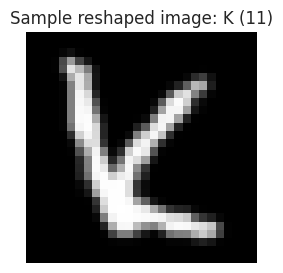

In [29]:
X_train_images_raw = X_train_raw.reshape(-1, 28, 28).transpose(0, 2, 1)[..., np.newaxis]
X_val_images_raw = X_val_raw.reshape(-1, 28, 28).transpose(0, 2, 1)[..., np.newaxis]
X_test_images_raw = X_test_raw.reshape(-1, 28, 28).transpose(0, 2, 1)[..., np.newaxis]

print("CNN image shapes before normalisation:")
print("X_train_images_raw:", X_train_images_raw.shape)
print("X_val_images_raw:", X_val_images_raw.shape)
print("X_test_images_raw:", X_test_images_raw.shape)

print("\nPixel value range before normalisation:")
print("Training min/max:", X_train_images_raw.min(), X_train_images_raw.max())
print("Validation min/max:", X_val_images_raw.min(), X_val_images_raw.max())
print("Test min/max:", X_test_images_raw.min(), X_test_images_raw.max())

sample_index = 0
sample_label = int(y_train_raw[sample_index])
sample_letter = chr(sample_label + 64)

plt.figure(figsize=(3, 3))
plt.imshow(X_train_images_raw[sample_index].squeeze(), cmap="gray")
plt.title(f"Sample reshaped image: {sample_letter} ({sample_label})")
plt.axis("off")
plt.show()

assert X_train_images_raw.shape == (62160, 28, 28, 1)
assert X_val_images_raw.shape == (13320, 28, 28, 1)
assert X_test_images_raw.shape == (13320, 28, 28, 1)

### 5.5 Normalise Pixel Values

The image pixel values are scaled from the raw grayscale range `0–255` to `0–1`. This keeps the input scale small and consistent, which helps neural networks train more reliably. The same fixed scaling rule is applied to the training, validation, and test sets without using any statistics learned from the validation or test data.

In [30]:
X_train_images = X_train_images_raw / 255.0
X_val_images = X_val_images_raw / 255.0
X_test_images = X_test_images_raw / 255.0

print("CNN image shapes after normalisation:")
print("X_train_images:", X_train_images.shape)
print("X_val_images:", X_val_images.shape)
print("X_test_images:", X_test_images.shape)

print("\nPixel value range after normalisation:")
print("Training min/max:", X_train_images.min(), X_train_images.max())
print("Validation min/max:", X_val_images.min(), X_val_images.max())
print("Test min/max:", X_test_images.min(), X_test_images.max())

print("\nData types after normalisation:")
print("X_train_images dtype:", X_train_images.dtype)
print("X_val_images dtype:", X_val_images.dtype)
print("X_test_images dtype:", X_test_images.dtype)

assert X_train_images.min() >= 0 and X_train_images.max() <= 1
assert X_val_images.min() >= 0 and X_val_images.max() <= 1
assert X_test_images.min() >= 0 and X_test_images.max() <= 1

CNN image shapes after normalisation:
X_train_images: (62160, 28, 28, 1)
X_val_images: (13320, 28, 28, 1)
X_test_images: (13320, 28, 28, 1)

Pixel value range after normalisation:
Training min/max: 0.0 1.0
Validation min/max: 0.0 1.0
Test min/max: 0.0 1.0

Data types after normalisation:
X_train_images dtype: float32
X_val_images dtype: float32
X_test_images dtype: float32


Pixel values now fall within 0–1 across all three splits. The fixed divide-by-255 rule introduces no data leakage because it does not estimate any statistics from the validation or test sets. Every split is scaled by the same constant derived from the known grayscale range. The `float32` dtype is confirmed, which is required for TensorFlow training.

This is fixed-range pixel rescaling, not z-score standardisation. It is leakage-safe because it uses the known image range `0–255` rather than fitted dataset statistics.

This `0–1` pixel scale is also compatible with the Keras augmentation layers used later, where newly created background pixels can be filled with `0.0` to match the black image background.

### 5.6 Encode Labels

The original labels use values `1` to `26`, where `1 = A` and `26 = Z`. For Keras multi-class classification with `sparse_categorical_crossentropy`, the labels are converted to zero-based integer labels from `0` to `25`. This avoids one-hot encoding and keeps the target arrays compact while still representing the same 26 classes.

In [31]:
y_train = y_train_raw - 1
y_val = y_val_raw - 1
y_test = y_test_raw - 1

num_classes = 26

zero_based_class_labels = np.arange(num_classes)
class_names = [chr(label + 65) for label in zero_based_class_labels]

print("Encoded label ranges:")
print("Training labels:", y_train.min(), "to", y_train.max())
print("Validation labels:", y_val.min(), "to", y_val.max())
print("Test labels:", y_test.min(), "to", y_test.max())

print("\nNumber of classes:", num_classes)
print("Class names:", class_names)

print("\nExample label mapping:")
for original_label, encoded_label, letter in zip(range(1, 27), range(26), class_names):
    print(f"Original {original_label:2d} -> Encoded {encoded_label:2d} -> {letter}")

assert y_train.min() == 0 and y_train.max() == 25
assert y_val.min() == 0 and y_val.max() == 25
assert y_test.min() == 0 and y_test.max() == 25
assert len(class_names) == num_classes

Encoded label ranges:
Training labels: 0 to 25
Validation labels: 0 to 25
Test labels: 0 to 25

Number of classes: 26
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Example label mapping:
Original  1 -> Encoded  0 -> A
Original  2 -> Encoded  1 -> B
Original  3 -> Encoded  2 -> C
Original  4 -> Encoded  3 -> D
Original  5 -> Encoded  4 -> E
Original  6 -> Encoded  5 -> F
Original  7 -> Encoded  6 -> G
Original  8 -> Encoded  7 -> H
Original  9 -> Encoded  8 -> I
Original 10 -> Encoded  9 -> J
Original 11 -> Encoded 10 -> K
Original 12 -> Encoded 11 -> L
Original 13 -> Encoded 12 -> M
Original 14 -> Encoded 13 -> N
Original 15 -> Encoded 14 -> O
Original 16 -> Encoded 15 -> P
Original 17 -> Encoded 16 -> Q
Original 18 -> Encoded 17 -> R
Original 19 -> Encoded 18 -> S
Original 20 -> Encoded 19 -> T
Original 21 -> Encoded 20 -> U
Original 22 -> Encoded 21 -> V
Original 23 -> Encoded 22 -> W
O

Labels are now stored as zero-based integer indices from 0 to 25, where 0 = A and 25 = Z.

`sparse_categorical_crossentropy` is used as the training loss because it accepts integer class indices directly, without requiring one-hot encoding. The alternative, `categorical_crossentropy`, expects each label to be a vector of length 26. For 88,800 samples, this would mean storing an 88,800 × 26 array of mostly zeros, adding memory overhead with no mathematical benefit. Both losses compute the same cross-entropy value internally; the sparse version simply skips the unnecessary one-hot conversion. This is why the label encoding step subtracts 1 from the original 1–26 labels: `sparse_categorical_crossentropy` requires zero-based integer indices starting from 0.

### 5.7 Final Preprocessing Checks

Final checks are performed before modelling to confirm that the processed inputs have the expected shapes, value ranges, data types, and label encoding. A processed image is also displayed to verify that the final model input still represents a valid handwritten letter.

,split,X_shape,y_shape,X_dtype,y_dtype,X_min,X_max,y_min,y_max
0,Train,"(62160, 28, 28, 1)","(62160,)",float32,int32,0.0,1.0,0,25
1,Validation,"(13320, 28, 28, 1)","(13320,)",float32,int32,0.0,1.0,0,25
2,Test,"(13320, 28, 28, 1)","(13320,)",float32,int32,0.0,1.0,0,25


Number of classes: 26
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


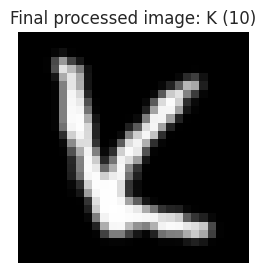

In [32]:
preprocessing_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "X_shape": [X_train_images.shape, X_val_images.shape, X_test_images.shape],
    "y_shape": [y_train.shape, y_val.shape, y_test.shape],
    "X_dtype": [X_train_images.dtype, X_val_images.dtype, X_test_images.dtype],
    "y_dtype": [y_train.dtype, y_val.dtype, y_test.dtype],
    "X_min": [X_train_images.min(), X_val_images.min(), X_test_images.min()],
    "X_max": [X_train_images.max(), X_val_images.max(), X_test_images.max()],
    "y_min": [y_train.min(), y_val.min(), y_test.min()],
    "y_max": [y_train.max(), y_val.max(), y_test.max()]
})

display(preprocessing_summary)

print("Number of classes:", num_classes)
print("Class names:", class_names)

sample_index = 0
sample_encoded_label = int(y_train[sample_index])
sample_letter = class_names[sample_encoded_label]

plt.figure(figsize=(3, 3))
plt.imshow(X_train_images[sample_index].squeeze(), cmap="gray")
plt.title(f"Final processed image: {sample_letter} ({sample_encoded_label})")
plt.axis("off")
plt.show()

assert X_train_images.shape[1:] == (28, 28, 1)
assert X_val_images.shape[1:] == (28, 28, 1)
assert X_test_images.shape[1:] == (28, 28, 1)

assert X_train_images.min() >= 0 and X_train_images.max() <= 1
assert X_val_images.min() >= 0 and X_val_images.max() <= 1
assert X_test_images.min() >= 0 and X_test_images.max() <= 1

assert y_train.min() == 0 and y_train.max() == 25
assert y_val.min() == 0 and y_val.max() == 25
assert y_test.min() == 0 and y_test.max() == 25

The final preprocessing checks confirm that all three splits are ready for modelling. The training, validation, and test inputs have the expected CNN shape `(28, 28, 1)`, use `float32`, and are normalised to the `0–1` range. The labels are stored as integer class indices from `0` to `25`, matching the planned use of `sparse_categorical_crossentropy`. The displayed processed sample remains a readable handwritten letter, confirming that the final model input has not been distorted during reshaping or normalisation.

---

## 6. Feature Engineering and Augmentation Strategy

The earlier sections prepared a cleaned, normalised image dataset for CNN modelling.

The key decision in this section is not to select the final augmentation policy yet. Instead, augmentation candidates are defined and visually checked first. Their actual usefulness will be tested later in Section 9 using validation loss, validation accuracy, macro F1, and learning-curve behaviour.

### 6.1 Feature Engineering for Image Data

For tabular datasets, feature engineering often means manually creating new columns from existing variables. For image data, the situation is different because the pixel grid already contains spatial information such as strokes, edges, curves, thickness, and position.

A CNN is suitable here because convolutional layers can learn local visual patterns directly from the 28×28 grayscale images. Therefore, the main feature engineering decision is to preserve the useful image structure rather than flattening or manually transforming the images too aggressively.

In this notebook, the main engineered representation is the preprocessing pipeline already completed in Section 5: reshaping each image into `(28, 28, 1)`, correcting the orientation, normalising pixel values to `0–1`, and encoding the labels for multi-class classification. This keeps the raw handwriting information intact while making the data suitable for CNN training.

### 6.2 Handcrafted Feature Options Considered

Several handcrafted image-processing options were considered before deciding how to represent the images for CNN modelling.

One option was edge detection, where the image could be transformed to highlight stroke boundaries. This may make some letter outlines clearer, but it could also remove useful grayscale information such as stroke thickness and writing pressure.

Another option was thresholding, where grayscale pixels are converted into binary black-and-white pixels. This would simplify the image, but it may discard intensity differences that help distinguish handwriting styles.

Morphological operations such as dilation or erosion were also possible. These could thicken or thin strokes, but they risk changing the shape of letters in a way that is not guaranteed to preserve class identity.

Extra handcrafted features, such as stroke density, number of active pixels, or centre-of-mass position, could also be created. However, these features would reduce the image into summary statistics and may lose important local patterns that CNNs are designed to learn directly.

### 6.3 Why Handcrafted Features Were Not Used

Handcrafted image features were not used as the main modelling input because they could remove useful information from the original handwritten letters. The cleaned dataset already contains valid grayscale pixel values, and the earlier EDA showed that stroke thickness, positioning, and handwriting style vary across samples. These variations may be useful signals for the model.

Using handcrafted transformations such as thresholding, edge detection, or morphology would also introduce extra assumptions about what information matters. For example, thresholding may simplify the image but discard intensity variation, while erosion or dilation may alter thin strokes and make similar letters more ambiguous.

A CNN is better suited for this task because it can learn local stroke, edge, and curve patterns directly from the normalised image pixels. Therefore, the notebook focuses on preserving the original image structure and improving the CNN through controlled modelling experiments rather than manually engineering image features without validation evidence.

The main feature-engineering choice retained is data augmentation, because it can create realistic variations of the existing training images while keeping the original pixel representation intact. However, augmentation still carries risks, so different augmentation strengths will be defined and tested rather than assumed to be beneficial.

### 6.4 Augmentation Rationale from EDA

The EDA suggests that augmentation is worth testing, but only within controlled limits.

The random and per-class image samples showed natural handwriting variation in stroke thickness, slant, shape, and positioning. This means the model should ideally learn letter identity rather than memorising one narrow writing style. Small rotations, translations, and zooms may help expose the CNN to realistic variations of the same letter.

The overall average heatmap showed that most stroke signal is concentrated near the centre of the image, while the borders are mostly dark. This supports testing small spatial transformations because there is some border space around the letters. At the same time, it also warns against overly strong transformations, because excessive shifts or zooms could crop important strokes.

The pixel intensity distribution also supports a controlled augmentation setup. Since the images have a mostly black background and were normalised to `0–1`, any newly created background pixels during augmentation should use `fill_value=0.0`.

Therefore, augmentation is treated as an experiment rather than a fixed assumption. Section 6 defines candidate augmentation policies, and Section 9 will compare them using validation loss, validation accuracy, macro F1, and learning-curve behaviour.

### 6.5 Augmentation Risks

Augmentation must be used carefully because handwritten letters are identity-sensitive. A transformation is only useful if the augmented image still clearly represents the same class.

Horizontal and vertical flips are not suitable for this task because they can create unrealistic letters or change the visual structure too strongly. For example, flipping handwritten letters does not represent normal handwriting variation.

Large rotations are also risky because they may make some letters look like different characters or ambiguous symbols. This is especially important for visually similar classes such as `I/L`, `G/Q`, `O/Q`, `U/V`, and `M/N`, where the model may already struggle.

Aggressive translations or zooms can also hurt performance if they crop important strokes or move the letter too far from the centred structure observed in the EDA heatmap.

For these reasons, augmentation is limited to small rotations, translations, and zooms. A stronger policy is still tested later, but only as a comparison point to check whether heavier augmentation damages validation performance.

### 6.6 Candidate Augmentation Policies

Three augmentation policies are defined for later controlled experiments.

The first policy is no augmentation, which keeps the original training images unchanged. This is needed as a reference point because augmentation should only be kept if it improves validation performance.

The second policy is conservative augmentation. It applies small rotations, translations, and zooms that reflect realistic handwriting variation while trying to preserve letter identity.

The third policy is strong augmentation. It uses larger transformations as a stress test. This policy may improve robustness, but it may also distort or crop strokes, so it should not be assumed to be better.

The conservative augmentation policy uses small transformations: rotation factor `0.04`, height and width translation factor `0.05`, and zoom factor `0.05`. The strong augmentation policy uses larger transformations: rotation factor `0.12`, height and width translation factor `0.10`, and zoom factor `0.10`. 

All augmentation layers use `fill_mode="constant"` and `fill_value=0.0` so that any newly created background pixels match the black background after normalisation.

In [33]:
input_shape = (28, 28, 1)

no_augmentation = None

conservative_augmentation = Sequential([
    Input(shape=input_shape),
    RandomRotation(
        factor=0.04,
        fill_mode="constant",
        fill_value=0.0,
        seed=SEED
    ),
    RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="constant",
        fill_value=0.0,
        seed=SEED
    ),
    RandomZoom(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="constant",
        fill_value=0.0,
        seed=SEED
    )
], name="conservative_augmentation")

strong_augmentation = Sequential([
    Input(shape=input_shape),
    RandomRotation(
        factor=0.12,
        fill_mode="constant",
        fill_value=0.0,
        seed=SEED
    ),
    RandomTranslation(
        height_factor=0.10,
        width_factor=0.10,
        fill_mode="constant",
        fill_value=0.0,
        seed=SEED
    ),
    RandomZoom(
        height_factor=0.10,
        width_factor=0.10,
        fill_mode="constant",
        fill_value=0.0,
        seed=SEED
    )
], name="strong_augmentation")

augmentation_policies = {
    "none": no_augmentation,
    "conservative": conservative_augmentation,
    "strong": strong_augmentation
}

for policy_name, augmentation_model in augmentation_policies.items():
    print(f"\nAugmentation policy: {policy_name}")

    if augmentation_model is None:
        print("No augmentation layers used.")
        print(f"Output shape remains: {X_train_images[:1].shape}")
        print("Trainable parameters: 0")
    else:
        augmentation_model.summary()
        augmented_sample = augmentation_model(X_train_images[:1], training=True)
        print(f"Sample output shape: {augmented_sample.shape}")
        print(f"Trainable parameters: {augmentation_model.count_params()}")


Augmentation policy: none
No augmentation layers used.
Output shape remains: (1, 28, 28, 1)
Trainable parameters: 0

Augmentation policy: conservative


Model: "conservative_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_1               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Sample output shape: (1, 28, 28, 1)
Trainable parameters: 0


The augmentation policy definitions are valid. Both augmentation models keep the image shape as `(28, 28, 1)` and contain no trainable parameters, which means they only transform the input images and do not add learnable model weights.

### 6.7 Visual Inspection of Candidate Policies

Before using augmentation in training, the candidate policies are visually inspected. This check is not used to select the final policy, but it helps confirm whether the transformed images still look like valid handwritten letters.

The aim is to check that conservative augmentation preserves letter identity clearly, while strong augmentation is treated more cautiously because it may introduce distortion or cropping.

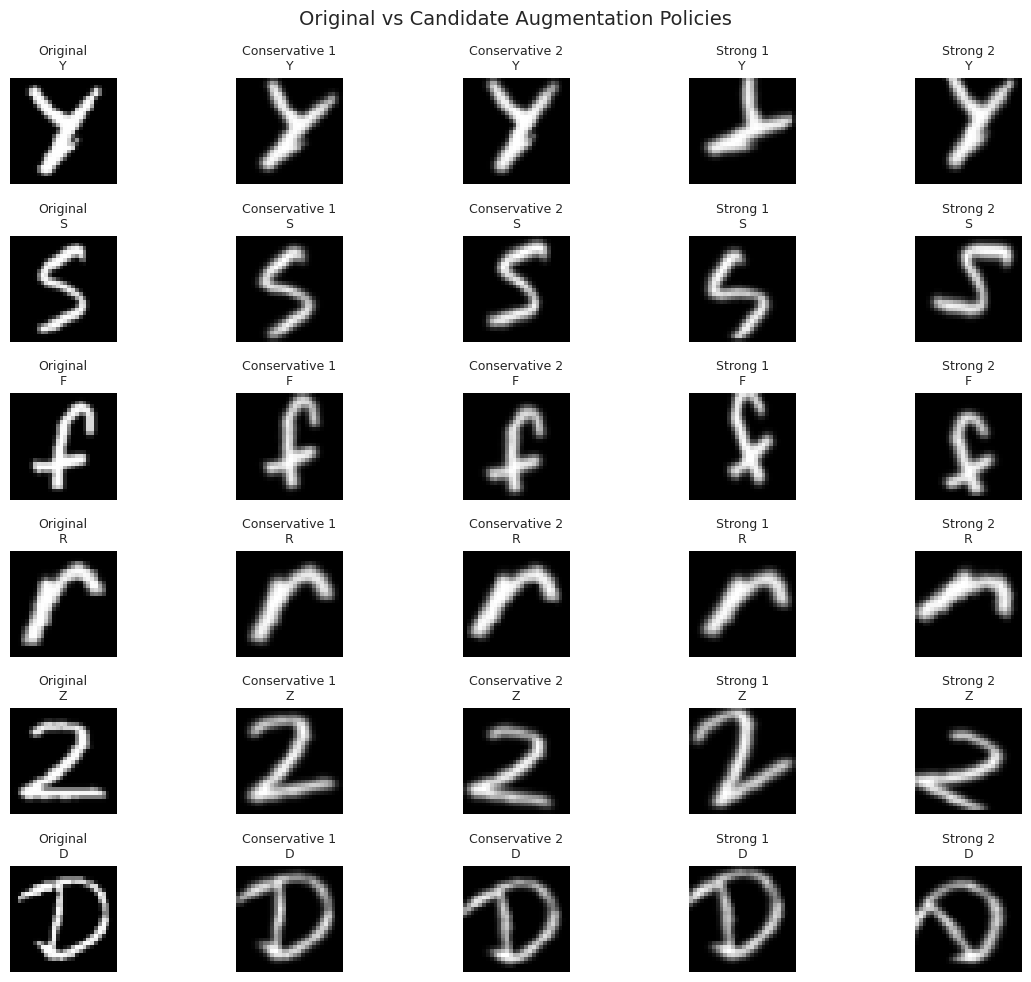

In [34]:
rng = np.random.default_rng(SEED)
sample_positions = rng.choice(len(X_train_images), size=6, replace=False)

fig, axes = plt.subplots(len(sample_positions), 5, figsize=(12, 10))

for row, pos in enumerate(sample_positions):
    original_image = X_train_images[pos]
    label = int(y_train[pos])
    letter = class_names[label]

    image_sets = [
        ("Original", original_image),
        ("Conservative 1", conservative_augmentation(original_image[np.newaxis, ...], training=True)[0].numpy()),
        ("Conservative 2", conservative_augmentation(original_image[np.newaxis, ...], training=True)[0].numpy()),
        ("Strong 1", strong_augmentation(original_image[np.newaxis, ...], training=True)[0].numpy()),
        ("Strong 2", strong_augmentation(original_image[np.newaxis, ...], training=True)[0].numpy())
    ]

    for col, (title, image) in enumerate(image_sets):
        axes[row, col].imshow(image.squeeze(), cmap="gray")
        axes[row, col].set_title(f"{title}\n{letter}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Original vs Candidate Augmentation Policies", fontsize=14)
plt.tight_layout()
plt.show()

The visual inspection confirms that the conservative augmentation policy generally preserves letter identity. The transformed images show small shifts, rotations, and zoom changes, but the letters remain recognisable and close to the original handwriting structure.

The strong augmentation policy is riskier. Some transformed images still look valid, but several examples show heavier distortion or movement. For example, the `Y`, `F`, `Z`, and `D` samples show cases where stronger rotation or shifting changes the visual structure more noticeably. This supports the earlier EDA-based concern that aggressive spatial transformations may crop or distort important strokes.

Based on this visual check, conservative augmentation appears safer, while strong augmentation remains useful as a comparison policy. No final augmentation choice is made here; the final decision will depend on validation loss, validation accuracy, macro F1, and learning-curve behaviour in Section 9.

### 6.8 Augmentation Experiment Plan

The augmentation policy is not selected in Section 6. This section only defines and visually checks the candidate transformations.

The no-augmentation policy will act as the reference condition. Conservative augmentation will test whether small identity-preserving transformations improve generalisation. Strong augmentation will test whether heavier transformations help robustness or instead damage validation performance by distorting letter structure.



---



## 7. Baseline Models

Before building improved CNN models, baseline models are used to establish reference performance. This prevents later model improvements from being judged in isolation.

The baselines in this section serve two purposes. First, the majority-class baseline gives the minimum benchmark that any useful model must beat. Second, the dense neural network baseline tests how well a simple neural network performs when the image is treated as a flattened vector instead of a spatial image.

These baselines help justify why a CNN is needed for the final image classifier.

### 7.1 Evaluation Metrics and Experiment Controls

Several metrics are used because accuracy alone does not fully describe model quality.

Validation loss measures optimisation quality and confidence behaviour. A model can have high accuracy but poor validation loss if it is overconfident or poorly calibrated.

Validation accuracy is still useful because the cleaned dataset has a balanced class distribution across the 26 letters. This makes accuracy a meaningful headline metric.

Macro F1 is used as the main prioritised validation metric for model comparison. Although the classes are balanced, this is a 26-class classification problem where weak performance on specific letters should matter. Macro F1 treats each class equally, so poor performance on visually similar letters such as `I/L`, `G/Q`, `O/Q`, `U/V`, and `M/N` is reflected more clearly.

Confusion matrices, classification reports, top confusion pairs, and misclassified examples will be used to understand class-level error patterns rather than only reporting a single score.

For trainable neural network models, `ModelCheckpoint` will be used to save the weights with the best validation loss. Each experiment will train for its full configured `max_epochs`, then reload the best validation-loss checkpoint before validation evaluation. `EarlyStopping` is not used by default because this notebook explicitly compares training duration and has enough resources to train each experiment fully.

`ReduceLROnPlateau` will only be used in the learning-rate adjustment experiments, and in the final candidate model only if validation results support it.

The validation set is used for all model-selection decisions. The test set remains untouched until the final model is locked in Section 10.

### 7.2 Majority-Class Baseline

The majority-class baseline predicts the most frequent training class for every validation image. This model does not learn from pixel values, so it acts as the minimum benchmark.

Because the cleaned dataset is highly balanced, this baseline is expected to perform poorly at around random-chance level for 26 classes. Any useful neural network should clearly outperform it.

In [35]:
train_label_counts = pd.Series(y_train).value_counts().sort_index()
majority_class = int(train_label_counts.idxmax())
majority_letter = class_names[majority_class]

y_val_majority_pred = np.full_like(y_val, fill_value=majority_class)

majority_accuracy = accuracy_score(y_val, y_val_majority_pred)
majority_macro_f1 = f1_score(y_val, y_val_majority_pred, average="macro", zero_division=0)
majority_weighted_f1 = f1_score(y_val, y_val_majority_pred, average="weighted", zero_division=0)

majority_baseline_results = pd.DataFrame([{
    "model": "Majority-class baseline",
    "majority_class": majority_class,
    "majority_letter": majority_letter,
    "val_accuracy": majority_accuracy,
    "val_macro_f1": majority_macro_f1,
    "val_weighted_f1": majority_weighted_f1
}])

display(majority_baseline_results)

print(f"Most frequent training class: {majority_letter} (encoded label {majority_class})")
print(f"Validation Accuracy: {majority_accuracy:.4f}")
print(f"Validation Macro F1: {majority_macro_f1:.4f}")
print(f"Validation Weighted F1: {majority_weighted_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_majority_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
))

,model,majority_class,majority_letter,val_accuracy,val_macro_f1,val_weighted_f1
0,Majority-class baseline,24,Y,0.038889,0.002879,0.002911


Most frequent training class: Y (encoded label 24)
Validation Accuracy: 0.0389
Validation Macro F1: 0.0029
Validation Weighted F1: 0.0029

Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       510
           B       0.00      0.00      0.00       510
           C       0.00      0.00      0.00       513
           D       0.00      0.00      0.00       510
           E       0.00      0.00      0.00       515
           F       0.00      0.00      0.00       509
           G       0.00      0.00      0.00       508
           H       0.00      0.00      0.00       513
           I       0.00      0.00      0.00       514
           J       0.00      0.00      0.00       511
           K       0.00      0.00      0.00       516
           L       0.00      0.00      0.00       512
           M       0.00      0.00      0.00       510
           N       0.00      0.00      0.00       504
           O       0.00    

The majority-class baseline performs at near-random level, as expected for a balanced 26-class dataset. It predicts `Y` for every validation image because `Y` is the most frequent training class, but this only gives a validation accuracy of `0.0389`.

The macro F1 score is extremely low at `0.0029` because the model completely ignores 25 out of 26 classes. The classification report confirms this: only class `Y` has recall, while every other letter has zero precision, recall, and F1.

This establishes the minimum benchmark. Any useful model must substantially exceed this baseline, especially in macro F1, because the task requires recognising all letters rather than exploiting small class-frequency differences.

### 7.3 Dense Neural Network Baseline

The dense neural network baseline uses the same processed image inputs, but flattens each `(28, 28, 1)` image into a one-dimensional vector before classification.

This baseline is useful because it tests whether a simple neural network can learn from the pixel values without using convolution. However, flattening removes the 2D spatial structure of the image, so the model cannot explicitly learn local stroke patterns in the same way as a CNN.

The model uses one hidden dense layer with dropout. `ModelCheckpoint` is used to save the best validation-loss weights, and the model is trained for the full configured epoch limit without `EarlyStopping`.

Model: "dense_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,834 (405.60 KB)

 Trainable params: 103,834 (405.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4532 - loss: 1.9641
Epoch 1: val_loss improved from None to 0.94479, saving model to dense_baseline_best.weights.h5

Epoch 1: finished saving model to dense_baseline_best.weights.h5
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5807 - loss: 1.4749 - val_accuracy: 0.7309 - val_loss: 0.9448
Epoch 2/20
233/243 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7157 - loss: 0.9708
Epoch 2: val_loss improved from 0.94479 to 0.73322, saving model to dense_baseline_best.weights.h5

Epoch 2: finished saving model to dense_baseline_best.weights.h5
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7305 - loss: 0.9179 - val_accuracy: 0.7870 - val_loss: 0.7332
Epoch 3/20
228/243 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7654 - loss: 0.7857
Epoch 3: val_loss improved from 0.73322 to 0.63044, saving model to dense_baseline_best.weights.h5

Epoch 3: finished saving model to dense_baseline_best.weights.h5
243/243 ━━━━━━━

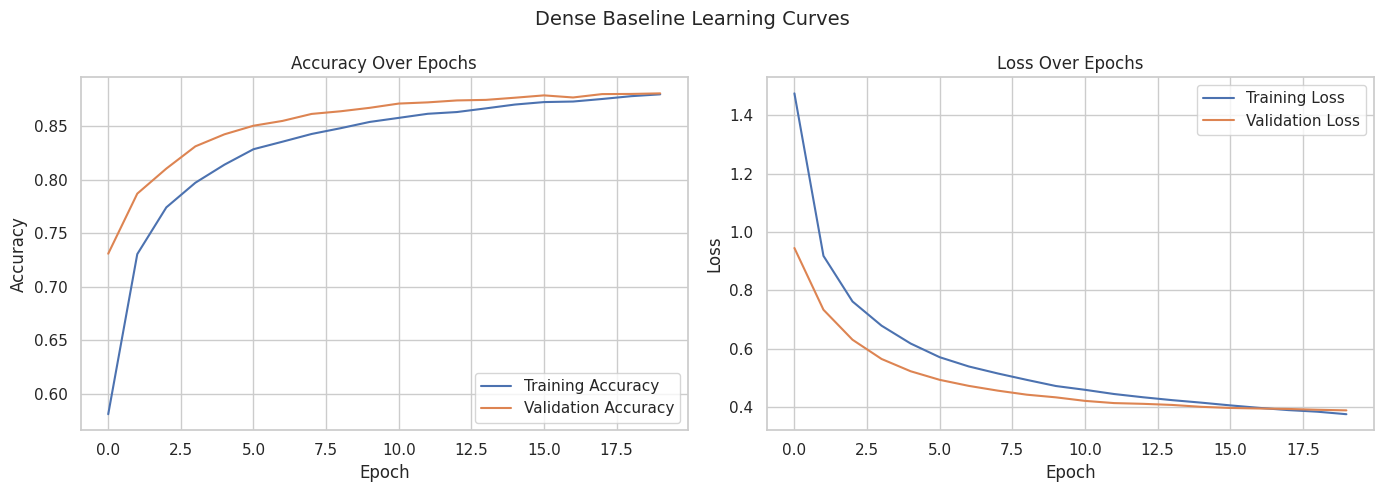

Dense Baseline Validation Accuracy: 0.8808
Dense Baseline Validation Macro F1: 0.8808
Dense Baseline Validation Weighted F1: 0.8808

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       510
           1       0.90      0.89      0.90       510
           2       0.90      0.94      0.92       513
           3       0.89      0.86      0.88       510
           4       0.93      0.89      0.91       515
           5       0.91      0.90      0.90       509
           6       0.76      0.72      0.74       508
           7       0.87      0.91      0.89       513
           8       0.72      0.68      0.70       514
           9       0.91      0.90      0.91       511
          10       0.93      0.88      0.91       516
          11       0.69      0.77      0.72       512
          12       0.96      0.93      0.94       510
          13       0.87      0.90      0.88       504
          14       0.92      0.94

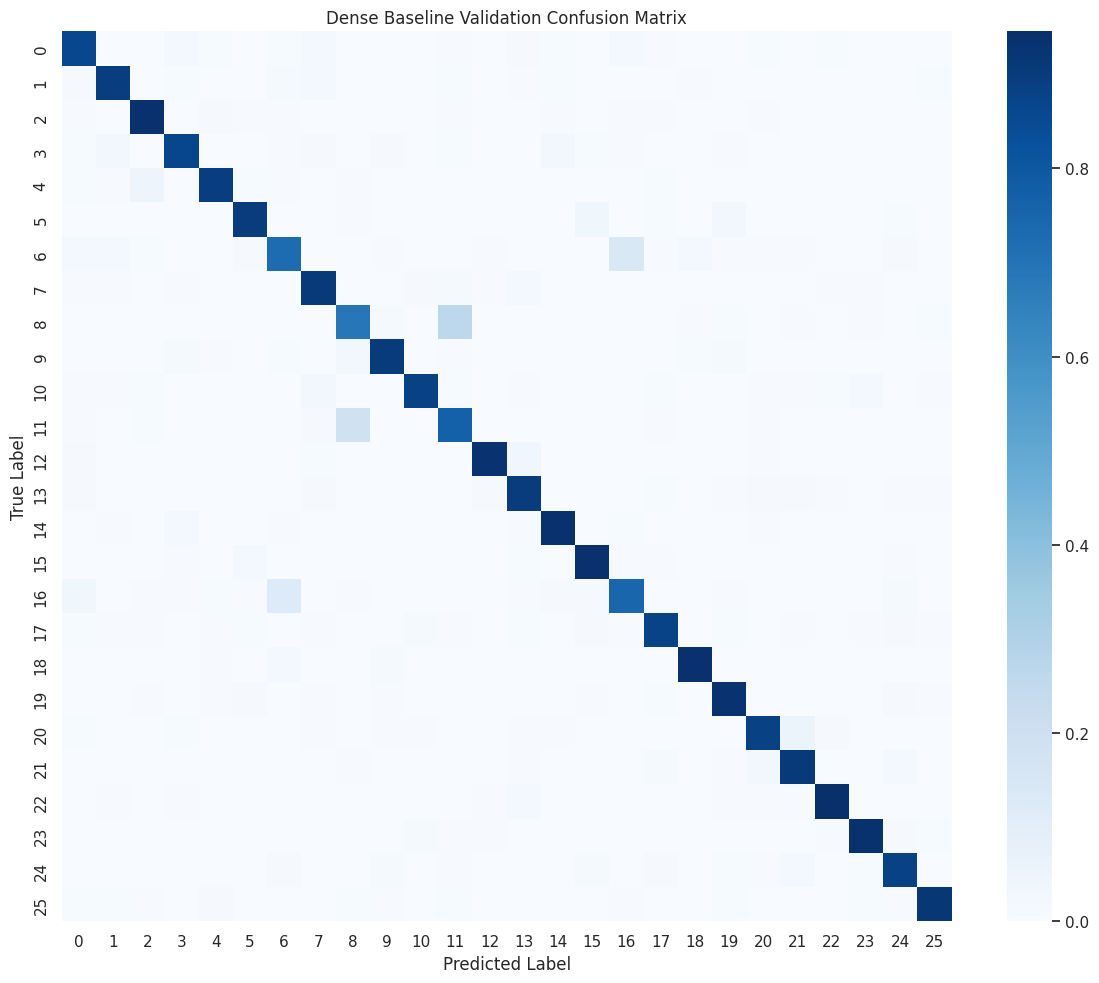

,true_label,predicted_label,count
122,8,11,135
160,11,8,98
98,6,16,73
218,16,6,63
283,20,21,29
64,4,2,26
212,16,0,20
85,5,15,19
172,12,13,18
56,3,14,16


In [36]:
dense_baseline_checkpoint_path = "dense_baseline_best.weights.h5"

dense_baseline_model = Sequential([
    Input(shape=input_shape),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
], name="dense_baseline")

dense_baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dense_baseline_model.summary()

dense_baseline_checkpoint = ModelCheckpoint(
    filepath=dense_baseline_checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

dense_baseline_epochs = 20
dense_baseline_batch_size = 256

dense_baseline_history = dense_baseline_model.fit(
    X_train_images,
    y_train,
    validation_data=(X_val_images, y_val),
    epochs=dense_baseline_epochs,
    batch_size=dense_baseline_batch_size,
    callbacks=[dense_baseline_checkpoint],
    verbose=1
)

dense_baseline_model.load_weights(dense_baseline_checkpoint_path)

plot_learning_curves(
    dense_baseline_history,
    title="Dense Baseline Learning Curves"
)

dense_baseline_eval = evaluate_classification_model(
    dense_baseline_model,
    X_val_images,
    y_val,
    class_names=class_names,
    dataset_name="Dense Baseline Validation"
)

plot_confusion_matrix(
    dense_baseline_eval["y_true"],
    dense_baseline_eval["y_pred"],
    class_names=class_names,
    title="Dense Baseline Validation Confusion Matrix",
    normalize="true"
)

dense_baseline_confusion_pairs = get_top_confusion_pairs(
    dense_baseline_eval["y_true"],
    dense_baseline_eval["y_pred"],
    class_names=class_names,
    top_n=10
)

display(dense_baseline_confusion_pairs)

### 7.4 Dense Baseline Results

The dense neural network baseline substantially outperforms the majority-class baseline. Validation accuracy increases from `0.0389` for the majority-class baseline to `0.8808`, while validation macro F1 increases from `0.0029` to `0.8808`. This confirms that the pixel values contain enough signal for a neural network to learn meaningful letter patterns.

The dense baseline's best validation loss occurred at epoch 20 with `val_loss = 0.3884`. The learning curves show steady improvement across the full 20 epochs, and validation performance remains close to training performance. This suggests that the dense baseline does not suffer from severe overfitting, although its performance is still limited by the flattened input representation.

However, the confusion matrix and top confusion pairs show clear class-level weaknesses. The largest errors are mainly between visually similar letters, especially `I/L` and `G/Q`. Other errors such as `U/V`, `E/C`, `Q/A`, `F/P`, `M/N`, and `D/O` also support the earlier expectation that similar-looking handwritten letters would be harder to separate.

This baseline is useful but limited. It learns from pixel values, but because it flattens each image into 784 independent inputs, it does not explicitly preserve local 2D stroke structure. A CNN should improve on this by learning local edges, curves, and stroke combinations through convolution and pooling.

### 7.5 Dense Baseline Judgment

The dense baseline is a credible neural network benchmark, not just a weak placeholder. It achieves strong validation performance and clearly beats the majority-class baseline.

At the same time, the model still makes systematic mistakes on visually similar letters. This supports moving to a CNN architecture because the task depends on local spatial patterns, not only individual pixel intensities.

The next model should therefore preserve the `(28, 28, 1)` image structure and use convolutional layers to learn local stroke features directly.



---



## 8. Initial CNN Baseline

The dense neural network baseline showed that the pixel values contain strong predictive signal, but it still flattened each image into a 784-value vector. This removes the explicit 2D spatial structure of the handwritten letters.

The purpose of this section is to build the first proper CNN baseline using the `(28, 28, 1)` image inputs prepared in Section 5. This model is intentionally kept simple so that later improvements in Section 9 can be judged against a clear CNN reference point.

### 8.1 CNN Baseline Hypothesis

The CNN baseline is expected to outperform the dense neural network baseline because handwritten letters are made of local stroke patterns, curves, corners, and intersections arranged across a 2D image grid.

Unlike the dense baseline, a CNN preserves the spatial layout of the image. Convolutional filters can learn local visual features, while pooling can provide some tolerance to small shifts in handwriting position.

Based on the EDA and dense baseline results, the main expectation is not only higher validation accuracy and macro F1, but also fewer systematic mistakes among visually similar classes such as `I/L`, `G/Q`, `O/Q`, `U/V`, and `M/N`.

### 8.2 CNN Baseline Architecture

The first CNN baseline uses a simple architecture with one convolutional block. This keeps the model easy to interpret and gives a clean reference before the more controlled improvement experiments in Section 9.

The convolutional layer uses 32 filters with a `3x3` kernel as a moderate starting capacity for 28x28 greyscale letter images, to learn local stroke patterns such as edges, curves, and corners. `padding="same"` keeps the spatial size stable after convolution, while the default stride of `1` scans the image one pixel at a time.

Since the input images are small, starting with a very large number of filters at the first layer would increase computation and overfitting risk before proving that extra capacity is useful. Larger filter configurations are tested later in the controlled model improvement section rather than assumed at the baseline stage.

A `2x2` max-pooling layer then reduces the spatial size of the feature maps, lowering computation and providing some tolerance to small position changes. Dropout is included as a simple regularisation step before the dense classifier.

No augmentation is used in this initial CNN baseline. Augmentation is evaluated later as a controlled experiment.

In [37]:
cnn_baseline_model = Sequential([
    Input(shape=input_shape),
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(num_classes, activation="softmax")
], name="cnn_baseline")

cnn_baseline_model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,618 (3.08 MB)

 Trainable params: 806,618 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

The CNN baseline has `806,618` trainable parameters. Most of these parameters come from the dense layer after flattening, not from the convolutional layer. The `Conv2D` layer has only `320` parameters, while the first dense layer has `802,944` parameters because the pooled feature maps are flattened into `6,272` inputs before being connected to 128 dense units.

This confirms that even a simple CNN can become parameter-heavy after flattening. The model is still suitable as an initial CNN baseline because it has only one convolutional block and no augmentation or advanced regularisation beyond dropout.

### 8.3 Training Setup

The CNN baseline is trained using the same validation discipline as the dense baseline. The model is trained on the training set only, while the validation set is used to monitor generalisation.

`ModelCheckpoint` is used to save the weights with the lowest validation loss. The model is still trained for the full configured `max_epochs`; `EarlyStopping` is not used. After training, the best validation-loss weights are reloaded before evaluation.

This keeps the training process consistent with the callback policy and avoids using the test set before the final locked model.

In [38]:
cnn_baseline_checkpoint_path = "cnn_baseline_best.weights.h5"

cnn_baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_baseline_checkpoint = ModelCheckpoint(
    filepath=cnn_baseline_checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

cnn_baseline_epochs = 20
cnn_baseline_batch_size = 256

cnn_baseline_history = cnn_baseline_model.fit(
    X_train_images,
    y_train,
    validation_data=(X_val_images, y_val),
    epochs=cnn_baseline_epochs,
    batch_size=cnn_baseline_batch_size,
    callbacks=[cnn_baseline_checkpoint],
    verbose=1
)

cnn_baseline_model.load_weights(cnn_baseline_checkpoint_path)

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5788 - loss: 1.5222
Epoch 1: val_loss improved from None to 0.60057, saving model to cnn_baseline_best.weights.h5

Epoch 1: finished saving model to cnn_baseline_best.weights.h5
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6995 - loss: 1.0492 - val_accuracy: 0.8206 - val_loss: 0.6006
Epoch 2/20
239/243 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8359 - loss: 0.5464
Epoch 2: val_loss improved from 0.60057 to 0.41673, saving model to cnn_baseline_best.weights.h5

Epoch 2: finished saving model to cnn_baseline_best.weights.h5
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8488 - loss: 0.4977 - val_accuracy: 0.8705 - val_loss: 0.4167
Epoch 3/20
238/243 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8776 - loss: 0.3926
Epoch 3: val_loss improved from 0.41673 to 0.35533, saving model to cnn_baseline_best.weights.h5

Epoch 3: finished saving model to cnn_baseline_best.weights.h5
243/243 ━━━━━━━━━━━━━━━━━━

The CNN baseline was trained for the full 20 epochs without early stopping. `ModelCheckpoint` saved the best validation-loss weights during training.

The best validation loss occurred at epoch 12 with `val_loss = 0.2762`. After this point, training accuracy continued to increase, but validation loss gradually worsened. This suggests mild overfitting after epoch 12. Therefore, the model weights from the best validation-loss epoch are used for validation evaluation instead of the final epoch weights.

### 8.4 CNN Baseline Results

The CNN baseline is evaluated using the best validation-loss checkpoint saved during training. The evaluation includes learning curves, validation metrics, a confusion matrix, and the top confusion pairs.

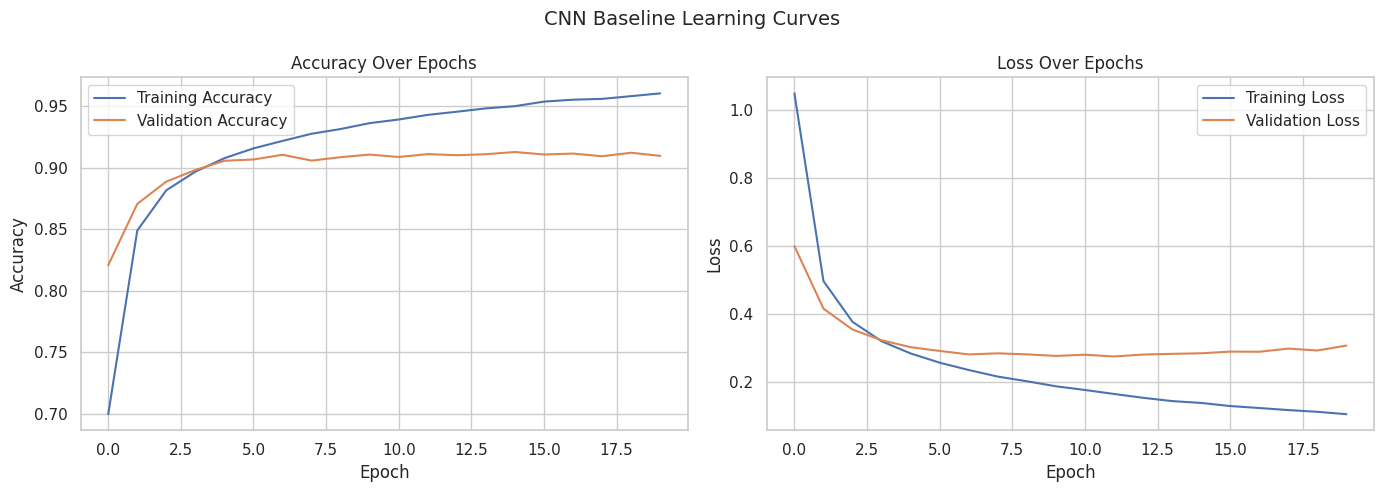

CNN Baseline Validation Accuracy: 0.9110
CNN Baseline Validation Macro F1: 0.9108
CNN Baseline Validation Weighted F1: 0.9108

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       510
           1       0.95      0.89      0.92       510
           2       0.95      0.96      0.95       513
           3       0.97      0.88      0.92       510
           4       0.92      0.96      0.94       515
           5       0.94      0.96      0.95       509
           6       0.86      0.75      0.80       508
           7       0.92      0.94      0.93       513
           8       0.75      0.64      0.69       514
           9       0.92      0.92      0.92       511
          10       0.96      0.96      0.96       516
          11       0.68      0.80      0.74       512
          12       0.97      0.96      0.96       510
          13       0.93      0.91      0.92       504
          14       0.93      0.97      

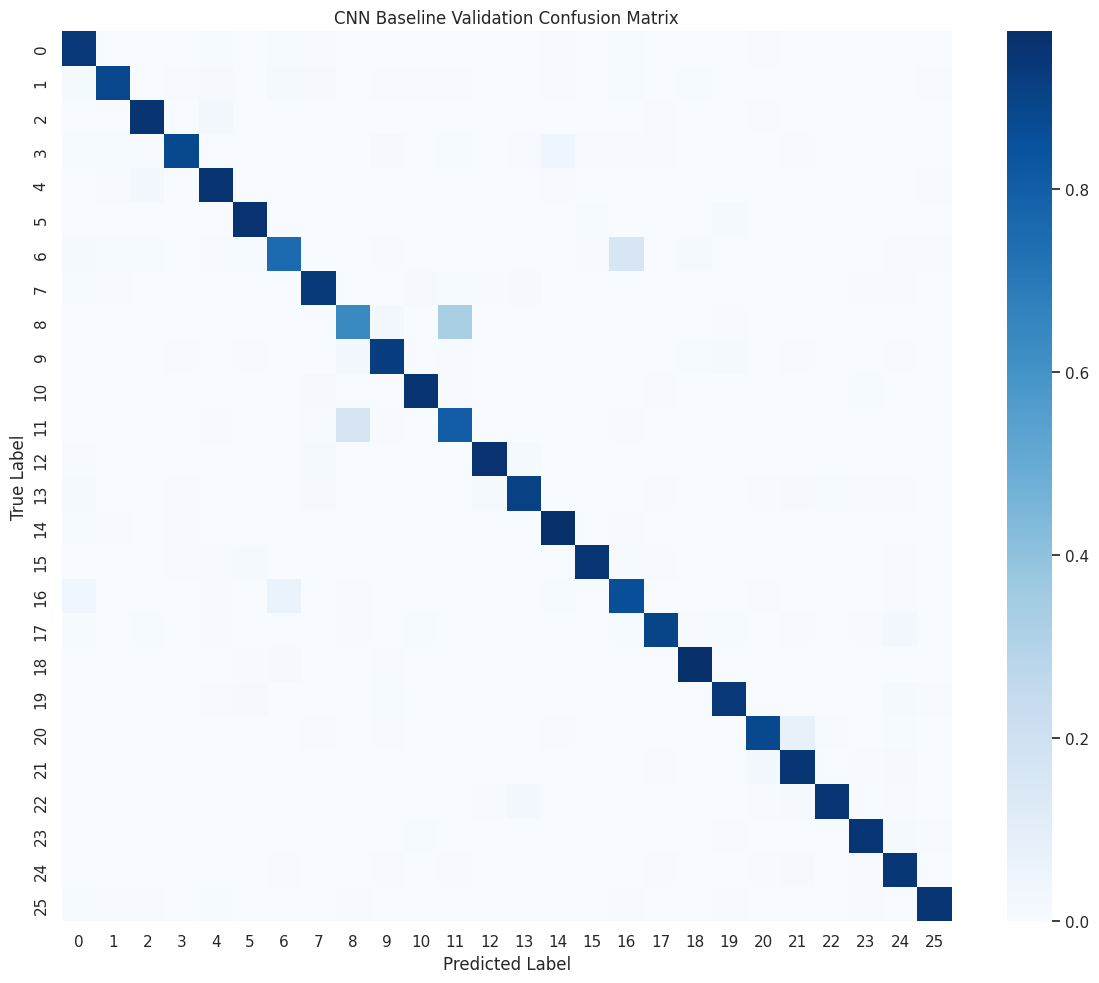

,true_label,predicted_label,count
104,8,11,171
137,11,8,85
84,6,16,81
229,20,21,40
181,16,6,34
50,3,14,22
176,16,0,19
32,2,4,12
237,21,20,12
111,9,8,11


In [39]:
plot_learning_curves(
    cnn_baseline_history,
    title="CNN Baseline Learning Curves"
)

cnn_baseline_eval = evaluate_classification_model(
    cnn_baseline_model,
    X_val_images,
    y_val,
    class_names=class_names,
    dataset_name="CNN Baseline Validation"
)

plot_confusion_matrix(
    cnn_baseline_eval["y_true"],
    cnn_baseline_eval["y_pred"],
    class_names=class_names,
    title="CNN Baseline Validation Confusion Matrix",
    normalize="true"
)

cnn_baseline_confusion_pairs = get_top_confusion_pairs(
    cnn_baseline_eval["y_true"],
    cnn_baseline_eval["y_pred"],
    class_names=class_names,
    top_n=10
)

display(cnn_baseline_confusion_pairs)

The CNN baseline improves clearly over the dense neural network baseline. Validation accuracy increases from `0.8808` to `0.9110`, and validation macro F1 increases from `0.8808` to `0.9108`. This supports the hypothesis that preserving the 2D image structure helps the model learn handwritten letter patterns more effectively than using flattened pixels alone.

The learning curves show that the CNN learns quickly in the first few epochs. However, after epoch 12, training accuracy continues to rise while validation loss stops improving and gradually increases. This indicates mild overfitting. The use of `ModelCheckpoint` is important here because the evaluation uses the best validation-loss weights rather than the final epoch weights.

The confusion matrix shows a stronger diagonal than the dense baseline, meaning most classes are predicted correctly. However, the main error patterns remain visually similar letters. The largest confusion pairs are `I → L`, `L → I`, `G → Q`, `U → V`, and `Q → G`. Other remaining errors such as `D → O`, `Q → A`, `C → E`, and `V → U` show that class-level ambiguity is still present.

Overall, the CNN baseline is a meaningful improvement, but it is not yet the final model. The remaining overfitting pattern and persistent similar-letter confusions motivate the controlled model-improvement experiments in Section 9.

### 8.5 CNN Baseline Diagnosis

The CNN baseline successfully improves on the dense baseline, showing that convolutional feature learning is useful for this image classification task.

The main limitation is mild overfitting. Training accuracy continues to improve after the best validation-loss epoch, but validation loss worsens. This suggests that the model has enough capacity to fit the training set, but its generalisation can still be improved.

The second limitation is class-level confusion. The strongest errors are still between visually similar letters, especially `I/L` and `G/Q`. This means the next stage should not only chase higher overall accuracy, but should also check macro F1, validation loss, learning curves, and confusion pairs.

Section 9 therefore focuses on controlled improvements: training protocol choices, CNN capacity, dropout, batch normalisation, augmentation strength, and learning-rate adjustment. These experiments will use validation results only, while the test set remains untouched.



---



> Note: The following model-improvement experiments are computationally expensive. After the final clean run, these cells should not be rerun unless the experiment design changes. The saved notebook outputs and saved best model weights are used for reporting and submission.

---

## 9. Hypothesis-Driven Model Improvement

Section 9 improves the CNN baseline through a controlled experiment sequence. Each experiment changes one main modelling decision at a time while keeping the rest of the setup fixed as much as possible.

The purpose is not to search every possible model. The purpose is to make defensible, validation-based improvements to the CNN using a predefined search space.

The test set remains untouched throughout Section 9. It will only be used once in Section 10 after the final model is locked.

### 9.1 Experiment Setup and Decision Rule

The Section 9 experiments use a consistent training and evaluation workflow to compare model-improvement choices fairly.

For every trainable model:

- the model is trained on the training set only
- the validation set is used for model selection
- `ModelCheckpoint` saves the best validation-loss weights
- the full configured number of epochs is completed
- `EarlyStopping` is not used
- the best validation-loss weights are reloaded before validation evaluation
- the test set is not used

The master experiment table records the main validation metrics, checkpoint path, best epoch, overfitting observation, and decision for each experiment. Since many candidate settings are tested in Section 9, summary tables are used for controlled comparison across experiments. This is easier to audit than plotting separate learning curves, confusion matrices, and class-level reports for every candidate model. Detailed diagnostics such as learning curves, confusion matrices, classification reports, misclassified examples, and confidence analysis are reserved for the baseline and final selected model, where deeper interpretation is most useful.

The selection rule is:

1. Primary metric: validation macro F1
2. Secondary metric: validation loss
3. Then validation accuracy
4. Then training-history behaviour and overfitting observation
5. If results are practically tied, prefer the simpler or cheaper setting

Validation macro F1 is prioritised because this is a 26-class classification task. Accuracy is still meaningful because the class distribution is balanced, but macro F1 gives equal weight to each class and makes class-level weakness harder to hide. Validation weighted F1 is also recorded as a supporting metric to check whether overall class-weighted performance is consistent with the macro F1 result.

The `overfitting_observation` column is used as a lightweight diagnostic summary from the stored training history rather than as a formal statistical test. The gap thresholds are heuristic values chosen to flag clearly visible train-validation separation: an accuracy gap above `0.08` or loss gap above `0.30` is treated as clear overfitting, while smaller gaps above `0.04` accuracy or `0.15` loss are treated as mild overfitting. These observations provide supporting context only; they are not the main selection rule.

Underfitting is assessed mainly through weak validation performance relative to other candidates, especially when both training and validation results are low. Therefore, the experiment table focuses on selecting the model with the strongest validation generalisation, while the overfitting observation column helps identify whether poor validation performance may be linked to a large train-validation gap.

All hidden convolutional and dense layers in Section 9 use ReLU activation. ReLU is kept fixed because it is a standard activation for CNN hidden layers, trains efficiently, and works well with gradient-based optimisation. The purpose of Section 9 is to compare higher-impact modelling choices such as architecture depth/width, regularisation, BatchNorm, augmentation, and learning-rate strategy, rather than expand the search space to activation functions.

The output layer uses softmax because this is a 26-class single-label classification task. Softmax converts the final outputs into class probabilities across the 26 letter classes and matches the `sparse_categorical_crossentropy` loss used throughout the notebook.

In [42]:
# Section 9 experiment setup

import os

os.makedirs("checkpoints", exist_ok=True)

section9_results = []

experiment_columns = [
    "experiment_group",
    "experiment",
    "hypothesis",
    "controlled_change",
    "fixed_settings",
    "max_epochs",
    "batch_size",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "overfitting_observation",
    "checkpoint_path",
    "decision"
]

def sec9_format_label(label, class_names=None):
    label = int(label)

    if class_names is None:
        return str(label)

    if isinstance(class_names, dict):
        return str(class_names.get(label, label))

    if isinstance(class_names, (list, tuple, np.ndarray)):
        if 0 <= label < len(class_names):
            return str(class_names[label])

    return str(label)

def sec9_best_epoch(history, monitor="val_loss"):
    values = history.history.get(monitor)

    if values is None:
        return None

    return int(np.argmin(values) + 1)

def sec9_overfitting_observation(history):
    history_df = pd.DataFrame(history.history)

    if not {"accuracy", "val_accuracy", "loss", "val_loss"}.issubset(history_df.columns):
        return "Learning-curve data incomplete."

    final_train_acc = history_df["accuracy"].iloc[-1]
    final_val_acc = history_df["val_accuracy"].iloc[-1]
    final_train_loss = history_df["loss"].iloc[-1]
    final_val_loss = history_df["val_loss"].iloc[-1]

    acc_gap = final_train_acc - final_val_acc
    loss_gap = final_val_loss - final_train_loss

    if acc_gap > 0.08 or loss_gap > 0.30:
        return "Clear overfitting: training performance is much stronger than validation performance."

    if acc_gap > 0.04 or loss_gap > 0.15:
        return "Mild overfitting: validation performance trails training performance."

    return "No severe overfitting: training and validation performance remain reasonably close."

def sec9_evaluate_model(model, X_val, y_val):
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    y_pred, y_proba = get_predictions(model, X_val)

    val_macro_f1 = f1_score(y_val, y_pred, average="macro")
    val_weighted_f1 = f1_score(y_val, y_pred, average="weighted")

    return {
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

def sec9_add_result(
    experiment_group,
    experiment,
    hypothesis,
    controlled_change,
    fixed_settings,
    max_epochs,
    batch_size,
    best_epoch,
    metrics,
    overfitting_observation,
    checkpoint_path,
    decision="Pending"
):
    section9_results.append({
        "experiment_group": experiment_group,
        "experiment": experiment,
        "hypothesis": hypothesis,
        "controlled_change": controlled_change,
        "fixed_settings": fixed_settings,
        "max_epochs": max_epochs,
        "batch_size": batch_size,
        "best_epoch": best_epoch,
        "val_loss": metrics["val_loss"],
        "val_accuracy": metrics["val_accuracy"],
        "val_macro_f1": metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "overfitting_observation": overfitting_observation,
        "checkpoint_path": checkpoint_path,
        "decision": decision
    })

def sec9_results_df():
    return pd.DataFrame(section9_results, columns=experiment_columns)

def sec9_select_best(results_df):
    return (
        results_df
        .sort_values(
            by=["val_macro_f1", "val_loss", "val_accuracy"],
            ascending=[False, True, False]
        )
        .iloc[0]
    )

def sec9_train_and_evaluate(
    build_model_fn,
    experiment_group,
    experiment,
    hypothesis,
    controlled_change,
    fixed_settings,
    max_epochs,
    batch_size,
    checkpoint_path,
    callbacks_extra=None,
    verbose=1
):
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_model_fn()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )

    callbacks = [checkpoint]

    if callbacks_extra is not None:
        callbacks.extend(callbacks_extra)

    history = model.fit(
        X_train_images,
        y_train,
        validation_data=(X_val_images, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    model.load_weights(checkpoint_path)

    metrics = sec9_evaluate_model(model, X_val_images, y_val)
    best_epoch = sec9_best_epoch(history)
    overfitting_observation = sec9_overfitting_observation(history)

    sec9_add_result(
        experiment_group=experiment_group,
        experiment=experiment,
        hypothesis=hypothesis,
        controlled_change=controlled_change,
        fixed_settings=fixed_settings,
        max_epochs=max_epochs,
        batch_size=batch_size,
        best_epoch=best_epoch,
        metrics=metrics,
        overfitting_observation=overfitting_observation,
        checkpoint_path=checkpoint_path
    )

    print(f"Experiment: {experiment}")
    print(f"Best epoch: {best_epoch}")
    print(f"Validation loss: {metrics['val_loss']:.4f}")
    print(f"Validation accuracy: {metrics['val_accuracy']:.4f}")
    print(f"Validation macro F1: {metrics['val_macro_f1']:.4f}")
    print(f"Validation weighted F1: {metrics['val_weighted_f1']:.4f}")
    print(overfitting_observation)

    return model, history, metrics

### 9.2 Reference CNN for Controlled Experiments

A stable reference CNN is used as the starting point for the Section 9 controlled experiments.

The reference architecture is:

```text
Input
Conv2D 32
MaxPooling2D
Conv2D 64
MaxPooling2D
Dropout 0.3
Flatten
Dense 128
Dense 26 softmax
```

The starting training schedule is:

```text
batch_size = 256
max_epochs = 20
Adam learning rate = 0.001
no augmentation
no BatchNorm
```

The two-block 32/64 CNN is chosen because the input images are small 28×28 grayscale letters with important stroke information concentrated near the centre. Two pooling steps reduce the spatial dimensions from 28×28 → 14×14 → 7×7 before flattening, which keeps enough spatial structure for stroke patterns while reducing computation and dense-layer size.

This makes the reference CNN stronger than the initial one-block CNN baseline, but still compact enough to use as a controlled starting point for later experiments.

The convolutional layers use 3×3 kernels, stride 1, and same padding. This keeps local stroke extraction simple and consistent while avoiding unnecessary spatial shrinkage before pooling.

In [44]:
# Reference CNN builder for Section 9 controlled experiments

def build_reference_cnn():
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(
            filters=32,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),
        MaxPooling2D(pool_size=(2, 2)),

        Dropout(0.3),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(num_classes, activation="softmax")
    ], name="reference_cnn")

    return model

reference_cnn_model = build_reference_cnn()
reference_cnn_model.summary()

reference_batch_size = 256
reference_max_epochs = 20

print("Reference batch size:", reference_batch_size)
print("Reference max epochs:", reference_max_epochs)
print("Reference optimiser: Adam learning rate 0.001")
print("Reference augmentation: None")
print("Reference BatchNorm: False")

Model: "reference_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,706 (1.62 MB)

 Trainable params: 423,706 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

Reference batch size: 256
Reference max epochs: 20
Reference optimiser: Adam learning rate 0.001
Reference augmentation: None
Reference BatchNorm: False


### 9.3 Training Protocol Comparison

This experiment selects the training protocol for later Section 9 experiments.

The fixed grid is:

```text
batch_size = [64, 128, 256]
max_epochs = [20, 40, 60]
```

The model architecture is kept fixed as the reference CNN from Section 9.2. Dropout remains at 0.3, augmentation is not used, BatchNorm is not used, and Adam uses a fixed learning rate of 0.001.

This comparison avoids making separate ad-hoc decisions about batch size and training duration. Instead, batch size and maximum epochs are selected together using one validation-based comparison table.

The batch-size range is also tied to the dataset size. With approximately 88,800 cleaned samples before splitting, smaller batches create more gradient updates per epoch than larger batches. Smaller batches may introduce more gradient noise and sometimes improve generalisation, while larger batches train with fewer updates per epoch and may converge differently.

The selected protocol will be carried forward into the later architecture, regularisation, BatchNorm, augmentation, and learning-rate experiments.

In [45]:
# 9.3 Training Protocol Comparison

training_protocol_runs = []

batch_size_options = [64, 128, 256]
max_epoch_options = [20, 40, 60]

for batch_size in batch_size_options:
    for max_epochs in max_epoch_options:
        experiment_name = f"reference_cnn_bs{batch_size}_ep{max_epochs}"
        checkpoint_path = f"checkpoints/sec9_3_{experiment_name}.weights.h5"

        print("\n" + "=" * 80)
        print(f"Running: {experiment_name}")
        print("=" * 80)

        model, history, metrics = sec9_train_and_evaluate(
            build_model_fn=build_reference_cnn,
            experiment_group="Training protocol",
            experiment=experiment_name,
            hypothesis="Training duration and batch size may affect convergence and generalisation.",
            controlled_change=f"batch_size={batch_size}, max_epochs={max_epochs}",
            fixed_settings="Reference CNN, dropout=0.3, no augmentation, no BatchNorm, Adam lr=0.001",
            max_epochs=max_epochs,
            batch_size=batch_size,
            checkpoint_path=checkpoint_path,
            callbacks_extra=None,
            verbose=1
        )

        training_protocol_runs.append({
            "experiment": experiment_name,
            "batch_size": batch_size,
            "max_epochs": max_epochs,
            "history": history,
            "metrics": metrics,
            "checkpoint_path": checkpoint_path
        })

training_protocol_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Training protocol'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

training_protocol_comparison


Running: reference_cnn_bs64_ep20
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7975 - loss: 0.6566 - val_accuracy: 0.8988 - val_loss: 0.3152
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8965 - loss: 0.3133 - val_accuracy: 0.9152 - val_loss: 0.2572
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9160 - loss: 0.2493 - val_accuracy: 0.9206 - val_loss: 0.2373
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9266 - loss: 0.2140 - val_accuracy: 0.9240 - val_loss: 0.2280
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9334 - loss: 0.1900 - val_accuracy: 0.9261 - val_loss: 0.2205
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9402 - loss: 0.1671 - val_accuracy: 0.9256 - val_loss: 0.2265
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9433 - loss: 0.1545 - val_accuracy: 0.9302 - val_loss: 0.2179
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.94

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Training protocol,reference_cnn_bs64_ep20,Training duration and batch size may affect co...,"batch_size=64, max_epochs=20","Reference CNN, dropout=0.3, no augmentation, n...",20,64,7,0.217911,0.930180,0.930096,0.930093,Mild overfitting: validation performance trail...,checkpoints/sec9_3_reference_cnn_bs64_ep20.wei...,Pending
1,Training protocol,reference_cnn_bs256_ep20,Training duration and batch size may affect co...,"batch_size=256, max_epochs=20","Reference CNN, dropout=0.3, no augmentation, n...",20,256,10,0.217268,0.929279,0.929186,0.929185,Mild overfitting: validation performance trail...,checkpoints/sec9_3_reference_cnn_bs256_ep20.we...,Pending
2,Training protocol,reference_cnn_bs64_ep60,Training duration and batch size may affect co...,"batch_size=64, max_epochs=60","Reference CNN, dropout=0.3, no augmentation, n...",60,64,5,0.217650,0.928378,0.928438,0.928462,Clear overfitting: training performance is muc...,checkpoints/sec9_3_reference_cnn_bs64_ep60.wei...,Pending
3,Training protocol,reference_cnn_bs256_ep60,Training duration and batch size may affect co...,"batch_size=256, max_epochs=60","Reference CNN, dropout=0.3, no augmentation, n...",60,256,12,0.223474,0.927027,0.926872,0.926869,Clear overfitting: training performance is muc...,checkpoints/sec9_3_reference_cnn_bs256_ep60.we...,Pending
4,Training protocol,reference_cnn_bs128_ep60,Training duration and batch size may affect co...,"batch_size=128, max_epochs=60","Reference CNN, dropout=0.3, no augmentation, n...",60,128,8,0.222545,0.926727,0.926768,0.926756,Clear overfitting: training performance is muc...,checkpoints/sec9_3_reference_cnn_bs128_ep60.we...,Pending
5,Training protocol,reference_cnn_bs256_ep40,Training duration and batch size may affect co...,"batch_size=256, max_epochs=40","Reference CNN, dropout=0.3, no augmentation, n...",40,256,8,0.224668,0.926126,0.926104,0.926102,Mild overfitting: validation performance trail...,checkpoints/sec9_3_reference_cnn_bs256_ep40.we...,Pending
6,Training protocol,reference_cnn_bs64_ep40,Training duration and batch size may affect co...,"batch_size=64, max_epochs=40","Reference CNN, dropout=0.3, no augmentation, n...",40,64,6,0.224341,0.925751,0.925577,0.925588,Clear overfitting: training performance is muc...,checkpoints/sec9_3_reference_cnn_bs64_ep40.wei...,Pending
7,Training protocol,reference_cnn_bs128_ep40,Training duration and batch size may affect co...,"batch_size=128, max_epochs=40","Reference CNN, dropout=0.3, no augmentation, n...",40,128,7,0.223075,0.925375,0.925292,0.925295,Mild overfitting: validation performance trail...,checkpoints/sec9_3_reference_cnn_bs128_ep40.we...,Pending
8,Training protocol,reference_cnn_bs128_ep20,Training duration and batch size may affect co...,"batch_size=128, max_epochs=20","Reference CNN, dropout=0.3, no augmentation, n...",20,128,7,0.224224,0.921922,0.921156,0.921158,Mild overfitting: validation performance trail...,checkpoints/sec9_3_reference_cnn_bs128_ep20.we...,Pending


In [47]:
selected_batch_size = 64
selected_max_epochs = 20

selected_training_protocol = training_protocol_comparison[
    (training_protocol_comparison["batch_size"] == selected_batch_size) &
    (training_protocol_comparison["max_epochs"] == selected_max_epochs)
].iloc[0]

print("Selected batch size:", selected_batch_size)
print("Selected max epochs:", selected_max_epochs)
print("Selected training protocol experiment:", selected_training_protocol["experiment"])
print("Validation loss:", round(selected_training_protocol["val_loss"], 4))
print("Validation accuracy:", round(selected_training_protocol["val_accuracy"], 4))
print("Validation macro F1:", round(selected_training_protocol["val_macro_f1"], 4))
print("Validation weighted F1:", round(selected_training_protocol["val_weighted_f1"], 4))
print("Best epoch:", selected_training_protocol["best_epoch"])

Selected batch size: 64
Selected max epochs: 20
Selected training protocol experiment: reference_cnn_bs64_ep20
Validation loss: 0.2179
Validation accuracy: 0.9302
Validation macro F1: 0.9301
Validation weighted F1: 0.9301
Best epoch: 7


#### 9.3 Training Protocol Result

The selected training protocol is `batch_size = 64` and `max_epochs = 20`.

This setting achieved the highest validation macro F1 among the tested training-protocol candidates:

```text
validation loss = 0.2179
validation accuracy = 0.9302
validation macro F1 = 0.9301
validation weighted F1 = 0.9301
best epoch = 7
```

This choice follows the Section 9 decision rule directly. Validation macro F1 is the primary selection metric because this is a 26-class classification task where class-level weaknesses should not be hidden by overall accuracy. Since `reference_cnn_bs64_ep20` achieved the best validation macro F1, it is selected for the later controlled experiments.

The result also supports using a shorter training duration. Longer schedules such as 40 and 60 epochs did not produce better validation macro F1 and showed stronger overfitting patterns. This suggests that extending training time mainly allows the model to fit the training data more strongly without improving validation generalisation.

Although larger batch sizes such as 128 and 256 are computationally cheaper, they did not outperform batch size 64 on the primary metric. Therefore, the slightly higher training cost is justified because the selected setting gives the strongest validation macro F1 within the predefined grid.

The selected training protocol for the remaining Section 9 experiments is:

```text
batch_size = 64
max_epochs = 20
```

### 9.4 CNN Capacity Comparison

This experiment tests whether changing CNN capacity improves validation performance.

The selected training protocol from Section 9.3 is used:

```text
batch_size = 64
max_epochs = 20
```

The fixed settings are:

```text
dropout = 0.3
no augmentation
no BatchNorm
Adam learning rate = 0.001
```

The capacity comparison tests five architecture variants:

```text
Shallow CNN:        1 conv block, 32 filters, pooling after block 1
Reference CNN:      2 conv blocks, 32/64 filters, pooling after blocks 1 and 2
Wider CNN:          2 conv blocks, 64/128 filters, pooling after blocks 1 and 2
Deeper CNN:         3 conv blocks, 32/64/128 filters, pooling after blocks 1, 2, and 3
Deeper-no-pool CNN: 3 conv blocks, 32/64/128 filters, pooling after blocks 1 and 2 only
```

The capacity comparison tests both width and depth. A wider CNN tests whether more filters at the same depth can capture richer local stroke features. A deeper CNN tests whether an additional convolutional block can learn more hierarchical stroke representations before classification.

This is motivated by the earlier confusion-pair findings. Similar handwritten letters such as `I/L`, `G/Q`, `O/Q`, `U/V`, and `M/N` may require the model to recognise structural shape differences, not just simple local edges.

The deeper CNN adds a third pooling stage, reducing spatial dimensions from `28×28 → 14×14 → 7×7 → 3×3` before flattening. This may help the model learn more abstract stroke patterns, but it may also over-compress small 28×28 images.

The deeper-no-pool CNN is included because it adds a third convolutional block without the third pooling step. This keeps the final feature maps at `7×7`, testing whether extra feature extraction helps without overly reducing spatial detail.

In [48]:
# CNN architecture builder

capacity_architecture_specs = {
    "shallow": {
        "display_name": "Shallow CNN",
        "filters": [32],
        "pool_after": [0],
        "expected_final_spatial": "14x14"
    },
    "reference": {
        "display_name": "Reference CNN",
        "filters": [32, 64],
        "pool_after": [0, 1],
        "expected_final_spatial": "7x7"
    },
    "wider": {
        "display_name": "Wider CNN",
        "filters": [64, 128],
        "pool_after": [0, 1],
        "expected_final_spatial": "7x7"
    },
    "deeper": {
        "display_name": "Deeper CNN",
        "filters": [32, 64, 128],
        "pool_after": [0, 1, 2],
        "expected_final_spatial": "3x3"
    },
    "deeper_no_pool": {
        "display_name": "Deeper-no-pool CNN",
        "filters": [32, 64, 128],
        "pool_after": [0, 1],
        "expected_final_spatial": "7x7"
    }
}

def add_sec9_conv_block(model, filters, kernel_regularizer=None, use_batchnorm=False):
    if use_batchnorm:
        model.add(Conv2D(
            filters=filters,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            use_bias=False,
            kernel_regularizer=kernel_regularizer
        ))
        model.add(BatchNormalization())
        model.add(Activation("relu"))
    else:
        model.add(Conv2D(
            filters=filters,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu",
            kernel_regularizer=kernel_regularizer
        ))

def build_sec9_cnn(
    architecture_key,
    dropout_rate=0.3,
    l2_rate=None,
    use_batchnorm=False,
    augmentation_layer=None
):
    spec = capacity_architecture_specs[architecture_key]
    kernel_regularizer = tf.keras.regularizers.L2(l2_rate) if l2_rate is not None else None

    model = Sequential(name=f"sec9_{architecture_key}_cnn")
    model.add(Input(shape=input_shape))

    if augmentation_layer is not None:
        model.add(augmentation_layer)

    for block_index, filters in enumerate(spec["filters"]):
        add_sec9_conv_block(
            model=model,
            filters=filters,
            kernel_regularizer=kernel_regularizer,
            use_batchnorm=use_batchnorm
        )

        if block_index in spec["pool_after"]:
            model.add(MaxPooling2D(pool_size=(2, 2)))

    if dropout_rate is not None and dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Flatten())
    model.add(Dense(128, activation="relu", kernel_regularizer=kernel_regularizer))
    model.add(Dense(num_classes, activation="softmax"))

    return model

In [49]:
# Preview architecture sizes before training

architecture_overview_rows = []

for architecture_key, spec in capacity_architecture_specs.items():
    model = build_sec9_cnn(
        architecture_key=architecture_key,
        dropout_rate=0.3,
        l2_rate=None,
        use_batchnorm=False,
        augmentation_layer=None
    )

    architecture_overview_rows.append({
        "architecture_key": architecture_key,
        "display_name": spec["display_name"],
        "filters": str(spec["filters"]),
        "expected_final_spatial": spec["expected_final_spatial"],
        "total_params": model.count_params()
    })

architecture_overview = pd.DataFrame(architecture_overview_rows)
architecture_overview

,architecture_key,display_name,filters,expected_final_spatial,total_params
0,shallow,Shallow CNN,[32],14x14,806618
1,reference,Reference CNN,"[32, 64]",7x7,423706
2,wider,Wider CNN,"[64, 128]",7x7,880794
3,deeper,Deeper CNN,"[32, 64, 128]",3x3,243610
4,deeper_no_pool,Deeper-no-pool CNN,"[32, 64, 128]",7x7,898970


In [50]:
# CNN Capacity Comparison training runs

capacity_runs = []

for architecture_key, spec in capacity_architecture_specs.items():
    experiment_name = f"{architecture_key}_cnn"
    checkpoint_path = f"checkpoints/sec9_4_{experiment_name}.weights.h5"

    print("\n" + "=" * 80)
    print(f"Running: {experiment_name}")
    print("=" * 80)

    def build_model_fn(architecture_key=architecture_key):
        return build_sec9_cnn(
            architecture_key=architecture_key,
            dropout_rate=0.3,
            l2_rate=None,
            use_batchnorm=False,
            augmentation_layer=None
        )

    model, history, metrics = sec9_train_and_evaluate(
        build_model_fn=build_model_fn,
        experiment_group="CNN capacity",
        experiment=experiment_name,
        hypothesis="Changing CNN width or depth may improve learned stroke representations for visually similar letters.",
        controlled_change=f"architecture={spec['display_name']}",
        fixed_settings=(
            f"batch_size={selected_batch_size}, max_epochs={selected_max_epochs}, "
            "dropout=0.3, no augmentation, no BatchNorm, Adam lr=0.001"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        checkpoint_path=checkpoint_path,
        callbacks_extra=None,
        verbose=1
    )

    capacity_runs.append({
        "architecture_key": architecture_key,
        "experiment": experiment_name,
        "history": history,
        "metrics": metrics,
        "checkpoint_path": checkpoint_path
    })


Running: shallow_cnn
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7772 - loss: 0.7449 - val_accuracy: 0.8795 - val_loss: 0.3900
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8830 - loss: 0.3659 - val_accuracy: 0.8994 - val_loss: 0.3175
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9035 - loss: 0.2931 - val_accuracy: 0.9041 - val_loss: 0.2957
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9158 - loss: 0.2530 - val_accuracy: 0.9108 - val_loss: 0.2759
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9251 - loss: 0.2192 - val_accuracy: 0.9131 - val_loss: 0.2742
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9330 - loss: 0.1965 - val_accuracy: 0.9133 - val_loss: 0.2702
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9374 - loss: 0.1777 - val_accuracy: 0.9110 - val_loss: 0.2791
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9436 - loss: 0.

In [51]:
capacity_comparison = (
    sec9_results_df()
    .query("experiment_group == 'CNN capacity'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

capacity_comparison

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,CNN capacity,deeper_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,8,0.184183,0.937012,0.936899,0.936901,No severe overfitting: training and validation...,checkpoints/sec9_4_deeper_cnn.weights.h5,Pending
1,CNN capacity,deeper_no_pool_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper-no-pool CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.203505,0.931381,0.930975,0.930986,Mild overfitting: validation performance trail...,checkpoints/sec9_4_deeper_no_pool_cnn.weights.h5,Pending
2,CNN capacity,reference_cnn,Changing CNN width or depth may improve learne...,architecture=Reference CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,5,0.219253,0.929129,0.929296,0.929303,Mild overfitting: validation performance trail...,checkpoints/sec9_4_reference_cnn.weights.h5,Pending
3,CNN capacity,wider_cnn,Changing CNN width or depth may improve learne...,architecture=Wider CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.220382,0.927853,0.927888,0.927886,Mild overfitting: validation performance trail...,checkpoints/sec9_4_wider_cnn.weights.h5,Pending
4,CNN capacity,shallow_cnn,Changing CNN width or depth may improve learne...,architecture=Shallow CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,6,0.270235,0.913288,0.913542,0.913549,Mild overfitting: validation performance trail...,checkpoints/sec9_4_shallow_cnn.weights.h5,Pending


In [52]:
selected_architecture_key = "deeper"
selected_architecture_name = "Deeper CNN"

selected_architecture_result = capacity_comparison[
    capacity_comparison["experiment"] == "deeper_cnn"
].iloc[0]

for result in section9_results:
    if result["experiment_group"] == "CNN capacity":
        if result["experiment"] == "deeper_cnn":
            result["decision"] = "Selected: best validation macro F1, lowest validation loss, and no severe overfitting."
        else:
            result["decision"] = "Rejected: weaker validation performance than selected deeper CNN."

capacity_comparison = (
    sec9_results_df()
    .query("experiment_group == 'CNN capacity'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

print("Selected architecture:", selected_architecture_name)
print("Selected architecture key:", selected_architecture_key)
print("Validation loss:", round(selected_architecture_result["val_loss"], 4))
print("Validation accuracy:", round(selected_architecture_result["val_accuracy"], 4))
print("Validation macro F1:", round(selected_architecture_result["val_macro_f1"], 4))
print("Validation weighted F1:", round(selected_architecture_result["val_weighted_f1"], 4))
print("Best epoch:", selected_architecture_result["best_epoch"])

capacity_comparison

Selected architecture: Deeper CNN
Selected architecture key: deeper
Validation loss: 0.1842
Validation accuracy: 0.937
Validation macro F1: 0.9369
Validation weighted F1: 0.9369
Best epoch: 8


,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,CNN capacity,deeper_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,8,0.184183,0.937012,0.936899,0.936901,No severe overfitting: training and validation...,checkpoints/sec9_4_deeper_cnn.weights.h5,"Selected: best validation macro F1, lowest val..."
1,CNN capacity,deeper_no_pool_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper-no-pool CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.203505,0.931381,0.930975,0.930986,Mild overfitting: validation performance trail...,checkpoints/sec9_4_deeper_no_pool_cnn.weights.h5,Rejected: weaker validation performance than s...
2,CNN capacity,reference_cnn,Changing CNN width or depth may improve learne...,architecture=Reference CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,5,0.219253,0.929129,0.929296,0.929303,Mild overfitting: validation performance trail...,checkpoints/sec9_4_reference_cnn.weights.h5,Rejected: weaker validation performance than s...
3,CNN capacity,wider_cnn,Changing CNN width or depth may improve learne...,architecture=Wider CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.220382,0.927853,0.927888,0.927886,Mild overfitting: validation performance trail...,checkpoints/sec9_4_wider_cnn.weights.h5,Rejected: weaker validation performance than s...
4,CNN capacity,shallow_cnn,Changing CNN width or depth may improve learne...,architecture=Shallow CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,6,0.270235,0.913288,0.913542,0.913549,Mild overfitting: validation performance trail...,checkpoints/sec9_4_shallow_cnn.weights.h5,Rejected: weaker validation performance than s...


#### 9.4 CNN Capacity Result

The selected architecture is the **Deeper CNN**.

This model achieved the strongest validation performance among the tested architecture candidates:

```text
validation loss = 0.1842
validation accuracy = 0.9370
validation macro F1 = 0.9369
validation weighted F1 = 0.9369
best epoch = 8
```

This selection follows the Section 9 decision rule. The Deeper CNN achieved the highest validation macro F1, the lowest validation loss, and the strongest validation accuracy among the capacity variants. It also showed no severe overfitting, making it the clearest architecture choice.

The result suggests that adding a third convolutional block helped the model learn richer stroke representations for the handwritten letters. This is useful because earlier EDA and baseline evaluation showed persistent confusion between visually similar letters such as `I/L`, `G/Q`, `O/Q`, `U/V`, and `M/N`.

The Deeper CNN does reduce the spatial dimensions to `3×3` after three pooling stages, which was a possible concern before running the experiment. However, the validation results show that this compression did not hurt performance within the tested search space. Instead, the additional convolutional block improved generalisation compared with the shallower, reference, wider, and deeper-no-pool variants.

The reference CNN remained compact and performed well, but it did not match the Deeper CNN. The wider and deeper-no-pool models added more parameters without improving validation performance, while the shallow CNN performed the weakest. Therefore, the Deeper CNN is carried forward into the regularisation experiments.

### 9.5 Regularisation Comparison: Dropout and L2

The selected architecture from Section 9.4 is the Deeper CNN, and the selected training protocol from Section 9.3 is:

```text
batch_size = 64
max_epochs = 20
```

This experiment tests whether regularisation improves validation performance.

The fixed settings are:

```text
selected architecture = Deeper CNN
no augmentation
no BatchNorm
Adam learning rate = 0.001
```

The regularisation candidates are:

```text
No regularisation:
dropout = 0.0
no L2

Dropout-only:
dropout = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
no L2

L2-only:
dropout = 0.0
L2 = [0.0001, 0.001, 0.01]

Combined:
best dropout + best L2
```

Dropout and L2 regularisation address overfitting in different ways. Dropout randomly silences activations during training, forcing the model not to rely too heavily on specific neurons. L2 regularisation penalises large weight magnitudes, encouraging simpler learned weights.

Earlier EDA showed that the images are sparse, with many pixels representing black/background regions. Because the model already learns from sparse stroke information, very high dropout may remove too much useful signal and cause underfitting. Therefore, high dropout values are tested but should only be selected if validation results clearly support them.

L2 regularisation is applied to `Conv2D` and hidden `Dense` layers only. It is not applied to the final softmax output layer.

When comparing L2 models, validation macro F1 remains the primary metric. Validation loss is still reported, but it includes regularisation penalties for L2 models, so it should not be interpreted as pure classification loss across all regularisation settings.

In [53]:
# Regularisation comparison setup

dropout_options = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
l2_options = [0.0001, 0.001, 0.01]

regularisation_runs = []

In [54]:
# 9.5.1 No regularisation baseline

experiment_name = "deeper_cnn_no_regularisation"
checkpoint_path = f"checkpoints/sec9_5_{experiment_name}.weights.h5"

print("\n" + "=" * 80)
print(f"Running: {experiment_name}")
print("=" * 80)

def build_no_regularisation_model():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=0.0,
        l2_rate=None,
        use_batchnorm=False,
        augmentation_layer=None
    )

model, history, metrics = sec9_train_and_evaluate(
    build_model_fn=build_no_regularisation_model,
    experiment_group="Regularisation",
    experiment=experiment_name,
    hypothesis="Removing regularisation may improve fit but may also increase overfitting.",
    controlled_change="dropout=0.0, no L2",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, no augmentation, no BatchNorm, Adam lr=0.001"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    checkpoint_path=checkpoint_path,
    callbacks_extra=None,
    verbose=1
)

regularisation_runs.append({
    "regularisation_type": "none",
    "dropout_rate": 0.0,
    "l2_rate": None,
    "experiment": experiment_name,
    "history": history,
    "metrics": metrics,
    "checkpoint_path": checkpoint_path
})


Running: deeper_cnn_no_regularisation
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8232 - loss: 0.5649 - val_accuracy: 0.9066 - val_loss: 0.2802
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9149 - loss: 0.2492 - val_accuracy: 0.9204 - val_loss: 0.2398
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9312 - loss: 0.1980 - val_accuracy: 0.9267 - val_loss: 0.2191
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9402 - loss: 0.1685 - val_accuracy: 0.9290 - val_loss: 0.2097
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9478 - loss: 0.1441 - val_accuracy: 0.9303 - val_loss: 0.2116
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9534 - loss: 0.1242 - val_accuracy: 0.9275 - val_loss: 0.2273
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9573 - loss: 0.1117 - val_accuracy: 0.9282 - val_loss: 0.2349
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 

In [55]:
# Dropout-only sweep

for dropout_rate in dropout_options:
    experiment_name = f"deeper_cnn_dropout_{str(dropout_rate).replace('.', '_')}"
    checkpoint_path = f"checkpoints/sec9_5_{experiment_name}.weights.h5"

    print("\n" + "=" * 80)
    print(f"Running: {experiment_name}")
    print("=" * 80)

    def build_dropout_model(dropout_rate=dropout_rate):
        return build_sec9_cnn(
            architecture_key=selected_architecture_key,
            dropout_rate=dropout_rate,
            l2_rate=None,
            use_batchnorm=False,
            augmentation_layer=None
        )

    model, history, metrics = sec9_train_and_evaluate(
        build_model_fn=build_dropout_model,
        experiment_group="Regularisation",
        experiment=experiment_name,
        hypothesis="Dropout may reduce overfitting by preventing reliance on specific activations.",
        controlled_change=f"dropout={dropout_rate}, no L2",
        fixed_settings=(
            f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
            f"max_epochs={selected_max_epochs}, no augmentation, no BatchNorm, Adam lr=0.001"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        checkpoint_path=checkpoint_path,
        callbacks_extra=None,
        verbose=1
    )

    regularisation_runs.append({
        "regularisation_type": "dropout_only",
        "dropout_rate": dropout_rate,
        "l2_rate": None,
        "experiment": experiment_name,
        "history": history,
        "metrics": metrics,
        "checkpoint_path": checkpoint_path
    })


Running: deeper_cnn_dropout_0_2
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8124 - loss: 0.5966 - val_accuracy: 0.9129 - val_loss: 0.2678
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9128 - loss: 0.2600 - val_accuracy: 0.9263 - val_loss: 0.2162
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9262 - loss: 0.2115 - val_accuracy: 0.9317 - val_loss: 0.1997
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9365 - loss: 0.1824 - val_accuracy: 0.9338 - val_loss: 0.1956
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9417 - loss: 0.1637 - val_accuracy: 0.9354 - val_loss: 0.1966
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9463 - loss: 0.1480 - val_accuracy: 0.9351 - val_loss: 0.1978
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9500 - loss: 0.1348 - val_accuracy: 0.9374 - val_loss: 0.1918
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9530

In [56]:
# L2-only sweep

for l2_rate in l2_options:
    experiment_name = f"deeper_cnn_l2_{str(l2_rate).replace('.', '_')}"
    checkpoint_path = f"checkpoints/sec9_5_{experiment_name}.weights.h5"

    print("\n" + "=" * 80)
    print(f"Running: {experiment_name}")
    print("=" * 80)

    def build_l2_model(l2_rate=l2_rate):
        return build_sec9_cnn(
            architecture_key=selected_architecture_key,
            dropout_rate=0.0,
            l2_rate=l2_rate,
            use_batchnorm=False,
            augmentation_layer=None
        )

    model, history, metrics = sec9_train_and_evaluate(
        build_model_fn=build_l2_model,
        experiment_group="Regularisation",
        experiment=experiment_name,
        hypothesis="L2 may reduce overfitting by penalising large weight magnitudes.",
        controlled_change=f"dropout=0.0, L2={l2_rate}",
        fixed_settings=(
            f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
            f"max_epochs={selected_max_epochs}, no augmentation, no BatchNorm, Adam lr=0.001"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        checkpoint_path=checkpoint_path,
        callbacks_extra=None,
        verbose=1
    )

    regularisation_runs.append({
        "regularisation_type": "l2_only",
        "dropout_rate": 0.0,
        "l2_rate": l2_rate,
        "experiment": experiment_name,
        "history": history,
        "metrics": metrics,
        "checkpoint_path": checkpoint_path
    })


Running: deeper_cnn_l2_0_0001
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8235 - loss: 0.6075 - val_accuracy: 0.9055 - val_loss: 0.3332
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9154 - loss: 0.2986 - val_accuracy: 0.9242 - val_loss: 0.2782
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9306 - loss: 0.2529 - val_accuracy: 0.9224 - val_loss: 0.2802
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9401 - loss: 0.2277 - val_accuracy: 0.9250 - val_loss: 0.2807
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9459 - loss: 0.2124 - val_accuracy: 0.9204 - val_loss: 0.2982
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9499 - loss: 0.2025 - val_accuracy: 0.9221 - val_loss: 0.3015
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9540 - loss: 0.1934 - val_accuracy: 0.9245 - val_loss: 0.3039
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9574 -

In [57]:
# Preliminary regularisation comparison before combined run

regularisation_comparison_pre_combined = (
    sec9_results_df()
    .query("experiment_group == 'Regularisation'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

regularisation_comparison_pre_combined

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Regularisation,deeper_cnn_dropout_0_7,Dropout may reduce overfitting by preventing r...,"dropout=0.7, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Pending
1,Regularisation,deeper_cnn_dropout_0_6,Dropout may reduce overfitting by preventing r...,"dropout=0.6, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,17,0.165063,0.944444,0.944273,0.944271,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_6.weig...,Pending
2,Regularisation,deeper_cnn_dropout_0_8,Dropout may reduce overfitting by preventing r...,"dropout=0.8, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.157397,0.943994,0.943896,0.943894,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_8.weig...,Pending
3,Regularisation,deeper_cnn_dropout_0_5,Dropout may reduce overfitting by preventing r...,"dropout=0.5, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,8,0.169559,0.942643,0.942636,0.942638,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_5.weig...,Pending
4,Regularisation,deeper_cnn_dropout_0_4,Dropout may reduce overfitting by preventing r...,"dropout=0.4, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,9,0.179623,0.940390,0.940419,0.940421,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_4.weig...,Pending
5,Regularisation,deeper_cnn_dropout_0_3,Dropout may reduce overfitting by preventing r...,"dropout=0.3, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,10,0.180301,0.940541,0.940249,0.940249,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_3.weig...,Pending
6,Regularisation,deeper_cnn_dropout_0_2,Dropout may reduce overfitting by preventing r...,"dropout=0.2, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,7,0.191838,0.937387,0.937463,0.937458,Mild overfitting: validation performance trail...,checkpoints/sec9_5_deeper_cnn_dropout_0_2.weig...,Pending
7,Regularisation,deeper_cnn_no_regularisation,Removing regularisation may improve fit but ma...,"dropout=0.0, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,4,0.209742,0.928979,0.928916,0.928923,Clear overfitting: training performance is muc...,checkpoints/sec9_5_deeper_cnn_no_regularisatio...,Pending
8,Regularisation,deeper_cnn_l2_0_001,L2 may reduce overfitting by penalising large ...,"dropout=0.0, L2=0.001","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.349330,0.925000,0.925028,0.925035,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_l2_0_001.weights.h5,Pending
9,Regularisation,deeper_cnn_l2_0_0001,L2 may reduce overfitting by penalising large ...,"dropout=0.0, L2=0.0001","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,2,0.278238,0.924174,0.924405,0.924415,Mild overfitting: validation performance trail...,checkpoints/sec9_5_deeper_cnn_l2_0_0001.weight...,Pending


In [58]:
# Identify best dropout-only and L2-only candidates for the combined run

dropout_results = regularisation_comparison_pre_combined[
    regularisation_comparison_pre_combined["experiment"].str.contains("dropout_")
].copy()

l2_results = regularisation_comparison_pre_combined[
    regularisation_comparison_pre_combined["experiment"].str.contains("l2_")
].copy()

best_dropout_experiment = sec9_select_best(dropout_results)
best_l2_experiment = sec9_select_best(l2_results)

best_dropout_rate = float(
    best_dropout_experiment["controlled_change"]
    .split("dropout=")[1]
    .split(",")[0]
)

best_l2_rate = float(
    best_l2_experiment["controlled_change"]
    .split("L2=")[1]
)

print("Best dropout-only experiment:", best_dropout_experiment["experiment"])
print("Best dropout rate:", best_dropout_rate)
print("Best dropout-only validation macro F1:", round(best_dropout_experiment["val_macro_f1"], 4))

print("\nBest L2-only experiment:", best_l2_experiment["experiment"])
print("Best L2 rate:", best_l2_rate)
print("Best L2-only validation macro F1:", round(best_l2_experiment["val_macro_f1"], 4))

Best dropout-only experiment: deeper_cnn_dropout_0_7
Best dropout rate: 0.7
Best dropout-only validation macro F1: 0.9456

Best L2-only experiment: deeper_cnn_l2_0_001
Best L2 rate: 0.001
Best L2-only validation macro F1: 0.925


In [59]:
# Combined regularisation check

experiment_name = f"deeper_cnn_dropout_{str(best_dropout_rate).replace('.', '_')}_l2_{str(best_l2_rate).replace('.', '_')}"
checkpoint_path = f"checkpoints/sec9_5_{experiment_name}.weights.h5"

print("\n" + "=" * 80)
print(f"Running: {experiment_name}")
print("=" * 80)

def build_combined_regularisation_model():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=best_dropout_rate,
        l2_rate=best_l2_rate,
        use_batchnorm=False,
        augmentation_layer=None
    )

model, history, metrics = sec9_train_and_evaluate(
    build_model_fn=build_combined_regularisation_model,
    experiment_group="Regularisation",
    experiment=experiment_name,
    hypothesis="Combining the best dropout and best L2 settings may improve generalisation further.",
    controlled_change=f"dropout={best_dropout_rate}, L2={best_l2_rate}",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, no augmentation, no BatchNorm, Adam lr=0.001"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    checkpoint_path=checkpoint_path,
    callbacks_extra=None,
    verbose=1
)

regularisation_runs.append({
    "regularisation_type": "dropout_l2_combined",
    "dropout_rate": best_dropout_rate,
    "l2_rate": best_l2_rate,
    "experiment": experiment_name,
    "history": history,
    "metrics": metrics,
    "checkpoint_path": checkpoint_path
})


Running: deeper_cnn_dropout_0_7_l2_0_001
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7227 - loss: 1.1703 - val_accuracy: 0.8866 - val_loss: 0.6163
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8531 - loss: 0.7060 - val_accuracy: 0.9122 - val_loss: 0.5158
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8725 - loss: 0.6248 - val_accuracy: 0.9174 - val_loss: 0.4765
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8833 - loss: 0.5865 - val_accuracy: 0.9239 - val_loss: 0.4566
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8887 - loss: 0.5607 - val_accuracy: 0.9250 - val_loss: 0.4488
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8925 - loss: 0.5447 - val_accuracy: 0.9264 - val_loss: 0.4354
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8941 - loss: 0.5364 - val_accuracy: 0.9271 - val_loss: 0.4305
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accurac

In [60]:
# Final regularisation comparison table

regularisation_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Regularisation'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

regularisation_comparison

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Regularisation,deeper_cnn_dropout_0_7,Dropout may reduce overfitting by preventing r...,"dropout=0.7, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Pending
1,Regularisation,deeper_cnn_dropout_0_6,Dropout may reduce overfitting by preventing r...,"dropout=0.6, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,17,0.165063,0.944444,0.944273,0.944271,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_6.weig...,Pending
2,Regularisation,deeper_cnn_dropout_0_8,Dropout may reduce overfitting by preventing r...,"dropout=0.8, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.157397,0.943994,0.943896,0.943894,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_8.weig...,Pending
3,Regularisation,deeper_cnn_dropout_0_5,Dropout may reduce overfitting by preventing r...,"dropout=0.5, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,8,0.169559,0.942643,0.942636,0.942638,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_5.weig...,Pending
4,Regularisation,deeper_cnn_dropout_0_4,Dropout may reduce overfitting by preventing r...,"dropout=0.4, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,9,0.179623,0.940390,0.940419,0.940421,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_4.weig...,Pending
5,Regularisation,deeper_cnn_dropout_0_3,Dropout may reduce overfitting by preventing r...,"dropout=0.3, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,10,0.180301,0.940541,0.940249,0.940249,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_3.weig...,Pending
6,Regularisation,deeper_cnn_dropout_0_2,Dropout may reduce overfitting by preventing r...,"dropout=0.2, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,7,0.191838,0.937387,0.937463,0.937458,Mild overfitting: validation performance trail...,checkpoints/sec9_5_deeper_cnn_dropout_0_2.weig...,Pending
7,Regularisation,deeper_cnn_dropout_0_7_l2_0_001,Combining the best dropout and best L2 setting...,"dropout=0.7, L2=0.001","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.392825,0.933859,0.933792,0.933794,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7_l2_0...,Pending
8,Regularisation,deeper_cnn_no_regularisation,Removing regularisation may improve fit but ma...,"dropout=0.0, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,4,0.209742,0.928979,0.928916,0.928923,Clear overfitting: training performance is muc...,checkpoints/sec9_5_deeper_cnn_no_regularisatio...,Pending
9,Regularisation,deeper_cnn_l2_0_001,L2 may reduce overfitting by penalising large ...,"dropout=0.0, L2=0.001","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.349330,0.925000,0.925028,0.925035,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_l2_0_001.weights.h5,Pending


In [61]:
selected_regularisation_type = "dropout_only"
selected_dropout_rate = 0.7
selected_l2_rate = None

selected_regularisation_experiment = "deeper_cnn_dropout_0_7"

selected_regularisation_result = regularisation_comparison[
    regularisation_comparison["experiment"] == selected_regularisation_experiment
].iloc[0]

for result in section9_results:
    if result["experiment_group"] == "Regularisation":
        if result["experiment"] == selected_regularisation_experiment:
            result["decision"] = "Selected: highest validation macro F1 among regularisation candidates."
        else:
            result["decision"] = "Rejected: weaker validation macro F1 than selected dropout-only setting."

regularisation_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Regularisation'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

print("Selected regularisation type:", selected_regularisation_type)
print("Selected dropout rate:", selected_dropout_rate)
print("Selected L2 rate:", selected_l2_rate)
print("Selected experiment:", selected_regularisation_experiment)
print("Validation loss:", round(selected_regularisation_result["val_loss"], 4))
print("Validation accuracy:", round(selected_regularisation_result["val_accuracy"], 4))
print("Validation macro F1:", round(selected_regularisation_result["val_macro_f1"], 4))
print("Validation weighted F1:", round(selected_regularisation_result["val_weighted_f1"], 4))
print("Best epoch:", selected_regularisation_result["best_epoch"])

regularisation_comparison

Selected regularisation type: dropout_only
Selected dropout rate: 0.7
Selected L2 rate: None
Selected experiment: deeper_cnn_dropout_0_7
Validation loss: 0.1628
Validation accuracy: 0.9456
Validation macro F1: 0.9456
Validation weighted F1: 0.9456
Best epoch: 18


,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Regularisation,deeper_cnn_dropout_0_7,Dropout may reduce overfitting by preventing r...,"dropout=0.7, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Selected: highest validation macro F1 among re...
1,Regularisation,deeper_cnn_dropout_0_6,Dropout may reduce overfitting by preventing r...,"dropout=0.6, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,17,0.165063,0.944444,0.944273,0.944271,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_6.weig...,Rejected: weaker validation macro F1 than sele...
2,Regularisation,deeper_cnn_dropout_0_8,Dropout may reduce overfitting by preventing r...,"dropout=0.8, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.157397,0.943994,0.943896,0.943894,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_8.weig...,Rejected: weaker validation macro F1 than sele...
3,Regularisation,deeper_cnn_dropout_0_5,Dropout may reduce overfitting by preventing r...,"dropout=0.5, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,8,0.169559,0.942643,0.942636,0.942638,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_5.weig...,Rejected: weaker validation macro F1 than sele...
4,Regularisation,deeper_cnn_dropout_0_4,Dropout may reduce overfitting by preventing r...,"dropout=0.4, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,9,0.179623,0.940390,0.940419,0.940421,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_4.weig...,Rejected: weaker validation macro F1 than sele...
5,Regularisation,deeper_cnn_dropout_0_3,Dropout may reduce overfitting by preventing r...,"dropout=0.3, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,10,0.180301,0.940541,0.940249,0.940249,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_3.weig...,Rejected: weaker validation macro F1 than sele...
6,Regularisation,deeper_cnn_dropout_0_2,Dropout may reduce overfitting by preventing r...,"dropout=0.2, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,7,0.191838,0.937387,0.937463,0.937458,Mild overfitting: validation performance trail...,checkpoints/sec9_5_deeper_cnn_dropout_0_2.weig...,Rejected: weaker validation macro F1 than sele...
7,Regularisation,deeper_cnn_dropout_0_7_l2_0_001,Combining the best dropout and best L2 setting...,"dropout=0.7, L2=0.001","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.392825,0.933859,0.933792,0.933794,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7_l2_0...,Rejected: weaker validation macro F1 than sele...
8,Regularisation,deeper_cnn_no_regularisation,Removing regularisation may improve fit but ma...,"dropout=0.0, no L2","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,4,0.209742,0.928979,0.928916,0.928923,Clear overfitting: training performance is muc...,checkpoints/sec9_5_deeper_cnn_no_regularisatio...,Rejected: weaker validation macro F1 than sele...
9,Regularisation,deeper_cnn_l2_0_001,L2 may reduce overfitting by penalising large ...,"dropout=0.0, L2=0.001","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.349330,0.925000,0.925028,0.925035,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_l2_0_001.weights.h5,Rejected: weaker validation macro F1 than sele...


#### 9.5 Regularisation Result

The selected regularisation setting is **dropout-only with `dropout = 0.7`**.

This setting achieved the highest validation macro F1 among the regularisation candidates:

```text
validation loss = 0.1628
validation accuracy = 0.9456
validation macro F1 = 0.9456
validation weighted F1 = 0.9456
best epoch = 18
```

This improves clearly over the Deeper CNN from Section 9.4, which had validation macro F1 of `0.9369`. The improvement suggests that regularisation is useful for this architecture.

Training accuracy is lower than validation accuracy, likely because strong dropout is active during training but disabled during validation; no clear overfitting pattern from the summary metrics.

The no-regularisation model performed worse and showed clearer overfitting, meaning the Deeper CNN benefits from some form of regularisation. The dropout-only sweep showed that stronger dropout values improved validation performance, with `dropout = 0.7` giving the best validation macro F1.

Although `dropout = 0.7` is higher than common default values, it was selected from a controlled regularisation sweep rather than chosen arbitrarily. High dropout was treated as a possible underfitting risk for sparse 28×28 letter images, but in this validation comparison it outperformed lower dropout values, no regularisation, L2-only regularisation, and dropout+L2 on validation macro F1, and was later supported by the final ablation check.

L2-only regularisation did not perform as well as dropout-only regularisation. The best L2-only model was weaker than the best dropout-only model, and the combined dropout + L2 model also did not improve performance. This suggests that L2 made the selected architecture too restrictive or did not complement the selected dropout setting well.

Therefore, the regularisation setting carried forward is:

```text
regularisation type = dropout-only
dropout = 0.7
L2 = None
```

### 9.6 Batch Normalisation Comparison

This experiment tests whether Batch Normalisation improves the selected CNN.

The selected settings so far are:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
regularisation = dropout-only
dropout = 0.7
L2 = None
no augmentation
Adam learning rate = 0.001
```

Batch Normalisation is tested as a binary structural choice:

```text
No BatchNorm
With BatchNorm
```

For the BatchNorm model, each convolution block uses this pattern:

```text
Conv2D(use_bias=False)
BatchNormalization
Activation("relu")
```

The no-BatchNorm result is reused from Section 9.5 because the selected dropout-only model was already trained under the same settings. This avoids unnecessary retraining while still comparing BatchNorm against the actual selected no-BatchNorm model.

BatchNorm will only be selected if it improves validation performance or gives clearly better training stability.

In [62]:
# No-BatchNorm baseline reused from the selected 9.5 regularisation result

no_batchnorm_metrics = {
    "val_loss": selected_regularisation_result["val_loss"],
    "val_accuracy": selected_regularisation_result["val_accuracy"],
    "val_macro_f1": selected_regularisation_result["val_macro_f1"],
    "val_weighted_f1": selected_regularisation_result["val_weighted_f1"]
}

no_batchnorm_experiment_name = "deeper_cnn_no_batchnorm_reused_from_9_5"

if no_batchnorm_experiment_name not in sec9_results_df()["experiment"].values:
    sec9_add_result(
        experiment_group="BatchNorm",
        experiment=no_batchnorm_experiment_name,
        hypothesis="BatchNorm may improve optimisation or training stability.",
        controlled_change="use_batchnorm=False",
        fixed_settings=(
            f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
            f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
            "L2=None, no augmentation, Adam lr=0.001"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        best_epoch=selected_regularisation_result["best_epoch"],
        metrics=no_batchnorm_metrics,
        overfitting_observation=selected_regularisation_result["overfitting_observation"],
        checkpoint_path=selected_regularisation_result["checkpoint_path"],
        decision="Pending"
    )

print("No-BatchNorm baseline reused from:", selected_regularisation_experiment)
print("Validation macro F1:", round(no_batchnorm_metrics["val_macro_f1"], 4))

No-BatchNorm baseline reused from: deeper_cnn_dropout_0_7
Validation macro F1: 0.9456


In [63]:
# With BatchNorm training run

experiment_name = "deeper_cnn_with_batchnorm"
checkpoint_path = f"checkpoints/sec9_6_{experiment_name}.weights.h5"

print("\n" + "=" * 80)
print(f"Running: {experiment_name}")
print("=" * 80)

def build_batchnorm_model():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=selected_dropout_rate,
        l2_rate=selected_l2_rate,
        use_batchnorm=True,
        augmentation_layer=None
    )

batchnorm_model, batchnorm_history, batchnorm_metrics = sec9_train_and_evaluate(
    build_model_fn=build_batchnorm_model,
    experiment_group="BatchNorm",
    experiment=experiment_name,
    hypothesis="BatchNorm may improve optimisation or training stability.",
    controlled_change="use_batchnorm=True",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
        "L2=None, no augmentation, Adam lr=0.001"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    checkpoint_path=checkpoint_path,
    callbacks_extra=None,
    verbose=1
)


Running: deeper_cnn_with_batchnorm
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7226 - loss: 0.8931 - val_accuracy: 0.9074 - val_loss: 0.2931
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8731 - loss: 0.3870 - val_accuracy: 0.9239 - val_loss: 0.2316
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8951 - loss: 0.3151 - val_accuracy: 0.9282 - val_loss: 0.2110
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9064 - loss: 0.2827 - val_accuracy: 0.9299 - val_loss: 0.2126
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9121 - loss: 0.2589 - val_accuracy: 0.9297 - val_loss: 0.1995
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9156 - loss: 0.2449 - val_accuracy: 0.9340 - val_loss: 0.1854
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9204 - loss: 0.2285 - val_accuracy: 0.9345 - val_loss: 0.1934
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.

In [64]:
# BatchNorm comparison table

batchnorm_comparison = (
    sec9_results_df()
    .query("experiment_group == 'BatchNorm'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

batchnorm_comparison

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,BatchNorm,deeper_cnn_no_batchnorm_reused_from_9_5,BatchNorm may improve optimisation or training...,use_batchnorm=False,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Pending
1,BatchNorm,deeper_cnn_with_batchnorm,BatchNorm may improve optimisation or training...,use_batchnorm=True,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.157824,0.942943,0.942807,0.942798,No severe overfitting: training and validation...,checkpoints/sec9_6_deeper_cnn_with_batchnorm.w...,Pending


In [65]:
selected_batchnorm_setting = False

selected_batchnorm_result = batchnorm_comparison[
    batchnorm_comparison["experiment"] == "deeper_cnn_no_batchnorm_reused_from_9_5"
].iloc[0]

for result in section9_results:
    if result["experiment_group"] == "BatchNorm":
        if result["experiment"] == "deeper_cnn_no_batchnorm_reused_from_9_5":
            result["decision"] = "Selected: higher validation macro F1 than BatchNorm model."
        else:
            result["decision"] = "Rejected: BatchNorm reduced validation macro F1 despite slightly lower validation loss."

batchnorm_comparison = (
    sec9_results_df()
    .query("experiment_group == 'BatchNorm'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

print("Selected BatchNorm setting:", selected_batchnorm_setting)
print("Validation loss:", round(selected_batchnorm_result["val_loss"], 4))
print("Validation accuracy:", round(selected_batchnorm_result["val_accuracy"], 4))
print("Validation macro F1:", round(selected_batchnorm_result["val_macro_f1"], 4))
print("Validation weighted F1:", round(selected_batchnorm_result["val_weighted_f1"], 4))

batchnorm_comparison

Selected BatchNorm setting: False
Validation loss: 0.1628
Validation accuracy: 0.9456
Validation macro F1: 0.9456
Validation weighted F1: 0.9456


,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,BatchNorm,deeper_cnn_no_batchnorm_reused_from_9_5,BatchNorm may improve optimisation or training...,use_batchnorm=False,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Selected: higher validation macro F1 than Batc...
1,BatchNorm,deeper_cnn_with_batchnorm,BatchNorm may improve optimisation or training...,use_batchnorm=True,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.157824,0.942943,0.942807,0.942798,No severe overfitting: training and validation...,checkpoints/sec9_6_deeper_cnn_with_batchnorm.w...,Rejected: BatchNorm reduced validation macro F...


#### 9.6 Batch Normalisation Result

BatchNorm is **not selected**.

The no-BatchNorm model achieved the stronger validation macro F1:

```text
No BatchNorm:
validation loss = 0.1628
validation accuracy = 0.9456
validation macro F1 = 0.9456
validation weighted F1 = 0.9456

With BatchNorm:
validation loss = 0.1578
validation accuracy = 0.9429
validation macro F1 = 0.9428
validation weighted F1 = 0.9428
```

Although the BatchNorm model achieved a slightly lower validation loss, it reduced validation macro F1 and validation accuracy. Since validation macro F1 is the primary selection metric, BatchNorm is not carried forward.

This result suggests that BatchNorm was not necessary for the selected Deeper CNN with dropout `0.7`. The model without BatchNorm already trained stably and achieved stronger class-balanced validation performance.

The lower validation loss from BatchNorm suggests it may have stabilised optimisation, but because the final selection rule prioritised validation macro F1, and Adam already provides adaptive learning-rate updates, BatchNorm was not carried forward when it reduced class-balanced validation performance.

The selected BatchNorm setting for the next experiments is:

```text
BatchNorm = False
```

### 9.7 Augmentation Policy Comparison

This experiment tests whether data augmentation improves validation performance.

The selected settings so far are:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
regularisation = dropout-only
dropout = 0.7
L2 = None
BatchNorm = False
Adam learning rate = 0.001
```

The augmentation policies are:

```text
No augmentation
Conservative augmentation
Strong augmentation
```

The augmentation values match the policies visually inspected in Section 6.

Conservative augmentation:

```text
RandomRotation(0.04)
RandomTranslation(0.05, 0.05)
RandomZoom(0.05)
```

Strong augmentation:

```text
RandomRotation(0.12)
RandomTranslation(0.10, 0.10)
RandomZoom(0.10)
```

Both policies use `fill_mode="constant"` and `fill_value=0.0`, so newly created border pixels remain consistent with the black image background after normalisation.

The no-augmentation result is reused from the selected model in Sections 9.5 and 9.6 because it uses the same architecture, training protocol, regularisation, and BatchNorm setting.

Augmentation will only be carried forward if validation results support it. If no augmentation performs best, that is still a valid result.

In [66]:
# Augmentation policy builders

def build_conservative_augmentation():
    return Sequential([
        RandomRotation(
            factor=0.04,
            fill_mode="constant",
            fill_value=0.0,
            seed=SEED
        ),
        RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="constant",
            fill_value=0.0,
            seed=SEED
        ),
        RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="constant",
            fill_value=0.0,
            seed=SEED
        )
    ], name="conservative_augmentation")

def build_strong_augmentation():
    return Sequential([
        RandomRotation(
            factor=0.12,
            fill_mode="constant",
            fill_value=0.0,
            seed=SEED
        ),
        RandomTranslation(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="constant",
            fill_value=0.0,
            seed=SEED
        ),
        RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="constant",
            fill_value=0.0,
            seed=SEED
        )
    ], name="strong_augmentation")

In [67]:
# No-augmentation baseline reused from selected 9.6 result

no_augmentation_metrics = {
    "val_loss": selected_batchnorm_result["val_loss"],
    "val_accuracy": selected_batchnorm_result["val_accuracy"],
    "val_macro_f1": selected_batchnorm_result["val_macro_f1"],
    "val_weighted_f1": selected_batchnorm_result["val_weighted_f1"]
}

no_augmentation_experiment_name = "deeper_cnn_no_augmentation_reused_from_9_6"

if no_augmentation_experiment_name not in sec9_results_df()["experiment"].values:
    sec9_add_result(
        experiment_group="Augmentation",
        experiment=no_augmentation_experiment_name,
        hypothesis="Augmentation may improve generalisation by simulating realistic handwriting variation.",
        controlled_change="augmentation=None",
        fixed_settings=(
            f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
            f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
            "L2=None, BatchNorm=False, Adam lr=0.001"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        best_epoch=selected_batchnorm_result["best_epoch"],
        metrics=no_augmentation_metrics,
        overfitting_observation=selected_batchnorm_result["overfitting_observation"],
        checkpoint_path=selected_batchnorm_result["checkpoint_path"],
        decision="Pending"
    )

print("No-augmentation baseline reused from selected 9.6 result")
print("Validation macro F1:", round(no_augmentation_metrics["val_macro_f1"], 4))

No-augmentation baseline reused from selected 9.6 result
Validation macro F1: 0.9456


In [68]:
# Conservative augmentation training run

experiment_name = "deeper_cnn_conservative_augmentation"
checkpoint_path = f"checkpoints/sec9_7_{experiment_name}.weights.h5"

print("\n" + "=" * 80)
print(f"Running: {experiment_name}")
print("=" * 80)

def build_conservative_aug_model():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=selected_dropout_rate,
        l2_rate=selected_l2_rate,
        use_batchnorm=selected_batchnorm_setting,
        augmentation_layer=build_conservative_augmentation()
    )

conservative_aug_model, conservative_aug_history, conservative_aug_metrics = sec9_train_and_evaluate(
    build_model_fn=build_conservative_aug_model,
    experiment_group="Augmentation",
    experiment=experiment_name,
    hypothesis="Conservative augmentation may improve generalisation by simulating small realistic handwriting variations.",
    controlled_change="conservative augmentation: rotation=0.04, translation=0.05, zoom=0.05",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
        "L2=None, BatchNorm=False, Adam lr=0.001"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    checkpoint_path=checkpoint_path,
    callbacks_extra=None,
    verbose=1
)


Running: deeper_cnn_conservative_augmentation
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.6754 - loss: 1.0474 - val_accuracy: 0.9007 - val_loss: 0.3050
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8344 - loss: 0.5095 - val_accuracy: 0.9210 - val_loss: 0.2377
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8651 - loss: 0.4112 - val_accuracy: 0.9271 - val_loss: 0.2218
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8799 - loss: 0.3656 - val_accuracy: 0.9311 - val_loss: 0.2150
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8880 - loss: 0.3390 - val_accuracy: 0.9336 - val_loss: 0.2056
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8949 - loss: 0.3189 - val_accuracy: 0.9334 - val_loss: 0.2002
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8979 - loss: 0.3032 - val_accuracy: 0.9340 - val_loss: 0.1974
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 17s 1

In [69]:
# Strong augmentation training run

experiment_name = "deeper_cnn_strong_augmentation"
checkpoint_path = f"checkpoints/sec9_7_{experiment_name}.weights.h5"

print("\n" + "=" * 80)
print(f"Running: {experiment_name}")
print("=" * 80)

def build_strong_aug_model():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=selected_dropout_rate,
        l2_rate=selected_l2_rate,
        use_batchnorm=selected_batchnorm_setting,
        augmentation_layer=build_strong_augmentation()
    )

strong_aug_model, strong_aug_history, strong_aug_metrics = sec9_train_and_evaluate(
    build_model_fn=build_strong_aug_model,
    experiment_group="Augmentation",
    experiment=experiment_name,
    hypothesis="Strong augmentation may improve robustness but may also distort or crop important letter strokes.",
    controlled_change="strong augmentation: rotation=0.12, translation=0.10, zoom=0.10",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
        "L2=None, BatchNorm=False, Adam lr=0.001"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    checkpoint_path=checkpoint_path,
    callbacks_extra=None,
    verbose=1
)


Running: deeper_cnn_strong_augmentation
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5145 - loss: 1.5953 - val_accuracy: 0.8423 - val_loss: 0.4892
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7268 - loss: 0.8719 - val_accuracy: 0.8773 - val_loss: 0.3769
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7768 - loss: 0.7013 - val_accuracy: 0.8902 - val_loss: 0.3354
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8038 - loss: 0.6187 - val_accuracy: 0.8983 - val_loss: 0.3117
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8193 - loss: 0.5654 - val_accuracy: 0.9089 - val_loss: 0.2779
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8290 - loss: 0.5285 - val_accuracy: 0.8997 - val_loss: 0.3083
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8356 - loss: 0.5070 - val_accuracy: 0.9011 - val_loss: 0.3128
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - 

In [70]:
# Augmentation comparison table

augmentation_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Augmentation'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

augmentation_comparison

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Augmentation,deeper_cnn_no_augmentation_reused_from_9_6,Augmentation may improve generalisation by sim...,augmentation=None,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Pending
1,Augmentation,deeper_cnn_conservative_augmentation,Conservative augmentation may improve generali...,"conservative augmentation: rotation=0.04, tran...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.170851,0.941967,0.941814,0.941808,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_conservative_aug...,Pending
2,Augmentation,deeper_cnn_strong_augmentation,Strong augmentation may improve robustness but...,"strong augmentation: rotation=0.12, translatio...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,14,0.255146,0.914790,0.914911,0.914901,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_strong_augmentat...,Pending


In [72]:
selected_augmentation_policy = "none"
selected_augmentation_layer_fn = None

selected_augmentation_experiment = "deeper_cnn_no_augmentation_reused_from_9_6"

selected_augmentation_result = augmentation_comparison[
    augmentation_comparison["experiment"] == selected_augmentation_experiment
].iloc[0]

for result in section9_results:
    if result["experiment_group"] == "Augmentation":
        if result["experiment"] == selected_augmentation_experiment:
            result["decision"] = "Selected: highest validation macro F1 and lowest validation loss."
        else:
            result["decision"] = "Rejected: augmentation reduced validation macro F1."

augmentation_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Augmentation'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

print("Selected augmentation policy:", selected_augmentation_policy)
print("Validation loss:", round(selected_augmentation_result["val_loss"], 4))
print("Validation accuracy:", round(selected_augmentation_result["val_accuracy"], 4))
print("Validation macro F1:", round(selected_augmentation_result["val_macro_f1"], 4))
print("Validation weighted F1:", round(selected_augmentation_result["val_weighted_f1"], 4))

augmentation_comparison

Selected augmentation policy: none
Validation loss: 0.1628
Validation accuracy: 0.9456
Validation macro F1: 0.9456
Validation weighted F1: 0.9456


,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Augmentation,deeper_cnn_no_augmentation_reused_from_9_6,Augmentation may improve generalisation by sim...,augmentation=None,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Selected: highest validation macro F1 and lowe...
1,Augmentation,deeper_cnn_conservative_augmentation,Conservative augmentation may improve generali...,"conservative augmentation: rotation=0.04, tran...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.170851,0.941967,0.941814,0.941808,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_conservative_aug...,Rejected: augmentation reduced validation macr...
2,Augmentation,deeper_cnn_strong_augmentation,Strong augmentation may improve robustness but...,"strong augmentation: rotation=0.12, translatio...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,14,0.255146,0.914790,0.914911,0.914901,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_strong_augmentat...,Rejected: augmentation reduced validation macr...


#### 9.7 Augmentation Policy Result

Augmentation is **not selected**.

The no-augmentation model achieved the strongest validation performance:

```text
No augmentation:
validation loss = 0.1628
validation accuracy = 0.9456
validation macro F1 = 0.9456
validation weighted F1 = 0.9456

Conservative augmentation:
validation loss = 0.1709
validation accuracy = 0.9417
validation macro F1 = 0.9418
validation weighted F1 = 0.9418

Strong augmentation:
validation loss = 0.2515
validation accuracy = 0.9148
validation macro F1 = 0.9149
validation weighted F1 = 0.9149
```

Conservative augmentation performed reasonably, but it still reduced validation macro F1 compared with no augmentation. Strong augmentation performed much worse, suggesting that larger rotations, translations, and zooms likely distorted or displaced important letter strokes.

This matches the earlier EDA. The average images and heatmap showed that most useful stroke information is concentrated near the centre of the image, with mostly dark borders. Small transformations were plausible, but the validation results show that even conservative transformations did not improve this selected model. Stronger transformations were more harmful, likely because they changed the visual identity or positioning of letters too much.

Therefore, the augmentation policy carried forward is:

```text
augmentation = None
```

### 9.8 Learning Rate Strategy Comparison

This experiment tests whether changing the learning-rate strategy improves validation performance.

The selected settings so far are:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
regularisation = dropout-only
dropout = 0.7
L2 = None
BatchNorm = False
augmentation = None
```

The learning-rate candidates are:

```text
Fixed Adam lr = 0.001
Fixed Adam lr = 0.0005
ReduceLROnPlateau patience = 2
ReduceLROnPlateau patience = 3
ReduceLROnPlateau patience = 4
ReduceLROnPlateau patience = 5
ReduceLROnPlateau patience = 6
```

The fixed `lr = 0.001` result is reused from the selected no-augmentation model because it already uses the same selected architecture, training protocol, regularisation, BatchNorm setting, and augmentation policy.

For the scheduler variants, Adam starts with learning rate `0.001`, and `ReduceLROnPlateau` lowers the learning rate when validation loss stops improving.

The selected learning-rate strategy will be chosen using the Section 9 decision rule.

In [73]:
# LR-specific training helper
# This helper is needed because the earlier sec9_train_and_evaluate() fixes Adam lr=0.001

def sec9_train_and_evaluate_lr(
    build_model_fn,
    experiment,
    controlled_change,
    learning_rate=0.001,
    lr_callback=None,
    checkpoint_path=None,
    verbose=1
):
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_model_fn()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )

    callbacks = [checkpoint]

    if lr_callback is not None:
        callbacks.append(lr_callback)

    history = model.fit(
        X_train_images,
        y_train,
        validation_data=(X_val_images, y_val),
        epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    model.load_weights(checkpoint_path)

    metrics = sec9_evaluate_model(model, X_val_images, y_val)
    best_epoch = sec9_best_epoch(history)
    overfitting_observation = sec9_overfitting_observation(history)

    sec9_add_result(
        experiment_group="Learning rate",
        experiment=experiment,
        hypothesis="Learning-rate strategy may improve convergence and validation generalisation.",
        controlled_change=controlled_change,
        fixed_settings=(
            f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
            f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
            "L2=None, BatchNorm=False, augmentation=None"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        best_epoch=best_epoch,
        metrics=metrics,
        overfitting_observation=overfitting_observation,
        checkpoint_path=checkpoint_path,
        decision="Pending"
    )

    print(f"Experiment: {experiment}")
    print(f"Best epoch: {best_epoch}")
    print(f"Validation loss: {metrics['val_loss']:.4f}")
    print(f"Validation accuracy: {metrics['val_accuracy']:.4f}")
    print(f"Validation macro F1: {metrics['val_macro_f1']:.4f}")
    print(f"Validation weighted F1: {metrics['val_weighted_f1']:.4f}")
    print(overfitting_observation)

    return model, history, metrics

In [74]:
# Fixed Adam lr=0.001 baseline reused from selected 9.7 result

fixed_lr_001_metrics = {
    "val_loss": selected_augmentation_result["val_loss"],
    "val_accuracy": selected_augmentation_result["val_accuracy"],
    "val_macro_f1": selected_augmentation_result["val_macro_f1"],
    "val_weighted_f1": selected_augmentation_result["val_weighted_f1"]
}

fixed_lr_001_experiment_name = "deeper_cnn_fixed_lr_0_001_reused_from_9_7"

if fixed_lr_001_experiment_name not in sec9_results_df()["experiment"].values:
    sec9_add_result(
        experiment_group="Learning rate",
        experiment=fixed_lr_001_experiment_name,
        hypothesis="Learning-rate strategy may improve convergence and validation generalisation.",
        controlled_change="fixed Adam lr=0.001",
        fixed_settings=(
            f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
            f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
            "L2=None, BatchNorm=False, augmentation=None"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        best_epoch=selected_augmentation_result["best_epoch"],
        metrics=fixed_lr_001_metrics,
        overfitting_observation=selected_augmentation_result["overfitting_observation"],
        checkpoint_path=selected_augmentation_result["checkpoint_path"],
        decision="Pending"
    )

print("Fixed lr=0.001 baseline reused from selected 9.7 result")
print("Validation macro F1:", round(fixed_lr_001_metrics["val_macro_f1"], 4))

Fixed lr=0.001 baseline reused from selected 9.7 result
Validation macro F1: 0.9456


In [75]:
# Fixed Adam lr=0.0005

experiment_name = "deeper_cnn_fixed_lr_0_0005"
checkpoint_path = f"checkpoints/sec9_8_{experiment_name}.weights.h5"

print("\n" + "=" * 80)
print(f"Running: {experiment_name}")
print("=" * 80)

def build_lr_model():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=selected_dropout_rate,
        l2_rate=selected_l2_rate,
        use_batchnorm=selected_batchnorm_setting,
        augmentation_layer=None
    )

fixed_lr_0005_model, fixed_lr_0005_history, fixed_lr_0005_metrics = sec9_train_and_evaluate_lr(
    build_model_fn=build_lr_model,
    experiment=experiment_name,
    controlled_change="fixed Adam lr=0.0005",
    learning_rate=0.0005,
    lr_callback=None,
    checkpoint_path=checkpoint_path,
    verbose=1
)


Running: deeper_cnn_fixed_lr_0_0005
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6669 - loss: 1.0748 - val_accuracy: 0.8821 - val_loss: 0.3642
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8414 - loss: 0.4873 - val_accuracy: 0.9125 - val_loss: 0.2662
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8723 - loss: 0.3886 - val_accuracy: 0.9188 - val_loss: 0.2394
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8880 - loss: 0.3379 - val_accuracy: 0.9285 - val_loss: 0.2112
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8969 - loss: 0.3055 - val_accuracy: 0.9294 - val_loss: 0.2023
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9061 - loss: 0.2806 - val_accuracy: 0.9335 - val_loss: 0.1937
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9116 - loss: 0.2632 - val_accuracy: 0.9368 - val_loss: 0.1861
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0

In [76]:
# ReduceLROnPlateau patience comparison

lr_patience_options = [2, 3, 4, 5, 6]
lr_scheduler_runs = []

for patience in lr_patience_options:
    experiment_name = f"deeper_cnn_reduce_lr_patience_{patience}"
    checkpoint_path = f"checkpoints/sec9_8_{experiment_name}.weights.h5"

    print("\n" + "=" * 80)
    print(f"Running: {experiment_name}")
    print("=" * 80)

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=patience,
        min_lr=1e-5,
        verbose=1
    )

    model, history, metrics = sec9_train_and_evaluate_lr(
        build_model_fn=build_lr_model,
        experiment=experiment_name,
        controlled_change=f"Adam lr=0.001 with ReduceLROnPlateau patience={patience}",
        learning_rate=0.001,
        lr_callback=reduce_lr,
        checkpoint_path=checkpoint_path,
        verbose=1
    )

    lr_scheduler_runs.append({
        "patience": patience,
        "experiment": experiment_name,
        "history": history,
        "metrics": metrics,
        "checkpoint_path": checkpoint_path
    })


Running: deeper_cnn_reduce_lr_patience_2
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7298 - loss: 0.8641 - val_accuracy: 0.9047 - val_loss: 0.2966 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8685 - loss: 0.4014 - val_accuracy: 0.9245 - val_loss: 0.2333 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8914 - loss: 0.3266 - val_accuracy: 0.9283 - val_loss: 0.2103 - learning_rate: 0.0010
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9038 - loss: 0.2882 - val_accuracy: 0.9301 - val_loss: 0.2019 - learning_rate: 0.0010
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9110 - loss: 0.2658 - val_accuracy: 0.9343 - val_loss: 0.1885 - learning_rate: 0.0010
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9145 - loss: 0.2505 - val_accuracy: 0.9322 - val_loss: 0.1901 - learning_rate: 0.0010
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 6m

In [77]:
# Learning-rate comparison table

lr_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Learning rate'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

lr_comparison

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Learning rate,deeper_cnn_reduce_lr_patience_3,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=3,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,19,0.155382,0.947598,0.947546,0.947537,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Pending
1,Learning rate,deeper_cnn_reduce_lr_patience_2,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=2,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,19,0.155352,0.945721,0.945699,0.945689,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Pending
2,Learning rate,deeper_cnn_reduce_lr_patience_6,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=6,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,19,0.161410,0.945796,0.945696,0.945690,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Pending
3,Learning rate,deeper_cnn_fixed_lr_0_001_reused_from_9_7,Learning-rate strategy may improve convergence...,fixed Adam lr=0.001,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Pending
4,Learning rate,deeper_cnn_fixed_lr_0_0005,Learning-rate strategy may improve convergence...,fixed Adam lr=0.0005,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.159347,0.944520,0.944534,0.944534,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_fixed_lr_0_0005....,Pending
5,Learning rate,deeper_cnn_reduce_lr_patience_5,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=5,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.161173,0.944595,0.944518,0.944512,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Pending
6,Learning rate,deeper_cnn_reduce_lr_patience_4,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=4,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,17,0.162386,0.943769,0.943597,0.943595,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Pending


In [78]:
selected_lr_strategy = "reduce_lr_on_plateau"
selected_learning_rate = 0.001
selected_reduce_lr_patience = 3

selected_lr_experiment = "deeper_cnn_reduce_lr_patience_3"

selected_lr_result = lr_comparison[
    lr_comparison["experiment"] == selected_lr_experiment
].iloc[0]

for result in section9_results:
    if result["experiment_group"] == "Learning rate":
        if result["experiment"] == selected_lr_experiment:
            result["decision"] = "Selected: highest validation macro F1 among learning-rate candidates."
        else:
            result["decision"] = "Rejected: weaker validation macro F1 than selected ReduceLROnPlateau patience=3 strategy."

lr_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Learning rate'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

print("Selected LR strategy:", selected_lr_strategy)
print("Selected base learning rate:", selected_learning_rate)
print("Selected ReduceLROnPlateau patience:", selected_reduce_lr_patience)
print("Selected experiment:", selected_lr_experiment)
print("Validation loss:", round(selected_lr_result["val_loss"], 4))
print("Validation accuracy:", round(selected_lr_result["val_accuracy"], 4))
print("Validation macro F1:", round(selected_lr_result["val_macro_f1"], 4))
print("Validation weighted F1:", round(selected_lr_result["val_weighted_f1"], 4))
print("Best epoch:", selected_lr_result["best_epoch"])

lr_comparison

Selected LR strategy: reduce_lr_on_plateau
Selected base learning rate: 0.001
Selected ReduceLROnPlateau patience: 3
Selected experiment: deeper_cnn_reduce_lr_patience_3
Validation loss: 0.1554
Validation accuracy: 0.9476
Validation macro F1: 0.9475
Validation weighted F1: 0.9475
Best epoch: 19


,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Learning rate,deeper_cnn_reduce_lr_patience_3,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=3,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,19,0.155382,0.947598,0.947546,0.947537,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Selected: highest validation macro F1 among le...
1,Learning rate,deeper_cnn_reduce_lr_patience_2,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=2,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,19,0.155352,0.945721,0.945699,0.945689,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Rejected: weaker validation macro F1 than sele...
2,Learning rate,deeper_cnn_reduce_lr_patience_6,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=6,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,19,0.161410,0.945796,0.945696,0.945690,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Rejected: weaker validation macro F1 than sele...
3,Learning rate,deeper_cnn_fixed_lr_0_001_reused_from_9_7,Learning-rate strategy may improve convergence...,fixed Adam lr=0.001,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Rejected: weaker validation macro F1 than sele...
4,Learning rate,deeper_cnn_fixed_lr_0_0005,Learning-rate strategy may improve convergence...,fixed Adam lr=0.0005,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.159347,0.944520,0.944534,0.944534,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_fixed_lr_0_0005....,Rejected: weaker validation macro F1 than sele...
5,Learning rate,deeper_cnn_reduce_lr_patience_5,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=5,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.161173,0.944595,0.944518,0.944512,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Rejected: weaker validation macro F1 than sele...
6,Learning rate,deeper_cnn_reduce_lr_patience_4,Learning-rate strategy may improve convergence...,Adam lr=0.001 with ReduceLROnPlateau patience=4,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,17,0.162386,0.943769,0.943597,0.943595,No severe overfitting: training and validation...,checkpoints/sec9_8_deeper_cnn_reduce_lr_patien...,Rejected: weaker validation macro F1 than sele...


#### 9.8 Learning Rate Strategy Result

The selected learning-rate strategy is **Adam with `ReduceLROnPlateau`, patience = 3**.

This setting achieved the highest validation macro F1 among the tested learning-rate candidates:

```text
validation loss = 0.1554
validation accuracy = 0.9476
validation macro F1 = 0.9475
validation weighted F1 = 0.9474
best epoch = 19
```

This improves over the fixed `Adam lr = 0.001` baseline, which had validation macro F1 of `0.9456`. The result suggests that reducing the learning rate when validation loss plateaus helped the model continue improving after the initial training phase.

Although `ReduceLROnPlateau` with patience `2` achieved a very similar validation loss, patience `3` achieved the highest validation macro F1. Since validation macro F1 is the primary selection metric, patience `3` is selected.

The fixed `lr = 0.0005` model did not outperform the fixed `lr = 0.001` baseline. This suggests that simply lowering the learning rate from the start was less effective than starting at `0.001` and reducing the rate only when validation improvement slowed.

The learning-rate strategy carried forward is:

```text
optimizer = Adam
initial learning rate = 0.001
learning-rate scheduler = ReduceLROnPlateau
patience = 3
factor = 0.5
min_lr = 1e-5
```

### 9.9 Final Candidate Model

The final candidate model is built using the selected settings from Sections 9.3 to 9.8:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
regularisation = dropout-only
dropout = 0.7
L2 = None
BatchNorm = False
augmentation = None
optimizer = Adam
initial learning rate = 0.001
learning-rate scheduler = ReduceLROnPlateau
scheduler patience = 3
```

The model is still evaluated on the validation set only. The test set remains untouched until Section 10.

The best validation-loss weights are saved in the notebook root folder as:

```text
models/final_cnn.weights.h5
```

This file is kept outside the `checkpoints/` folder because it is the final selected candidate weights file for submission.

In [79]:
# Final candidate model setup

final_model_name = "final_candidate_deeper_dropout_0_7_reduce_lr_p3"
final_checkpoint_path = PROJECT_ROOT / \"models/final_cnn.weights.h5\"

def build_final_candidate_model():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=selected_dropout_rate,
        l2_rate=selected_l2_rate,
        use_batchnorm=selected_batchnorm_setting,
        augmentation_layer=None
    )

final_candidate_preview = build_final_candidate_model()
final_candidate_preview.summary()

print("Final model name:", final_model_name)
print("Final checkpoint path:", final_checkpoint_path)
print("Checkpoint saved in root folder:", not final_checkpoint_path.startswith("checkpoints/"))

Model: "sec9_deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,610 (951.60 KB)

 Trainable params: 243,610 (951.60 KB)

 Non-trainable params: 0 (0.00 B)

Final model name: final_candidate_deeper_dropout_0_7_reduce_lr_p3
Final checkpoint path: models/final_cnn.weights.h5
Checkpoint saved in root folder: True


In [80]:
# Train final candidate model

tf.keras.backend.clear_session()
np.random.seed(SEED)
tf.random.set_seed(SEED)

final_candidate_model = build_final_candidate_model()

final_candidate_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=selected_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_checkpoint = ModelCheckpoint(
    filepath=final_checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

final_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=selected_reduce_lr_patience,
    min_lr=1e-5,
    verbose=1
)

final_candidate_history = final_candidate_model.fit(
    X_train_images,
    y_train,
    validation_data=(X_val_images, y_val),
    epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    callbacks=[final_checkpoint, final_reduce_lr],
    verbose=1
)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5592 - loss: 1.4560
Epoch 1: val_loss improved from None to 0.28745, saving model to models/final_cnn.weights.h5

Epoch 1: finished saving model to models/final_cnn.weights.h5
972/972 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7265 - loss: 0.8724 - val_accuracy: 0.9053 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 2/20
966/972 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8590 - loss: 0.4260
Epoch 2: val_loss improved from 0.28745 to 0.22691, saving model to models/final_cnn.weights.h5

Epoch 2: finished saving model to models/final_cnn.weights.h5
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8689 - loss: 0.3990 - val_accuracy: 0.9225 - val_loss: 0.2269 - learning_rate: 0.0010
Epoch 3/20
971/972 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8879 - loss: 0.3447
Epoch 3: val_loss improved from 0.22691 to 0.20713, saving model to models/final_cnn.weights.h5

Epoch 3: finished saving model to models/final_

In [81]:
# Evaluate final candidate on validation set only

final_candidate_model.load_weights(final_checkpoint_path)

final_candidate_val_loss, final_candidate_val_accuracy_from_evaluate = final_candidate_model.evaluate(
    X_val_images,
    y_val,
    verbose=0
)

class_name_map = {i: class_names[i] for i in range(len(class_names))}

final_candidate_eval = evaluate_classification_model(
    model=final_candidate_model,
    X=X_val_images,
    y_true=y_val,
    class_names=class_name_map,
    dataset_name="Final Candidate Validation"
)

final_candidate_y_pred = final_candidate_eval["y_pred"]
final_candidate_y_proba = final_candidate_eval["y_proba"]

final_candidate_val_accuracy = final_candidate_eval["accuracy"]
final_candidate_val_macro_f1 = final_candidate_eval["macro_f1"]
final_candidate_val_weighted_f1 = final_candidate_eval["weighted_f1"]

final_candidate_best_epoch = sec9_best_epoch(final_candidate_history)
final_candidate_overfitting_observation = sec9_overfitting_observation(final_candidate_history)

final_candidate_metrics = {
    "val_loss": final_candidate_val_loss,
    "val_accuracy": final_candidate_val_accuracy,
    "val_macro_f1": final_candidate_val_macro_f1,
    "val_weighted_f1": final_candidate_val_weighted_f1
}

section9_results = [
    result for result in section9_results
    if result["experiment"] != final_model_name
]

sec9_add_result(
    experiment_group="Final candidate",
    experiment=final_model_name,
    hypothesis="Combining the selected Section 9 settings should produce the strongest validation model before final ablation.",
    controlled_change="Final selected settings combined",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
        "L2=None, BatchNorm=False, augmentation=None, "
        f"Adam lr={selected_learning_rate}, ReduceLROnPlateau patience={selected_reduce_lr_patience}"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    best_epoch=final_candidate_best_epoch,
    metrics=final_candidate_metrics,
    overfitting_observation=final_candidate_overfitting_observation,
    checkpoint_path=final_checkpoint_path,
    decision="Pending final ablation check"
)

final_candidate_summary = pd.DataFrame([{
    "model_name": final_model_name,
    "best_epoch": final_candidate_best_epoch,
    "val_loss": final_candidate_val_loss,
    "val_accuracy": final_candidate_val_accuracy,
    "val_macro_f1": final_candidate_val_macro_f1,
    "val_weighted_f1": final_candidate_val_weighted_f1,
    "checkpoint_path": final_checkpoint_path,
    "overfitting_observation": final_candidate_overfitting_observation
}])

final_candidate_summary

Final Candidate Validation Accuracy: 0.9470
Final Candidate Validation Macro F1: 0.9469
Final Candidate Validation Weighted F1: 0.9469

Classification Report:
              precision    recall  f1-score   support

           A       0.96      0.96      0.96       510
           B       0.98      0.98      0.98       510
           C       0.95      0.99      0.97       513
           D       0.98      0.97      0.98       510
           E       0.97      0.97      0.97       515
           F       0.99      0.97      0.98       509
           G       0.93      0.82      0.87       508
           H       0.96      0.96      0.96       513
           I       0.77      0.75      0.76       514
           J       0.96      0.95      0.95       511
           K       0.98      0.98      0.98       516
           L       0.76      0.78      0.77       512
           M       0.99      0.99      0.99       510
           N       0.96      0.96      0.96       504
           O       0.97      0

,model_name,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,checkpoint_path,overfitting_observation
0,final_candidate_deeper_dropout_0_7_reduce_lr_p3,20,0.158081,0.946997,0.946896,0.946886,models/final_cnn.weights.h5,No severe overfitting: training and validation...


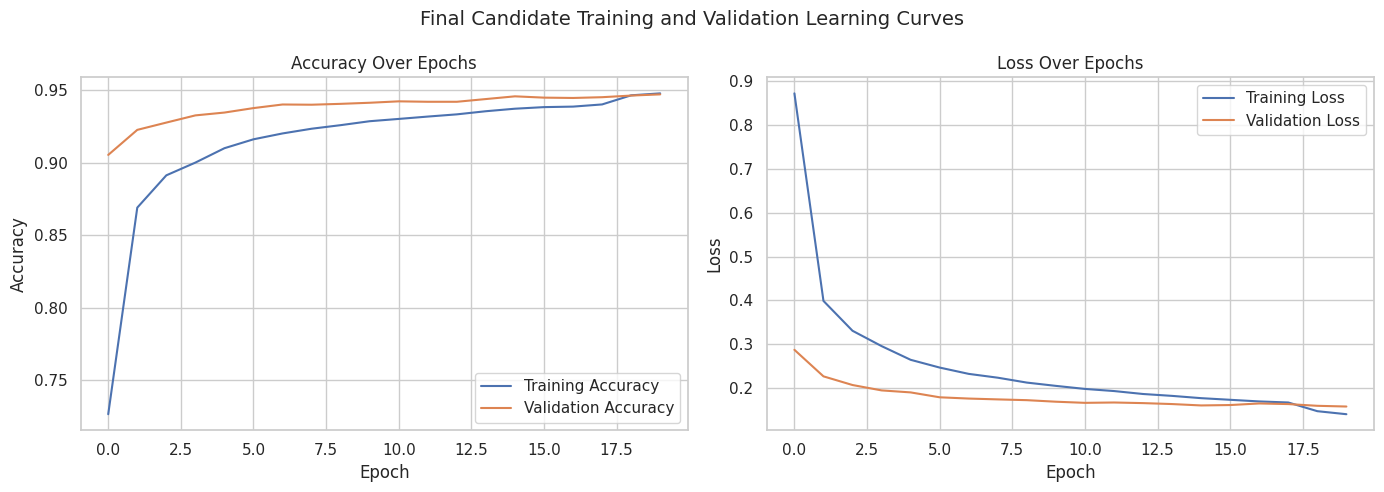

In [82]:
# Final candidate learning curves

plot_learning_curves(
    final_candidate_history,
    title="Final Candidate Training and Validation Learning Curves"
)

The final candidate learning curves show stable improvement across training. Validation accuracy is slightly higher than training accuracy for much of training. This is expected because the final model uses strong dropout regularisation (`dropout = 0.7`). Dropout is active during training, making the training task noisier and harder, but it is disabled during validation, where the full network is used. Therefore, this pattern does not indicate data leakage by itself. The loss curves decrease steadily and remain close near the end of training, suggesting no severe overfitting.

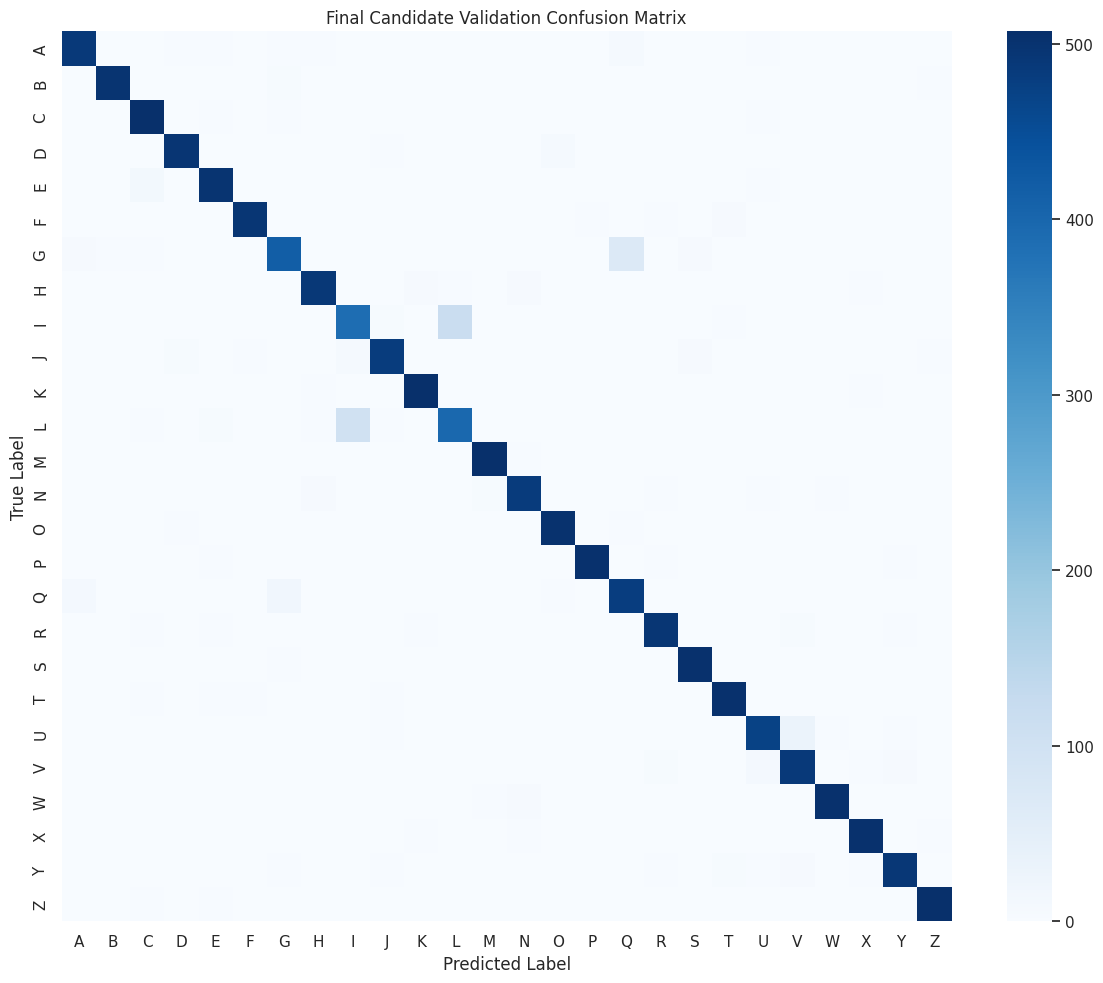

In [83]:
# Final candidate validation confusion matrix

plot_confusion_matrix(
    y_true=y_val,
    y_pred=final_candidate_y_pred,
    class_names=class_name_map,
    title="Final Candidate Validation Confusion Matrix",
    normalize=None
)

In [84]:
# 9.9 Top validation confusion pairs

final_candidate_confusion_pairs = get_top_confusion_pairs(
    y_true=y_val,
    y_pred=final_candidate_y_pred,
    class_names=class_name_map,
    top_n=10
)

final_candidate_confusion_pairs

,true_label,predicted_label,count
53,I,L,118
76,L,I,102
40,G,Q,71
132,U,V,30
105,Q,G,19
25,E,C,12
140,V,U,10
102,Q,A,10
23,D,O,9
60,J,I,8


#### 9.9 Final Candidate Validation Result

The final candidate model was trained using the selected Section 9 settings:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
dropout = 0.7
L2 = None
BatchNorm = False
augmentation = None
Adam learning rate = 0.001
ReduceLROnPlateau patience = 3
```

The best validation-loss weights were saved in the notebook root folder as:

```text
models/final_cnn.weights.h5
```

On the validation set, the final candidate achieved:

```text
validation loss = 0.1581
validation accuracy = 0.9470
validation macro F1 = 0.9470
validation weighted F1 = 0.9469
best epoch = 20
```

The learning curves show stable improvement across training. Validation accuracy is slightly higher than training accuracy for most epochs, which is acceptable in this case because the model uses strong dropout. Dropout is active during training but disabled during validation, so the validation curve is evaluated using the full network while the training curve is measured under a harder regularised setting. The curves do not show severe overfitting.

The classification report shows strong performance for most classes, with many letters achieving F1-scores around `0.96` to `0.99`. However, some visually similar classes remain weaker. The weakest validation F1-scores are mainly for `I`, `L`, `G`, and `Q`, which matches the earlier EDA and baseline error analysis.

The top validation confusion pairs are:

```text
I → L: 118
L → I: 102
G → Q: 71
U → V: 30
Q → G: 19
E → C: 12
V → U: 10
Q → A: 10
D → O: 9
J → I: 8
```

These errors are visually reasonable. `I` and `L` can be extremely similar in handwritten form, while `G/Q`, `U/V`, and `D/O` differ by small stroke details. This confirms that the model's remaining errors are mainly driven by genuine class ambiguity rather than random failure.

Overall, the final candidate is a strong validation model within the predefined controlled search space. It improves substantially over the dense baseline and initial CNN baseline, while maintaining stable validation behaviour. The model is not evaluated on the test set yet; the test set remains untouched until Section 10.

### 9.10 Final Ablation Check

The final candidate combines several selected choices from the controlled Section 9 experiments. This ablation check tests whether the selected final components still help when evaluated together.

Only meaningful ablations are run. Since the final model does not use augmentation, BatchNorm, or L2, those ablations are not needed.

The meaningful ablations are:

```text
Final candidate
Without LR scheduling
Without selected regularisation
With reference dropout 0.3
With reference architecture
```

All ablations use the validation set only. The test set remains untouched.

If the final candidate remains the best or practically best model, it will be locked before Section 10. If an ablated version clearly beats it, the final model will be updated before the test set is used.

In [87]:
# Reset ablation results if this section is rerun

section9_results = [
    result for result in section9_results
    if result["experiment_group"] != "Final ablation"
]

# Add final candidate as the ablation reference row

sec9_add_result(
    experiment_group="Final ablation",
    experiment=final_model_name,
    hypothesis="The final selected combination should remain strong against meaningful ablations.",
    controlled_change="Final candidate: selected settings combined",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
        "L2=None, BatchNorm=False, augmentation=None, "
        f"Adam lr={selected_learning_rate}, ReduceLROnPlateau patience={selected_reduce_lr_patience}"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    best_epoch=final_candidate_best_epoch,
    metrics=final_candidate_metrics,
    overfitting_observation=final_candidate_overfitting_observation,
    checkpoint_path=final_checkpoint_path,
    decision="Reference final candidate"
)

print("Final candidate added to ablation comparison.")

Final candidate added to ablation comparison.


In [88]:
# Reuse no-LR-scheduling result from fixed lr=0.001 comparison

no_lr_scheduler_experiment = "deeper_cnn_fixed_lr_0_001_reused_from_9_7"

no_lr_scheduler_result = lr_comparison[
    lr_comparison["experiment"] == no_lr_scheduler_experiment
].iloc[0]

no_lr_scheduler_metrics = {
    "val_loss": no_lr_scheduler_result["val_loss"],
    "val_accuracy": no_lr_scheduler_result["val_accuracy"],
    "val_macro_f1": no_lr_scheduler_result["val_macro_f1"],
    "val_weighted_f1": no_lr_scheduler_result["val_weighted_f1"]
}

sec9_add_result(
    experiment_group="Final ablation",
    experiment="ablation_without_lr_scheduler",
    hypothesis="Removing LR scheduling tests whether ReduceLROnPlateau improved the final candidate.",
    controlled_change="Remove ReduceLROnPlateau; use fixed Adam lr=0.001",
    fixed_settings=(
        f"architecture={selected_architecture_name}, batch_size={selected_batch_size}, "
        f"max_epochs={selected_max_epochs}, dropout={selected_dropout_rate}, "
        "L2=None, BatchNorm=False, augmentation=None"
    ),
    max_epochs=selected_max_epochs,
    batch_size=selected_batch_size,
    best_epoch=no_lr_scheduler_result["best_epoch"],
    metrics=no_lr_scheduler_metrics,
    overfitting_observation=no_lr_scheduler_result["overfitting_observation"],
    checkpoint_path=no_lr_scheduler_result["checkpoint_path"],
    decision="Pending"
)

print("No-LR-scheduler ablation reused from 9.8 fixed lr=0.001 result.")

No-LR-scheduler ablation reused from 9.8 fixed lr=0.001 result.


In [89]:
# 9.10 Ablation training helper

def train_final_ablation(build_model_fn, experiment_name, controlled_change, checkpoint_path):
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_model_fn()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=selected_learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=selected_reduce_lr_patience,
        min_lr=1e-5,
        verbose=1
    )

    history = model.fit(
        X_train_images,
        y_train,
        validation_data=(X_val_images, y_val),
        epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        callbacks=[checkpoint, reduce_lr],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    metrics = sec9_evaluate_model(model, X_val_images, y_val)
    best_epoch = sec9_best_epoch(history)
    overfitting_observation = sec9_overfitting_observation(history)

    sec9_add_result(
        experiment_group="Final ablation",
        experiment=experiment_name,
        hypothesis="Ablation tests whether a selected final component is still useful in the combined final model.",
        controlled_change=controlled_change,
        fixed_settings=(
            f"batch_size={selected_batch_size}, max_epochs={selected_max_epochs}, "
            f"Adam lr={selected_learning_rate}, ReduceLROnPlateau patience={selected_reduce_lr_patience}, "
            "BatchNorm=False, augmentation=None"
        ),
        max_epochs=selected_max_epochs,
        batch_size=selected_batch_size,
        best_epoch=best_epoch,
        metrics=metrics,
        overfitting_observation=overfitting_observation,
        checkpoint_path=checkpoint_path,
        decision="Pending"
    )

    print(f"Experiment: {experiment_name}")
    print(f"Best epoch: {best_epoch}")
    print(f"Validation loss: {metrics['val_loss']:.4f}")
    print(f"Validation accuracy: {metrics['val_accuracy']:.4f}")
    print(f"Validation macro F1: {metrics['val_macro_f1']:.4f}")
    print(f"Validation weighted F1: {metrics['val_weighted_f1']:.4f}")
    print(overfitting_observation)

    return model, history, metrics

In [90]:
# Train meaningful ablations

# Ablation 1: remove selected regularisation
def build_ablation_no_regularisation():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=0.0,
        l2_rate=None,
        use_batchnorm=False,
        augmentation_layer=None
    )

ablation_no_reg_model, ablation_no_reg_history, ablation_no_reg_metrics = train_final_ablation(
    build_model_fn=build_ablation_no_regularisation,
    experiment_name="ablation_without_selected_regularisation",
    controlled_change="Remove selected dropout regularisation: dropout=0.0",
    checkpoint_path="checkpoints/sec9_10_ablation_without_selected_regularisation.weights.h5"
)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8229 - loss: 0.5673 - val_accuracy: 0.9081 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9180 - loss: 0.2440 - val_accuracy: 0.9219 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9342 - loss: 0.1915 - val_accuracy: 0.9296 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9432 - loss: 0.1610 - val_accuracy: 0.9299 - val_loss: 0.2124 - learning_rate: 0.0010
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9496 - loss: 0.1388 - val_accuracy: 0.9288 - val_loss: 0.2209 - learning_rate: 0.0010
Epoch 6/20
971/972 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9550 - loss: 0.1206
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9549 - loss: 0.1207 

In [91]:
# Ablation 2: use reference dropout 0.3 instead of selected dropout 0.7

def build_ablation_reference_dropout():
    return build_sec9_cnn(
        architecture_key=selected_architecture_key,
        dropout_rate=0.3,
        l2_rate=None,
        use_batchnorm=False,
        augmentation_layer=None
    )

ablation_reference_dropout_model, ablation_reference_dropout_history, ablation_reference_dropout_metrics = train_final_ablation(
    build_model_fn=build_ablation_reference_dropout,
    experiment_name="ablation_reference_dropout_0_3",
    controlled_change="Use reference dropout=0.3 instead of selected dropout=0.7",
    checkpoint_path="checkpoints/sec9_10_ablation_reference_dropout_0_3.weights.h5"
)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8005 - loss: 0.6406 - val_accuracy: 0.9062 - val_loss: 0.2862 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9057 - loss: 0.2823 - val_accuracy: 0.9240 - val_loss: 0.2220 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9228 - loss: 0.2272 - val_accuracy: 0.9286 - val_loss: 0.2091 - learning_rate: 0.0010
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9307 - loss: 0.2000 - val_accuracy: 0.9330 - val_loss: 0.1882 - learning_rate: 0.0010
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9362 - loss: 0.1792 - val_accuracy: 0.9336 - val_loss: 0.1909 - learning_rate: 0.0010
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9411 - loss: 0.1634 - val_accuracy: 0.9342 - val_loss: 0.1961 - learning_rate: 0.0010
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9443 - loss: 0.1493 -

In [92]:
# Ablation 3: use reference architecture instead of selected deeper architecture

def build_ablation_reference_architecture():
    return build_sec9_cnn(
        architecture_key="reference",
        dropout_rate=selected_dropout_rate,
        l2_rate=None,
        use_batchnorm=False,
        augmentation_layer=None
    )

ablation_reference_arch_model, ablation_reference_arch_history, ablation_reference_arch_metrics = train_final_ablation(
    build_model_fn=build_ablation_reference_architecture,
    experiment_name="ablation_reference_architecture",
    controlled_change="Use reference CNN architecture instead of selected Deeper CNN",
    checkpoint_path="checkpoints/sec9_10_ablation_reference_architecture.weights.h5"
)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7442 - loss: 0.8288 - val_accuracy: 0.8910 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8654 - loss: 0.4150 - val_accuracy: 0.9110 - val_loss: 0.2691 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8858 - loss: 0.3440 - val_accuracy: 0.9201 - val_loss: 0.2434 - learning_rate: 0.0010
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8977 - loss: 0.3038 - val_accuracy: 0.9228 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9069 - loss: 0.2773 - val_accuracy: 0.9295 - val_loss: 0.2100 - learning_rate: 0.0010
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9111 - loss: 0.2586 - val_accuracy: 0.9303 - val_loss: 0.2067 - learning_rate: 0.0010
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9154 - loss: 0.2462 -

In [93]:
# 9.10 Final ablation comparison table

ablation_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Final ablation'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

ablation_comparison

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Final ablation,final_candidate_deeper_dropout_0_7_reduce_lr_p3,The final selected combination should remain s...,Final candidate: selected settings combined,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.158081,0.946997,0.946896,0.946886,No severe overfitting: training and validation...,models/final_cnn.weights.h5,Reference final candidate
1,Final ablation,ablation_without_lr_scheduler,Removing LR scheduling tests whether ReduceLRO...,Remove ReduceLROnPlateau; use fixed Adam lr=0.001,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Pending
2,Final ablation,ablation_reference_architecture,Ablation tests whether a selected final compon...,Use reference CNN architecture instead of sele...,"batch_size=64, max_epochs=20, Adam lr=0.001, R...",20,64,20,0.175536,0.941667,0.941614,0.941613,No severe overfitting: training and validation...,checkpoints/sec9_10_ablation_reference_archite...,Pending
3,Final ablation,ablation_reference_dropout_0_3,Ablation tests whether a selected final compon...,Use reference dropout=0.3 instead of selected ...,"batch_size=64, max_epochs=20, Adam lr=0.001, R...",20,64,8,0.181523,0.937237,0.937130,0.937124,Mild overfitting: validation performance trail...,checkpoints/sec9_10_ablation_reference_dropout...,Pending
4,Final ablation,ablation_without_selected_regularisation,Ablation tests whether a selected final compon...,Remove selected dropout regularisation: dropou...,"batch_size=64, max_epochs=20, Adam lr=0.001, R...",20,64,7,0.210600,0.935511,0.935471,0.935475,Clear overfitting: training performance is muc...,checkpoints/sec9_10_ablation_without_selected_...,Pending


In [94]:
# 9.10 Lock final model after ablation check

final_model_locked = True
final_model_name = "final_candidate_deeper_dropout_0_7_reduce_lr_p3"
final_checkpoint_path = PROJECT_ROOT / \"models/final_cnn.weights.h5\"

for result in section9_results:
    if result["experiment_group"] == "Final ablation":
        if result["experiment"] == final_model_name:
            result["decision"] = "Locked: final candidate achieved the best validation macro F1 among meaningful ablations."
        else:
            result["decision"] = "Rejected: ablation reduced validation macro F1 compared with the final candidate."

ablation_comparison = (
    sec9_results_df()
    .query("experiment_group == 'Final ablation'")
    .sort_values(
        by=["val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

print("Final model locked:", final_model_locked)
print("Final model name:", final_model_name)
print("Final checkpoint path:", final_checkpoint_path)
print("No further tuning before test evaluation.")

ablation_comparison

Final model locked: True
Final model name: final_candidate_deeper_dropout_0_7_reduce_lr_p3
Final checkpoint path: models/final_cnn.weights.h5
No further tuning before test evaluation.


,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Final ablation,final_candidate_deeper_dropout_0_7_reduce_lr_p3,The final selected combination should remain s...,Final candidate: selected settings combined,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.158081,0.946997,0.946896,0.946886,No severe overfitting: training and validation...,models/final_cnn.weights.h5,Locked: final candidate achieved the best vali...
1,Final ablation,ablation_without_lr_scheduler,Removing LR scheduling tests whether ReduceLRO...,Remove ReduceLROnPlateau; use fixed Adam lr=0.001,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Rejected: ablation reduced validation macro F1...
2,Final ablation,ablation_reference_architecture,Ablation tests whether a selected final compon...,Use reference CNN architecture instead of sele...,"batch_size=64, max_epochs=20, Adam lr=0.001, R...",20,64,20,0.175536,0.941667,0.941614,0.941613,No severe overfitting: training and validation...,checkpoints/sec9_10_ablation_reference_archite...,Rejected: ablation reduced validation macro F1...
3,Final ablation,ablation_reference_dropout_0_3,Ablation tests whether a selected final compon...,Use reference dropout=0.3 instead of selected ...,"batch_size=64, max_epochs=20, Adam lr=0.001, R...",20,64,8,0.181523,0.937237,0.937130,0.937124,Mild overfitting: validation performance trail...,checkpoints/sec9_10_ablation_reference_dropout...,Rejected: ablation reduced validation macro F1...
4,Final ablation,ablation_without_selected_regularisation,Ablation tests whether a selected final compon...,Remove selected dropout regularisation: dropou...,"batch_size=64, max_epochs=20, Adam lr=0.001, R...",20,64,7,0.210600,0.935511,0.935471,0.935475,Clear overfitting: training performance is muc...,checkpoints/sec9_10_ablation_without_selected_...,Rejected: ablation reduced validation macro F1...


#### 9.10 Final Ablation Result

The final candidate is **locked**.

The final candidate achieved the strongest validation macro F1 among the meaningful ablation checks:

```text
Final candidate:
validation loss = 0.1581
validation accuracy = 0.9470
validation macro F1 = 0.9469
validation weighted F1 = 0.9469

Without LR scheduler:
validation macro F1 = 0.9456

Reference architecture:
validation macro F1 = 0.9416

Reference dropout 0.3:
validation macro F1 = 0.9371

Without selected regularisation:
validation macro F1 = 0.9355
```

This confirms that the selected final combination is stronger than removing or reverting the main selected components. Removing the learning-rate scheduler slightly reduced validation macro F1, showing that `ReduceLROnPlateau` still helped in the combined model. Reverting to the reference architecture also reduced performance, supporting the selected Deeper CNN. Replacing dropout `0.7` with the reference dropout `0.3`, or removing dropout entirely, reduced validation macro F1 further, confirming that the selected regularisation setting remains important.

The ablation check therefore supports the final model decision. The final selected model is:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
dropout = 0.7
L2 = None
BatchNorm = False
augmentation = None
optimizer = Adam
initial learning rate = 0.001
scheduler = ReduceLROnPlateau
scheduler patience = 3
```

The final candidate weights are saved as:

```text
models/final_cnn.weights.h5
```

After this point, no further model tuning is performed. The test set remains untouched until Section 10.

### 9.11 Final Experiment Results and Decision

This section summarises the controlled Section 9 experiment trail and records the final selected settings.

All model-selection decisions in Section 9 used the validation set only. The test set has not been used for model selection, tuning, or reporting.

The final model is locked after the ablation check. After this point, no further model tuning is performed before Section 10.

In [95]:
# Full Section 9 experiment results

experiment_results_df = sec9_results_df().copy()

experiment_results_df = experiment_results_df.sort_values(
    by=["experiment_group", "val_macro_f1", "val_loss", "val_accuracy"],
    ascending=[True, False, True, False]
).reset_index(drop=True)

experiment_results_df

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Augmentation,deeper_cnn_no_augmentation_reused_from_9_6,Augmentation may improve generalisation by sim...,augmentation=None,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Selected: highest validation macro F1 and lowe...
1,Augmentation,deeper_cnn_conservative_augmentation,Conservative augmentation may improve generali...,"conservative augmentation: rotation=0.04, tran...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.170851,0.941967,0.941814,0.941808,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_conservative_aug...,Rejected: augmentation reduced validation macr...
2,Augmentation,deeper_cnn_strong_augmentation,Strong augmentation may improve robustness but...,"strong augmentation: rotation=0.12, translatio...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,14,0.255146,0.914790,0.914911,0.914901,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_strong_augmentat...,Rejected: augmentation reduced validation macr...
3,BatchNorm,deeper_cnn_no_batchnorm_reused_from_9_5,BatchNorm may improve optimisation or training...,use_batchnorm=False,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Selected: higher validation macro F1 than Batc...
4,BatchNorm,deeper_cnn_with_batchnorm,BatchNorm may improve optimisation or training...,use_batchnorm=True,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.157824,0.942943,0.942807,0.942798,No severe overfitting: training and validation...,checkpoints/sec9_6_deeper_cnn_with_batchnorm.w...,Rejected: BatchNorm reduced validation macro F...
5,CNN capacity,deeper_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,8,0.184183,0.937012,0.936899,0.936901,No severe overfitting: training and validation...,checkpoints/sec9_4_deeper_cnn.weights.h5,"Selected: best validation macro F1, lowest val..."
6,CNN capacity,deeper_no_pool_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper-no-pool CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.203505,0.931381,0.930975,0.930986,Mild overfitting: validation performance trail...,checkpoints/sec9_4_deeper_no_pool_cnn.weights.h5,Rejected: weaker validation performance than s...
7,CNN capacity,reference_cnn,Changing CNN width or depth may improve learne...,architecture=Reference CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,5,0.219253,0.929129,0.929296,0.929303,Mild overfitting: validation performance trail...,checkpoints/sec9_4_reference_cnn.weights.h5,Rejected: weaker validation performance than s...
8,CNN capacity,wider_cnn,Changing CNN width or depth may improve learne...,architecture=Wider CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.220382,0.927853,0.927888,0.927886,Mild overfitting: validation performance trail...,checkpoints/sec9_4_wider_cnn.weights.h5,Rejected: weaker validation performance than s...
9,CNN capacity,shallow_cnn,Changing CNN width or depth may improve learne...,architecture=Shallow CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,6,0.270235,0.913288,0.913542,0.913549,Mild overfitting: validation performance trail...,checkpoints/sec9_4_shallow_cnn.weights.h5,Rejected: weaker validation performance than s...


In [96]:
# Selected settings summary

selected_settings_summary = pd.DataFrame([
    {
        "setting": "Training protocol",
        "selected_value": f"batch_size={selected_batch_size}, max_epochs={selected_max_epochs}",
        "evidence": "Selected from 9.3 training protocol grid using validation macro F1."
    },
    {
        "setting": "Architecture",
        "selected_value": selected_architecture_name,
        "evidence": "Selected from 9.4 capacity comparison."
    },
    {
        "setting": "Regularisation",
        "selected_value": f"dropout-only, dropout={selected_dropout_rate}, L2={selected_l2_rate}",
        "evidence": "Selected from 9.5 dropout/L2 comparison."
    },
    {
        "setting": "BatchNorm",
        "selected_value": str(selected_batchnorm_setting),
        "evidence": "Selected from 9.6 BatchNorm comparison."
    },
    {
        "setting": "Augmentation",
        "selected_value": selected_augmentation_policy,
        "evidence": "Selected from 9.7 augmentation comparison."
    },
    {
        "setting": "Learning-rate strategy",
        "selected_value": (
            f"{selected_lr_strategy}, initial_lr={selected_learning_rate}, "
            f"patience={selected_reduce_lr_patience}"
        ),
        "evidence": "Selected from 9.8 learning-rate strategy comparison."
    },
    {
        "setting": "Final model",
        "selected_value": final_model_name,
        "evidence": "Locked after 9.10 final ablation check."
    },
    {
        "setting": "Final checkpoint",
        "selected_value": final_checkpoint_path,
        "evidence": "Saved in notebook root folder for final submission."
    }
])

selected_settings_summary

,setting,selected_value,evidence
0,Training protocol,"batch_size=64, max_epochs=20",Selected from 9.3 training protocol grid using...
1,Architecture,Deeper CNN,Selected from 9.4 capacity comparison.
2,Regularisation,"dropout-only, dropout=0.7, L2=None",Selected from 9.5 dropout/L2 comparison.
3,BatchNorm,False,Selected from 9.6 BatchNorm comparison.
4,Augmentation,none,Selected from 9.7 augmentation comparison.
5,Learning-rate strategy,"reduce_lr_on_plateau, initial_lr=0.001, patien...",Selected from 9.8 learning-rate strategy compa...
6,Final model,final_candidate_deeper_dropout_0_7_reduce_lr_p3,Locked after 9.10 final ablation check.
7,Final checkpoint,models/final_cnn.weights.h5,Saved in notebook root folder for final submis...


In [97]:
# Best row per experiment group

summary_groups = [
    "Training protocol",
    "CNN capacity",
    "Regularisation",
    "BatchNorm",
    "Augmentation",
    "Learning rate",
    "Final ablation"
]

best_per_experiment_group_summary = (
    experiment_results_df[experiment_results_df["experiment_group"].isin(summary_groups)]
    .sort_values(
        by=["experiment_group", "val_macro_f1", "val_loss", "val_accuracy"],
        ascending=[True, False, True, False]
    )
    .groupby("experiment_group", as_index=False)
    .first()
)

best_per_experiment_group_summary = best_per_experiment_group_summary[
    [
        "experiment_group",
        "experiment",
        "controlled_change",
        "best_epoch",
        "val_loss",
        "val_accuracy",
        "val_macro_f1",
        "val_weighted_f1",
        "decision"
    ]
]

best_per_experiment_group_summary

,experiment_group,experiment,controlled_change,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,decision
0,Augmentation,deeper_cnn_no_augmentation_reused_from_9_6,augmentation=None,18,0.162754,0.945646,0.945563,0.945557,Selected: highest validation macro F1 and lowe...
1,BatchNorm,deeper_cnn_no_batchnorm_reused_from_9_5,use_batchnorm=False,18,0.162754,0.945646,0.945563,0.945557,Selected: higher validation macro F1 than Batc...
2,CNN capacity,deeper_cnn,architecture=Deeper CNN,8,0.184183,0.937012,0.936899,0.936901,"Selected: best validation macro F1, lowest val..."
3,Final ablation,final_candidate_deeper_dropout_0_7_reduce_lr_p3,Final candidate: selected settings combined,20,0.158081,0.946997,0.946896,0.946886,Locked: final candidate achieved the best vali...
4,Learning rate,deeper_cnn_reduce_lr_patience_3,Adam lr=0.001 with ReduceLROnPlateau patience=3,19,0.155382,0.947598,0.947546,0.947537,Selected: highest validation macro F1 among le...
5,Regularisation,deeper_cnn_dropout_0_7,"dropout=0.7, no L2",18,0.162754,0.945646,0.945563,0.945557,Selected: highest validation macro F1 among re...
6,Training protocol,reference_cnn_bs64_ep20,"batch_size=64, max_epochs=20",7,0.217911,0.930180,0.930096,0.930093,Pending


In [98]:
# 9.11 Final locked model details

print("Final model locked:", final_model_locked)
print("Final model name:", final_model_name)
print("Final checkpoint path:", final_checkpoint_path)
print("Test set used for model selection:", False)
print("Further tuning allowed before Section 10:", False)

final_locked_summary = pd.DataFrame([{
    "final_model_name": final_model_name,
    "final_checkpoint_path": final_checkpoint_path,
    "best_epoch": final_candidate_best_epoch,
    "val_loss": final_candidate_val_loss,
    "val_accuracy": final_candidate_val_accuracy,
    "val_macro_f1": final_candidate_val_macro_f1,
    "val_weighted_f1": final_candidate_val_weighted_f1,
    "overfitting_observation": final_candidate_overfitting_observation
}])

final_locked_summary

Final model locked: True
Final model name: final_candidate_deeper_dropout_0_7_reduce_lr_p3
Final checkpoint path: models/final_cnn.weights.h5
Test set used for model selection: False
Further tuning allowed before Section 10: False


,final_model_name,final_checkpoint_path,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation
0,final_candidate_deeper_dropout_0_7_reduce_lr_p3,models/final_cnn.weights.h5,20,0.158081,0.946997,0.946896,0.946886,No severe overfitting: training and validation...


In [99]:
# Clean up remaining pending decisions after final model lock

selected_training_protocol_experiment = "reference_cnn_bs64_ep20"

for result in section9_results:
    if result["experiment_group"] == "Training protocol":
        if result["experiment"] == selected_training_protocol_experiment:
            result["decision"] = "Selected: highest validation macro F1 in the training protocol grid."
        else:
            result["decision"] = "Rejected: weaker validation macro F1 than selected training protocol."

    if result["experiment_group"] == "Final candidate":
        if result["experiment"] == final_model_name:
            result["decision"] = "Locked after final ablation check."

In [100]:
experiment_results_df = sec9_results_df().copy()

experiment_results_df = experiment_results_df.sort_values(
    by=["experiment_group", "val_macro_f1", "val_loss", "val_accuracy"],
    ascending=[True, False, True, False]
).reset_index(drop=True)

experiment_results_df

,experiment_group,experiment,hypothesis,controlled_change,fixed_settings,max_epochs,batch_size,best_epoch,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,overfitting_observation,checkpoint_path,decision
0,Augmentation,deeper_cnn_no_augmentation_reused_from_9_6,Augmentation may improve generalisation by sim...,augmentation=None,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Selected: highest validation macro F1 and lowe...
1,Augmentation,deeper_cnn_conservative_augmentation,Conservative augmentation may improve generali...,"conservative augmentation: rotation=0.04, tran...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.170851,0.941967,0.941814,0.941808,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_conservative_aug...,Rejected: augmentation reduced validation macr...
2,Augmentation,deeper_cnn_strong_augmentation,Strong augmentation may improve robustness but...,"strong augmentation: rotation=0.12, translatio...","architecture=Deeper CNN, batch_size=64, max_ep...",20,64,14,0.255146,0.914790,0.914911,0.914901,No severe overfitting: training and validation...,checkpoints/sec9_7_deeper_cnn_strong_augmentat...,Rejected: augmentation reduced validation macr...
3,BatchNorm,deeper_cnn_no_batchnorm_reused_from_9_5,BatchNorm may improve optimisation or training...,use_batchnorm=False,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,18,0.162754,0.945646,0.945563,0.945557,No severe overfitting: training and validation...,checkpoints/sec9_5_deeper_cnn_dropout_0_7.weig...,Selected: higher validation macro F1 than Batc...
4,BatchNorm,deeper_cnn_with_batchnorm,BatchNorm may improve optimisation or training...,use_batchnorm=True,"architecture=Deeper CNN, batch_size=64, max_ep...",20,64,20,0.157824,0.942943,0.942807,0.942798,No severe overfitting: training and validation...,checkpoints/sec9_6_deeper_cnn_with_batchnorm.w...,Rejected: BatchNorm reduced validation macro F...
5,CNN capacity,deeper_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,8,0.184183,0.937012,0.936899,0.936901,No severe overfitting: training and validation...,checkpoints/sec9_4_deeper_cnn.weights.h5,"Selected: best validation macro F1, lowest val..."
6,CNN capacity,deeper_no_pool_cnn,Changing CNN width or depth may improve learne...,architecture=Deeper-no-pool CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.203505,0.931381,0.930975,0.930986,Mild overfitting: validation performance trail...,checkpoints/sec9_4_deeper_no_pool_cnn.weights.h5,Rejected: weaker validation performance than s...
7,CNN capacity,reference_cnn,Changing CNN width or depth may improve learne...,architecture=Reference CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,5,0.219253,0.929129,0.929296,0.929303,Mild overfitting: validation performance trail...,checkpoints/sec9_4_reference_cnn.weights.h5,Rejected: weaker validation performance than s...
8,CNN capacity,wider_cnn,Changing CNN width or depth may improve learne...,architecture=Wider CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,4,0.220382,0.927853,0.927888,0.927886,Mild overfitting: validation performance trail...,checkpoints/sec9_4_wider_cnn.weights.h5,Rejected: weaker validation performance than s...
9,CNN capacity,shallow_cnn,Changing CNN width or depth may improve learne...,architecture=Shallow CNN,"batch_size=64, max_epochs=20, dropout=0.3, no ...",20,64,6,0.270235,0.913288,0.913542,0.913549,Mild overfitting: validation performance trail...,checkpoints/sec9_4_shallow_cnn.weights.h5,Rejected: weaker validation performance than s...


#### 9.11 Section 9 Summary and Final Decision

Section 9 used a controlled validation-based experiment trail to improve the CNN baseline.

The selected settings are:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
dropout = 0.7
L2 = None
BatchNorm = False
augmentation = None
optimizer = Adam
initial learning rate = 0.001
scheduler = ReduceLROnPlateau
scheduler patience = 3
```

The training protocol comparison selected `batch_size = 64` and `max_epochs = 20` because it achieved the strongest validation macro F1 in the predefined batch-size/epoch grid.

The capacity comparison selected the Deeper CNN because it outperformed the shallow, reference, wider, and deeper-no-pool candidates. This showed that adding a third convolutional block helped the model learn stronger stroke representations.

The regularisation comparison selected dropout-only regularisation with `dropout = 0.7`. This gave the strongest validation macro F1 among the no-regularisation, dropout-only, L2-only, and combined dropout+L2 candidates. L2 was not carried forward because it did not improve validation macro F1.

BatchNorm was not selected because it reduced validation macro F1 compared with the no-BatchNorm model. Augmentation was also not selected because both conservative and strong augmentation reduced validation performance. This is still a useful finding because augmentation was investigated rather than assumed to be beneficial.

The learning-rate comparison selected Adam with `ReduceLROnPlateau` using patience `3`. This improved validation macro F1 compared with the fixed learning-rate baselines and other scheduler patience values.

The final candidate was then trained using the selected settings and saved as:

```text
models/final_cnn.weights.h5
```

The final ablation check confirmed that the selected combination should be locked. Removing the learning-rate scheduler, reverting to the reference architecture, using reference dropout `0.3`, or removing selected regularisation all reduced validation macro F1 compared with the final candidate.

This closes the EDA-to-modelling loop:

- CNNs were used because the 28×28 images contain local stroke structure that should be preserved before flattening.
- Architecture depth was tested because visually similar handwritten letters may require richer stroke representations.
- Augmentation was tested because EDA showed centred strokes and dark borders, making conservative transformations plausible but stronger transformations risky.
- Confusion-pair analysis was kept because baseline results showed persistent errors between visually similar letters such as `I/L`, `G/Q`, `O/Q`, `U/V`, and `M/N`.

The selected setting is the best-performing candidate within the predefined controlled search space. It should not be described as a globally optimal model.

After this point, the model is locked. The test set remains untouched and will only be used once in Section 10 for final evaluation.



---



## 10. Final Test Evaluation

The final model was locked at the end of Section 9 after validation-based controlled experiments and the final ablation check.

This section evaluates the locked model on the test set once.

The test set was not used for model selection, hyperparameter tuning, architecture selection, regularisation selection, augmentation selection, learning-rate selection, or ablation decisions.

After viewing the test results, no further model tuning is performed.

In [101]:
# 10.1 Load locked final model weights

assert final_model_locked == True, "Final model must be locked before test evaluation."
assert os.path.exists(final_checkpoint_path), f"Missing final weights file: {final_checkpoint_path}"

class_name_map = {i: class_names[i] for i in range(len(class_names))}

final_test_model = build_final_candidate_model()

final_test_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=selected_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_test_model.load_weights(final_checkpoint_path)

print("Loaded locked final model weights from:", final_checkpoint_path)
print("Model tuning after this point:", False)

Loaded locked final model weights from: models/final_cnn.weights.h5
Model tuning after this point: False


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [102]:
# 10.2 Final test evaluation

final_test_loss, final_test_accuracy_from_evaluate = final_test_model.evaluate(
    X_test_images,
    y_test,
    verbose=0
)

final_test_eval = evaluate_classification_model(
    model=final_test_model,
    X=X_test_images,
    y_true=y_test,
    class_names=class_name_map,
    dataset_name="Final Test"
)

final_test_y_pred = final_test_eval["y_pred"]
final_test_y_proba = final_test_eval["y_proba"]

final_test_accuracy = final_test_eval["accuracy"]
final_test_macro_f1 = final_test_eval["macro_f1"]
final_test_weighted_f1 = final_test_eval["weighted_f1"]

final_test_summary = pd.DataFrame([{
    "model_name": final_model_name,
    "weights_file": final_checkpoint_path,
    "test_loss": final_test_loss,
    "test_accuracy": final_test_accuracy,
    "test_macro_f1": final_test_macro_f1,
    "test_weighted_f1": final_test_weighted_f1
}])

final_test_summary

Final Test Accuracy: 0.9495
Final Test Macro F1: 0.9494
Final Test Weighted F1: 0.9494

Classification Report:
              precision    recall  f1-score   support

           A       0.94      0.94      0.94       509
           B       1.00      0.98      0.99       509
           C       0.98      0.99      0.98       513
           D       0.96      0.96      0.96       509
           E       0.98      0.97      0.98       516
           F       0.99      0.97      0.98       509
           G       0.92      0.83      0.87       508
           H       0.97      0.97      0.97       514
           I       0.76      0.74      0.75       514
           J       0.96      0.94      0.95       510
           K       0.98      0.97      0.98       515
           L       0.75      0.78      0.76       512
           M       0.99      0.99      0.99       511
           N       0.96      0.98      0.97       505
           O       0.96      0.99      0.97       511
           P       0.98 

,model_name,weights_file,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,final_candidate_deeper_dropout_0_7_reduce_lr_p3,models/final_cnn.weights.h5,0.144987,0.949474,0.949399,0.949401


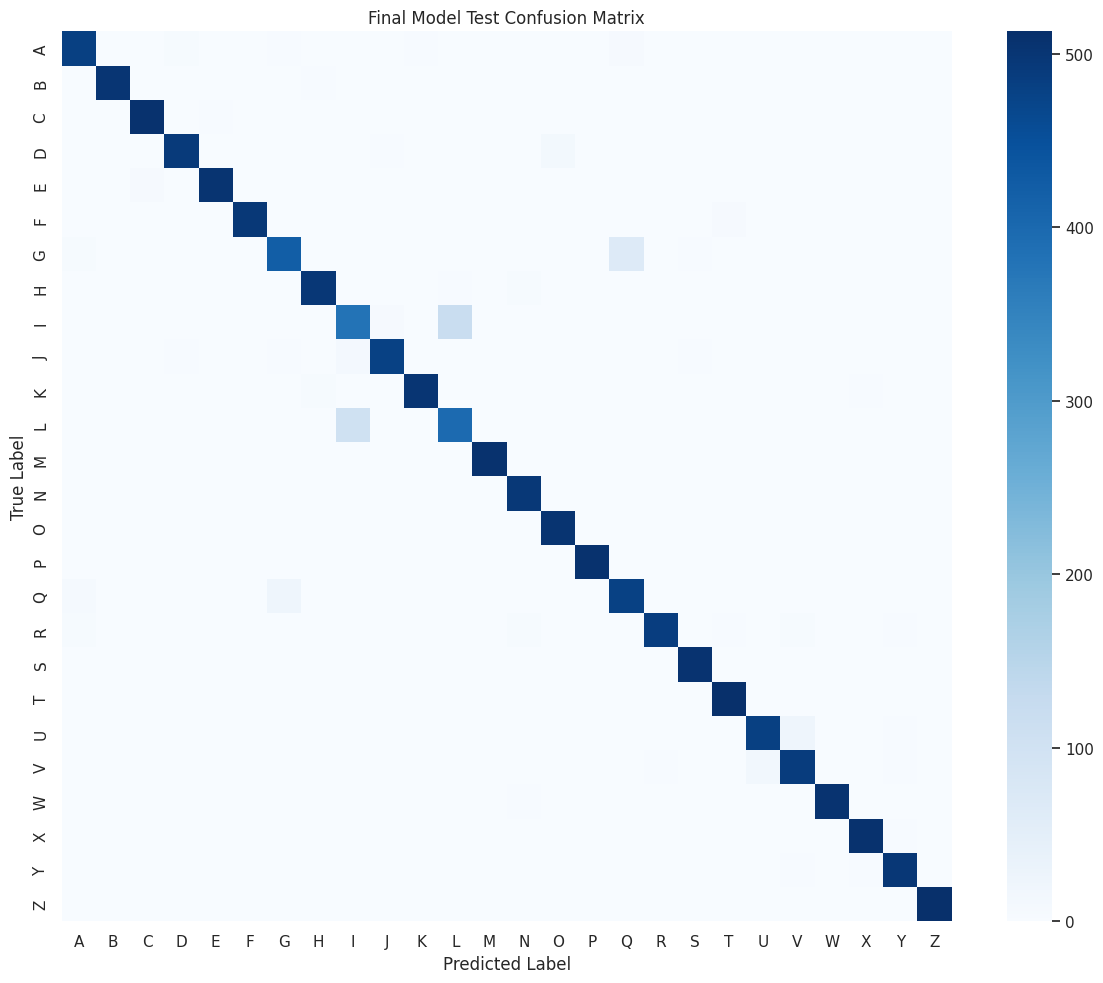

In [103]:
# 10.3 Final test confusion matrix

plot_confusion_matrix(
    y_true=y_test,
    y_pred=final_test_y_pred,
    class_names=class_name_map,
    title="Final Model Test Confusion Matrix",
    normalize=None
)

In [104]:
# 10.4 Top test confusion pairs

final_test_confusion_pairs = get_top_confusion_pairs(
    y_true=y_test,
    y_pred=final_test_y_pred,
    class_names=class_name_map,
    top_n=10
)

final_test_confusion_pairs

,true_label,predicted_label,count
54,I,L,122
77,L,I,106
40,G,Q,67
101,Q,G,24
121,U,V,23
126,V,U,18
21,D,O,13
59,J,I,12
100,Q,A,10
23,E,C,8


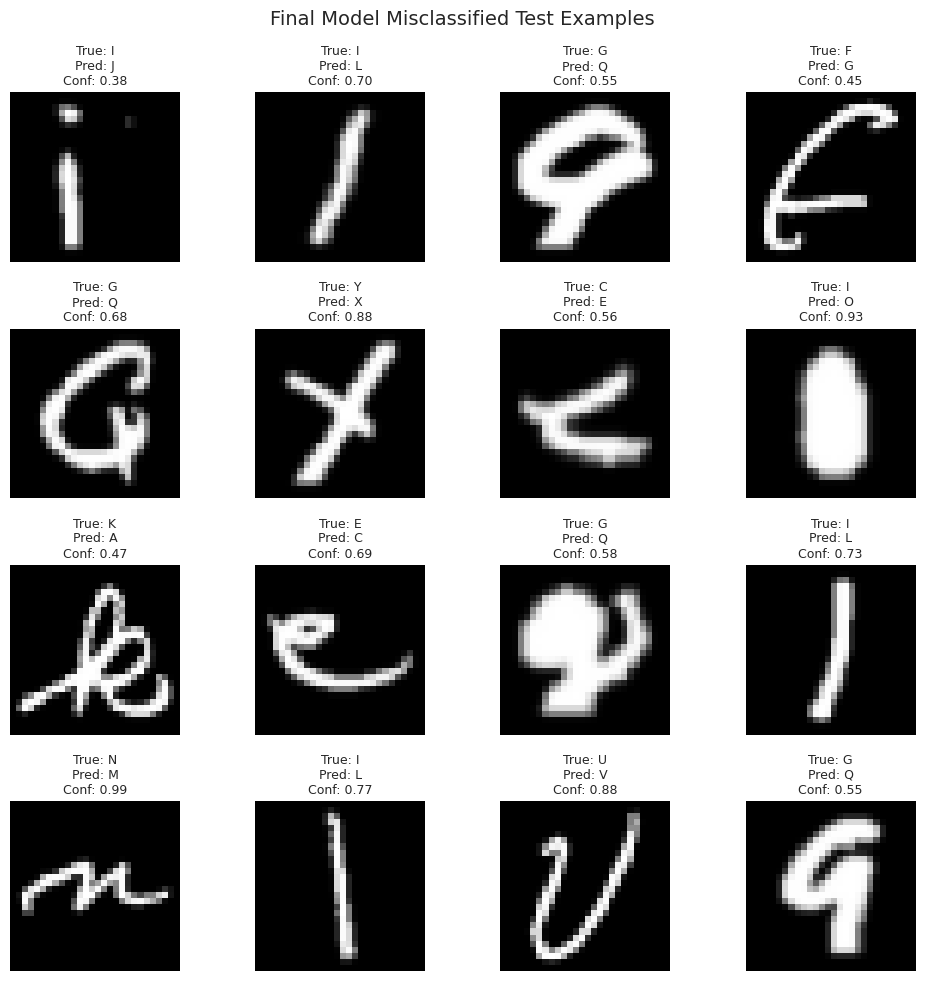

In [105]:
# 10.5 Misclassified test examples

show_misclassified_examples(
    model=final_test_model,
    X=X_test_images,
    y_true=y_test,
    class_names=class_name_map,
    n=16,
    title="Final Model Misclassified Test Examples"
)

In [106]:
# 10.6 Confidence analysis

test_confidence = np.max(final_test_y_proba, axis=1)
test_correct = labels_to_1d(y_test) == final_test_y_pred

confidence_summary = pd.DataFrame([{
    "mean_confidence_all": test_confidence.mean(),
    "mean_confidence_correct": test_confidence[test_correct].mean(),
    "mean_confidence_incorrect": test_confidence[~test_correct].mean(),
    "median_confidence_all": np.median(test_confidence),
    "median_confidence_correct": np.median(test_confidence[test_correct]),
    "median_confidence_incorrect": np.median(test_confidence[~test_correct]),
    "num_correct": int(test_correct.sum()),
    "num_incorrect": int((~test_correct).sum())
}])

confidence_summary

,mean_confidence_all,mean_confidence_correct,mean_confidence_incorrect,median_confidence_all,median_confidence_correct,median_confidence_incorrect,num_correct,num_incorrect
0,0.954937,0.96839,0.702131,0.999698,0.999774,0.689432,12647,673


In [107]:
# 10.7 Highest-confidence test mistakes

test_error_indices = np.where(~test_correct)[0]

high_confidence_errors = pd.DataFrame({
    "index": test_error_indices,
    "true_label": [class_name_map[int(y_test[i])] for i in test_error_indices],
    "predicted_label": [class_name_map[int(final_test_y_pred[i])] for i in test_error_indices],
    "confidence": test_confidence[test_error_indices]
}).sort_values("confidence", ascending=False).head(10).reset_index(drop=True)

high_confidence_errors

,index,true_label,predicted_label,confidence
0,4888,B,D,0.999999
1,9452,G,E,0.999965
2,7521,R,E,0.999907
3,10273,O,M,0.999847
4,12776,R,T,0.999842
5,7468,X,Z,0.999830
6,4855,G,N,0.999824
7,1100,Y,X,0.999672
8,8361,J,D,0.999579
9,3622,R,A,0.999458


### 10.8 Final Test Evaluation Summary

The locked final model was evaluated once on the test set using the saved weights:

```text
models/final_cnn.weights.h5
```

The final test results are:

```text
test loss = 0.1450
test accuracy = 0.9495
test macro F1 = 0.9494
test weighted F1 = 0.9494
```

This is slightly higher than the final validation macro F1 of `0.9469`, which is acceptable. The difference is small and does not suggest a problem. The test set was only used after the final model was locked, and no further model tuning is performed after viewing these results.

The confusion matrix shows a strong diagonal, meaning most letters are classified correctly. The classification report also shows strong per-class performance for most letters, with many classes achieving F1-scores around `0.96` to `0.99`.

The weaker classes remain consistent with the earlier validation findings. The lowest F1-scores are mainly for visually similar letters such as `I`, `L`, `G`, and `Q`. This confirms that the final model's remaining errors are mostly caused by genuine handwriting ambiguity rather than broad model failure.

The top test confusion pairs are:

```text
I → L: 122
L → I: 106
G → Q: 67
Q → G: 24
U → V: 23
V → U: 18
D → O: 13
J → I: 12
Q → A: 10
E → C: 8
```

These errors are visually reasonable. For example, handwritten `I` and `L` can be nearly identical depending on stroke style, while `G/Q`, `U/V`, and `D/O` differ by small local stroke details. The misclassified example images support this: many mistakes are ambiguous even to a human viewer.

The confidence analysis shows:

```text
mean confidence, all predictions = 0.9549
mean confidence, correct predictions = 0.9684
mean confidence, incorrect predictions = 0.7021
number correct = 12647
number incorrect = 673
```

Correct predictions are generally made with higher confidence than incorrect predictions, which is desirable. However, the high-confidence error table shows that the model can still be confidently wrong for some ambiguous or unusual handwriting samples. This is a useful limitation to discuss because confidence should not be interpreted as guaranteed correctness.

Overall, the final model generalises well to unseen test data. It achieves strong overall accuracy and macro F1 while preserving the main error pattern identified throughout the notebook: visually similar handwritten letters remain the hardest cases. No model changes are made after this test evaluation.



---



## 11. CNN Interpretability

This section inspects the locked final CNN qualitatively.

The goal is to understand what the model appears to respond to, using:

```text
correctly classified examples
misclassified examples
visually ambiguous examples
convolutional layer output shapes
feature maps from convolutional layers
```

Feature maps are qualitative evidence only. They can show where activations respond to strokes, edges, curves, or background regions, but they do not prove that individual filters correspond to specific letters or human-interpretable concepts.

In [108]:
# 11.1 Prepare correct, incorrect, and ambiguous test examples

y_test_1d = labels_to_1d(y_test)

test_confidence = np.max(final_test_y_proba, axis=1)
test_correct = y_test_1d == final_test_y_pred

correct_indices = np.where(test_correct)[0]
incorrect_indices = np.where(~test_correct)[0]

# Correct examples with high confidence
high_conf_correct_indices = correct_indices[
    np.argsort(test_confidence[correct_indices])[-16:]
][::-1]

# Incorrect examples with high confidence
high_conf_incorrect_indices = incorrect_indices[
    np.argsort(test_confidence[incorrect_indices])[-16:]
][::-1]

# Ambiguous examples: lowest-confidence predictions, regardless of correctness
ambiguous_indices = np.argsort(test_confidence)[:16]

print("Number of correct test predictions:", len(correct_indices))
print("Number of incorrect test predictions:", len(incorrect_indices))
print("Lowest test confidence:", round(test_confidence[ambiguous_indices[0]], 4))

Number of correct test predictions: 12647
Number of incorrect test predictions: 673
Lowest test confidence: 0.2053


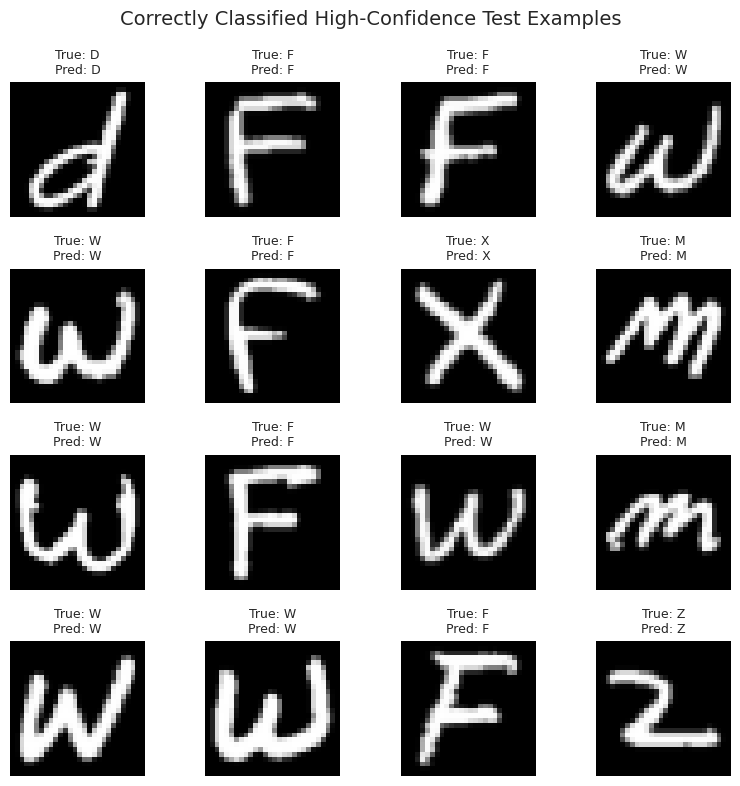

In [109]:
# 11.2 Correctly classified high-confidence examples

plot_image_grid(
    images=X_test_images[high_conf_correct_indices],
    labels=y_test_1d[high_conf_correct_indices],
    predictions=final_test_y_pred[high_conf_correct_indices],
    class_names=class_name_map,
    n=16,
    title="Correctly Classified High-Confidence Test Examples"
)

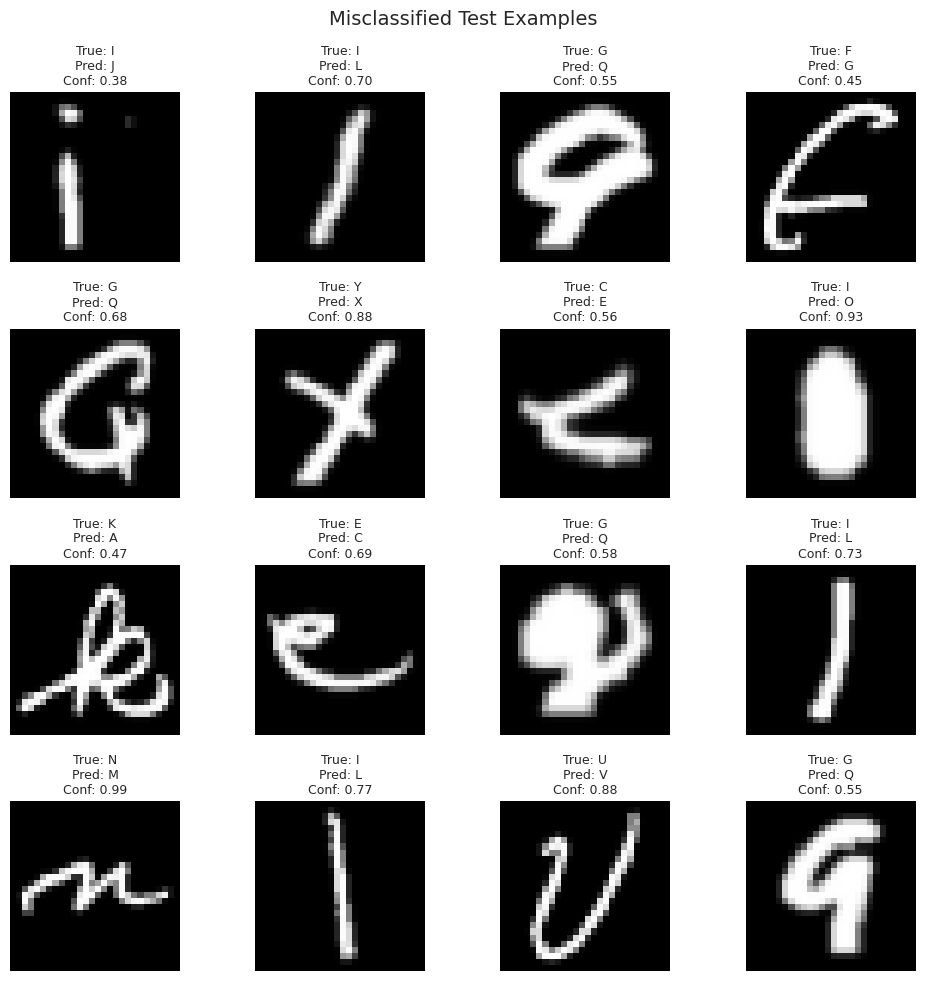

In [110]:
# 11.3 Misclassified examples

show_misclassified_examples(
    model=final_test_model,
    X=X_test_images,
    y_true=y_test,
    class_names=class_name_map,
    n=16,
    title="Misclassified Test Examples"
)

,index,true_label,predicted_label,confidence,correct
0,9124,R,R,0.205270,True
1,946,J,G,0.266499,False
2,10775,P,P,0.277165,True
3,1215,H,K,0.279877,False
4,11607,O,O,0.284028,True
5,3189,I,I,0.287483,True
6,5844,K,E,0.302909,False
7,10590,B,Q,0.306932,False
8,11656,I,I,0.318085,True
9,5305,R,N,0.342617,False


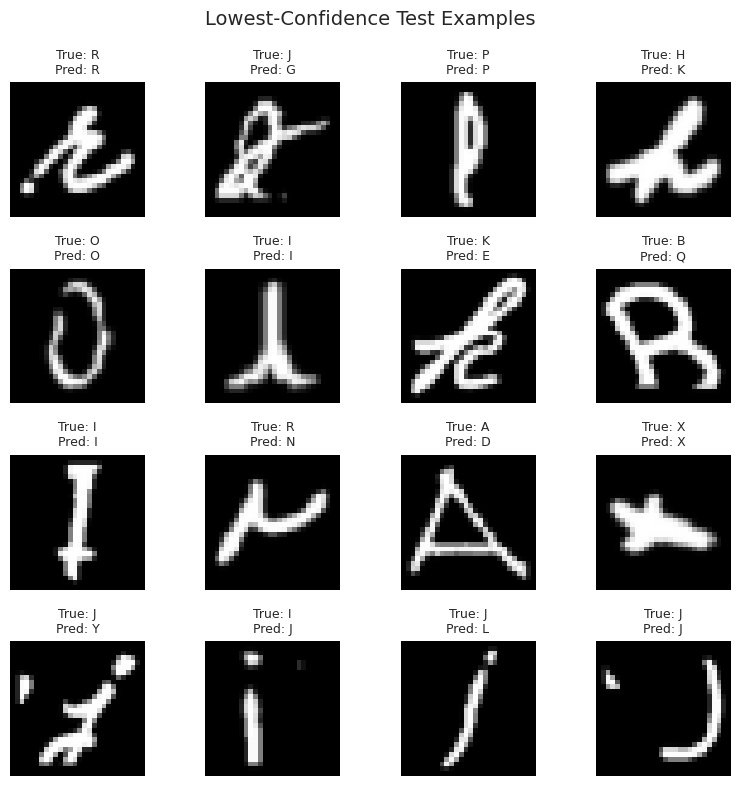

In [111]:
# 11.4 Low-confidence visually ambiguous examples

ambiguous_examples = pd.DataFrame({
    "index": ambiguous_indices,
    "true_label": [class_name_map[int(y_test_1d[i])] for i in ambiguous_indices],
    "predicted_label": [class_name_map[int(final_test_y_pred[i])] for i in ambiguous_indices],
    "confidence": test_confidence[ambiguous_indices],
    "correct": test_correct[ambiguous_indices]
})

display(ambiguous_examples)

plot_image_grid(
    images=X_test_images[ambiguous_indices],
    labels=y_test_1d[ambiguous_indices],
    predictions=final_test_y_pred[ambiguous_indices],
    class_names=class_name_map,
    n=16,
    title="Lowest-Confidence Test Examples"
)

In [112]:
# 11.5 Identify convolutional layers in the final model

conv_layers = [
    layer for layer in final_test_model.layers
    if isinstance(layer, Conv2D)
]

conv_layer_summary = pd.DataFrame([
    {
        "layer_index": final_test_model.layers.index(layer),
        "layer_name": layer.name,
        "output_shape": layer.output.shape,
        "filters": layer.filters,
        "kernel_size": layer.kernel_size,
        "padding": layer.padding,
        "strides": layer.strides
    }
    for layer in conv_layers
])

conv_layer_summary

,layer_index,layer_name,output_shape,filters,kernel_size,padding,strides
0,0,conv2d_2,"(None, 28, 28, 32)",32,"(3, 3)",same,"(1, 1)"
1,2,conv2d_3,"(None, 14, 14, 64)",64,"(3, 3)",same,"(1, 1)"
2,4,conv2d_4,"(None, 7, 7, 128)",128,"(3, 3)",same,"(1, 1)"


In [113]:
# 11.6 Helper for plotting convolutional feature maps

def plot_feature_maps(model, image, conv_layer, max_maps=16):
    activation_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=conv_layer.output
    )

    activations = activation_model.predict(image[np.newaxis, ...], verbose=0)[0]

    num_maps = min(max_maps, activations.shape[-1])
    grid_size = int(np.ceil(np.sqrt(num_maps)))

    plt.figure(figsize=(grid_size * 2, grid_size * 2))

    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(activations[:, :, i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Map {i}", fontsize=8)

    plt.suptitle(
        f"Feature Maps from {conv_layer.name} | Output shape: {activations.shape}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

Selected test index: 7577
True label: D
Predicted label: D
Confidence: 1.0


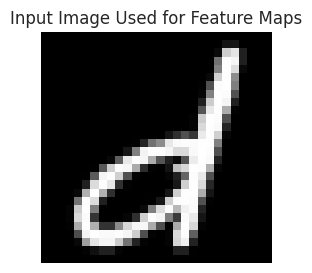

In [114]:
# 11.7 Select a clear correctly classified example for feature-map inspection

feature_map_index = high_conf_correct_indices[0]

print("Selected test index:", feature_map_index)
print("True label:", class_name_map[int(y_test_1d[feature_map_index])])
print("Predicted label:", class_name_map[int(final_test_y_pred[feature_map_index])])
print("Confidence:", round(test_confidence[feature_map_index], 4))

plt.figure(figsize=(3, 3))
plt.imshow(prepare_image_for_plot(X_test_images[feature_map_index]), cmap="gray")
plt.axis("off")
plt.title("Input Image Used for Feature Maps")
plt.show()

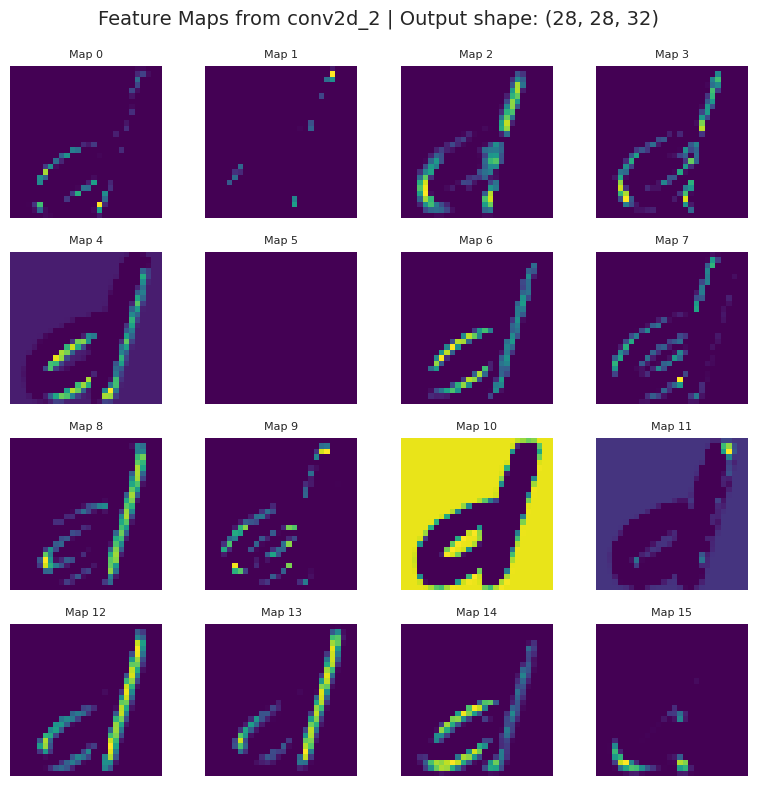

In [115]:
# 11.8 First convolutional layer feature maps

plot_feature_maps(
    model=final_test_model,
    image=X_test_images[feature_map_index],
    conv_layer=conv_layers[0],
    max_maps=16
)

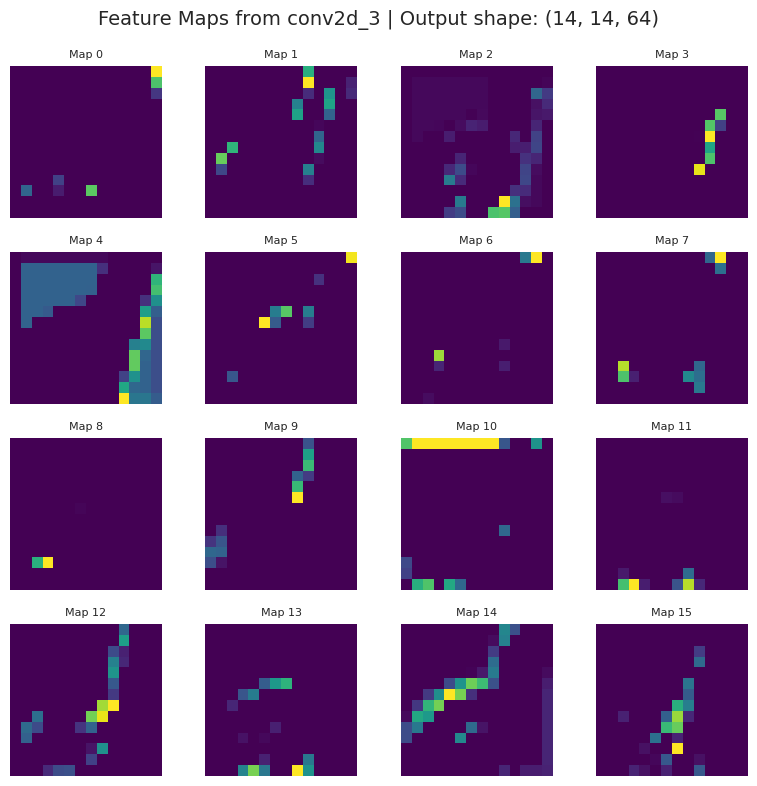

In [116]:
# 11.9 Second convolutional layer feature maps

plot_feature_maps(
    model=final_test_model,
    image=X_test_images[feature_map_index],
    conv_layer=conv_layers[1],
    max_maps=16
)

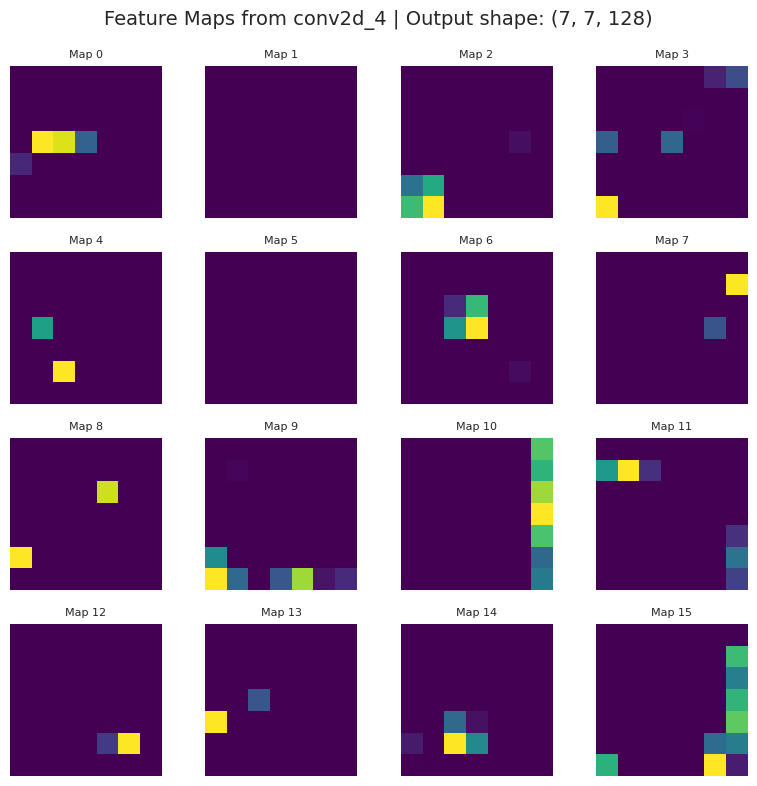

In [118]:
# 11.10 Third convolutional layer feature maps

plot_feature_maps(
    model=final_test_model,
    image=X_test_images[feature_map_index],
    conv_layer=conv_layers[2],
    max_maps=16
)

### 11.11 CNN Interpretability Summary

The final model correctly classified `12,647` test images and misclassified `673` test images. This is consistent with the final test accuracy of about `0.9495`.

The correctly classified high-confidence examples are mostly clean and visually recognisable letters, such as clear `D`, `F`, `W`, `M`, `X`, and `Z` samples. This suggests that the model performs strongly when the handwritten strokes are clear and match common letter shapes.

The misclassified examples are generally more ambiguous. Many of them are difficult even for a human viewer because the handwriting is incomplete, unusually shaped, or visually close to another letter. Examples include `I/J/L`, `G/Q`, `U/V`, `C/E`, and `D/O` style confusions. This matches the main error patterns found in the validation and test confusion-pair analysis.

The lowest-confidence examples also support this. The model is least confident on unclear or unusual samples, and several of these low-confidence predictions are incorrect. This is expected because ambiguous handwriting gives the model weaker visual evidence for a single class.

The final CNN has three convolutional layers:

```text
conv2d_2: output shape = 28×28×32
conv2d_3: output shape = 14×14×64
conv2d_4: output shape = 7×7×128
```

The first convolutional layer keeps the full `28×28` spatial resolution. Its feature maps still visibly resemble the input letter and appear to respond to local strokes and edges. This is expected because early convolutional layers usually capture lower-level visual patterns.

The second convolutional layer operates on smaller `14×14` feature maps. Its activations are more selective and less visually identical to the original input. Some maps respond to parts of the letter stroke, while others are sparse. This suggests that the model is combining earlier local edge/stroke information into more specific intermediate features.

The third convolutional layer operates on `7×7` feature maps with 128 channels. These feature maps are much more compressed and abstract. Many maps contain only small activated regions, meaning the later convolutional layer is no longer preserving a direct image-like view of the letter. Instead, it appears to encode higher-level stroke patterns used for classification.

These feature maps should be interpreted cautiously. They show that the CNN responds to visual stroke regions at different levels of abstraction, but they do not prove that individual filters correspond to specific letters or human-defined concepts.

Overall, the interpretability outputs support the modelling decision to use a CNN. The model learns from local stroke structure, progressively compresses visual information across convolution and pooling layers, and still makes most of its errors on genuinely ambiguous handwritten letters.



---



## 12. Final Discussion

This section summarises the final model performance, explains which modelling decisions helped, discusses remaining errors and limitations, and suggests possible future improvements.

### 12.1 Final Performance Summary

The final locked model achieved strong test performance:

```text
test loss = 0.1450
test accuracy = 0.9495
test macro F1 = 0.9494
test weighted F1 = 0.9494
```

This is a clear improvement over the earlier baselines.

The dense neural network baseline achieved validation accuracy of `0.8808` and validation macro F1 of `0.8808`. The initial CNN baseline improved this to validation accuracy of `0.9110` and validation macro F1 of `0.9108`. The final selected CNN improved further, achieving test accuracy of `0.9495` and test macro F1 of `0.9494`.

This shows that preserving spatial image structure with CNN layers was more effective than using flattened pixels alone. It also shows that the controlled Section 9 improvements meaningfully strengthened the CNN beyond the initial baseline.

### 12.2 What Improved Model Performance

The main improvements came from three selected choices.

First, the Deeper CNN architecture improved performance compared with the shallow, reference, wider, and deeper-no-pool alternatives. The third convolutional block helped the model learn stronger stroke representations before classification.

Second, dropout-only regularisation with `dropout = 0.7` improved validation performance. This was important because the deeper model had enough capacity to overfit. The selected dropout setting gave better validation macro F1 than no regularisation, lower dropout values, L2-only regularisation, and combined dropout + L2.

Third, the learning-rate strategy improved training. Adam with `ReduceLROnPlateau` and patience `3` achieved better validation macro F1 than the fixed learning-rate baselines. This suggests that lowering the learning rate after validation loss plateaued helped the model refine its weights later in training.

The final ablation check confirmed that these choices still helped when combined. Removing the scheduler, reverting to the reference architecture, using reference dropout `0.3`, or removing selected regularisation all reduced validation macro F1.

### 12.3 Selected and Rejected Choices

The final selected model used:

```text
architecture = Deeper CNN
batch_size = 64
max_epochs = 20
dropout = 0.7
L2 = None
BatchNorm = False
augmentation = None
optimizer = Adam
initial learning rate = 0.001
scheduler = ReduceLROnPlateau
scheduler patience = 3
```

Some choices were tested but rejected.

BatchNorm was rejected because it reduced validation macro F1 compared with the no-BatchNorm model. Although it slightly lowered validation loss, macro F1 was the primary selection metric.

Augmentation was also rejected. Conservative augmentation performed reasonably, but still reduced validation macro F1 compared with no augmentation. Strong augmentation performed much worse, suggesting that larger rotations, translations, and zooms distorted or displaced important letter strokes.

L2 regularisation was rejected because L2-only models performed worse than dropout-only models, and combining L2 with the best dropout setting did not improve validation performance.

The selected setting is the best-performing candidate within the predefined controlled search space. It should not be interpreted as a globally optimal model.

### 12.4 Error Analysis

The final model performs well overall, but the remaining errors are concentrated in visually similar handwritten letters.

The main test confusion pairs were:

```text
I → L: 122
L → I: 106
G → Q: 67
Q → G: 24
U → V: 23
V → U: 18
D → O: 13
J → I: 12
Q → A: 10
E → C: 8
```

These errors are visually reasonable. Handwritten `I` and `L` can be almost identical depending on stroke style. `G` and `Q` may differ only by a small tail or stroke. `U` and `V` can be confused when the bottom curve or angle is unclear. `D` and `O` can also be similar when the vertical stroke is weak or rounded.

The misclassified image examples support this interpretation. Many errors are ambiguous even to a human viewer, incomplete, unusually written, or visually close to another class.

The confidence analysis also showed that correct predictions had higher average confidence than incorrect predictions. However, some high-confidence errors remained, meaning confidence should not be treated as guaranteed correctness.

### 12.5 Limitations

There are several limitations.

First, the dataset uses 28×28 grayscale images. This low resolution limits the amount of stroke detail available to the model, especially for letters that differ by small local features.

Second, handwritten letters can be genuinely ambiguous. Some samples are difficult even for humans to classify confidently, especially for pairs such as `I/L`, `G/Q`, `U/V`, and `D/O`.

Third, the Section 9 experiment process was sequential and greedy rather than a full factorial search. Each decision was selected based on the best result so far, so interactions between all possible settings were not fully explored. The final ablation check partly mitigated this by testing whether the main selected components still helped in the combined final model.

Fourth, learning curves were not plotted for every Section 9 candidate model. The main limitation is that the notebook does not visually inspect the full epoch-by-epoch behaviour of every rejected setting, such as temporary validation instability, noisy learning behaviour, or early overfitting followed by recovery. However, this does not mean the training behaviour was ignored. During execution, each model still printed its epoch-by-epoch training history, and the experiment table summarised each run using validation loss, validation accuracy, validation macro F1, validation weighted F1, best epoch, and an overfitting observation computed from the training history during the run. This allowed many controlled experiments to be compared consistently without making Section 9 overly repetitive. Detailed learning curves and class-level diagnostics were reserved for the baseline and final selected model, where deeper interpretation is most useful.

Fifth, no external training data was used. This follows the assignment requirement, but it limits how much variation the model can learn from.

Sixth, augmentation was limited to realistic geometric transformations. More complex augmentation strategies were not explored because the goal was to keep the search space controlled and defensible.

Finally, neural network training can vary slightly because of random initialisation, GPU/backend nondeterminism, and training randomness. The results should therefore be interpreted as the outcome of this controlled run, not as exact values guaranteed across every runtime.

### 12.6 Future Improvements

Future improvements could include a more systematic augmentation search with smaller transformation values. Since the tested conservative policy still reduced performance, future work could investigate even milder augmentation rather than stronger transformations.

Class-specific improvement could also be explored. Since the main weaknesses are concentrated in visually similar classes such as `I/L`, `G/Q`, and `U/V`, future work could analyse these classes separately and inspect whether targeted preprocessing or class-specific augmentation helps.

More advanced CNN architecture refinements could also be tested, such as alternative pooling placement, smaller dense heads, or additional convolutional layers without excessive spatial compression. However, these should be tested only if motivated by error analysis.

Transfer learning is not a priority for this task because the input images are small 28×28 grayscale handwritten letters. A carefully designed custom CNN is more appropriate, easier to justify for this dataset, and already satisfies the requirement to build and improve our own neural network model.

### 12.7 Conclusion

The final model is a strong and defensible CNN classifier for the provided handwritten letter dataset.

The project followed a leakage-safe workflow: data was cleaned, split into train/validation/test sets, models were selected using validation results only, and the test set was used once after the final model was locked.

The final test performance was strong:

```text
test accuracy = 0.9495
test macro F1 = 0.9494
```

The final model improved clearly over both the dense neural network baseline and the initial CNN baseline. The controlled Section 9 experiments showed that the best candidate within the predefined search space used a Deeper CNN, dropout-only regularisation, and ReduceLROnPlateau learning-rate scheduling.

The remaining errors are mainly between visually similar handwritten letters, which is consistent with the EDA, validation analysis, test confusion matrix, and misclassified examples.

Overall, the model generalises well to unseen test data and the final results are technically defensible.



---



## 13. References
Cohen, G., Afshar, S., Tapson, J., & van Schaik, A. (2017). *EMNIST: Extending MNIST to handwritten letters*. 2017 International Joint Conference on Neural Networks (IJCNN), 2921–2926. https://doi.org/10.1109/IJCNN.2017.7966217

Baldominos, A., Saez, Y., & Isasi, P. (2019). A survey of handwritten character recognition with MNIST and EMNIST. *Applied Sciences*, 9(15), 3169. https://doi.org/10.3390/app9153169

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278–2324. https://doi.org/10.1109/5.726791

---

*End of Notebook*